# Part 1: Book Genre Classification

In this notebook, build a complete text classification pipeline for predicting the genre of a book from its description.

The assignment compares two text representations:

1. **TF-IDF**, which represents descriptions using weighted word counts.
2. **Sentence embeddings**, which represent descriptions using dense semantic vectors from the `description_emb` column.

You will train and compare several classifiers:

- **Naive Bayes**
- **k-Nearest Neighbors**
- **Logistic Regression**
- **Multi-Layer Perceptron**

The notebook also studies class imbalance. First, train a baseline model. Then test different imbalance-handling strategies and choose the best one using the development set. Use the selected strategy for the remaining experiments.

The final model is evaluated only once on the test set. Analyze its behavior using model comparison plots, a confusion matrix, per-class scores, and error examples.

## 0. Setup

Run the setup cell before starting the assignment. Scikit-learn is installed only because PCA is used for visualization. Do not use scikit-learn classifiers, vectorizers, scalers, splitters, or metrics in this assignment.

In [1]:
!pip install -q pandas numpy scipy scikit-learn matplotlib tqdm

In [2]:
import ast
import json
import math
import re
import time
import warnings
from collections import Counter, defaultdict
import gdown

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse

from IPython.display import display
from tqdm.auto import tqdm


from sklearn.decomposition import PCA

tqdm.pandas()
warnings.filterwarnings("ignore")

# Dataset
This is the dataset you worked with in Phase 1.
Each row in the dataset represents one book. The main fields used in this assignment are:

- `description`: the text used for classification.
- `genres`: the source of the target label.
- `description_emb`: a precomputed embedding of the description.

The `description_emb` column was added before this notebook using `BAAI/bge-large-en-v1.5`. This model creates 1024-dimensional dense vectors designed to capture semantic similarity between texts.


### Run this cell if you are using colab to download the dataset automatically

In [3]:
url = "https://drive.google.com/file/d/1KGPZ7lKkxkPR4azBRLxEoG7ngo8EXrDC/view?usp=drive_link"
output = "books.csv"

gdown.download(url, output, quiet=False, fuzzy=True)

Downloading...
From: https://drive.google.com/uc?id=1KGPZ7lKkxkPR4azBRLxEoG7ngo8EXrDC
To: /content/books.csv
100%|██████████| 72.8M/72.8M [00:00<00:00, 187MB/s]


'books.csv'

## 1. Configuration

Set the input and output paths. The input CSV must already contain a `description_emb` column.

In [4]:
# =========================
# File paths
# =========================
CSV_PATH = "books.csv"
OUTPUT_DEV_RESULTS_CSV = "classification_dev_results.csv"
OUTPUT_TEST_RESULTS_CSV = "classification_test_results.csv"
OUTPUT_TEST_PREDICTIONS_CSV = "classification_test_predictions.csv"

# =========================
# Column names
# =========================
DESCRIPTION_COLUMN = "description"
EMBEDDING_COLUMN = "description_emb"
GENRES_COLUMN = "genres"
TITLE_COLUMN = "title"

# =========================
# Dataset settings
# =========================
RANDOM_STATE = 42
TOP_N_CLASSES = 10
MIN_SAMPLES_PER_CLASS = 100

# Keep the test set untouched until final evaluation.
TRAIN_SIZE = 0.70
DEV_SIZE = 0.15
TEST_SIZE = 0.15

# =========================
# TF-IDF settings
# =========================
MAX_TFIDF_FEATURES = 20000
NGRAM_RANGE = (1, 2)
MIN_DF = 3
MAX_DF = 0.95

# =========================
# Scratch model settings
# =========================
KNN_NEIGHBORS = 5

LR_MAX_EPOCHS = 60
LR_IMBALANCE_EPOCHS = 25
LR_LEARNING_RATE = 0.5
LR_BATCH_SIZE = 512
LR_ALPHA = 1e-4

# MLPs need dense input. For TF-IDF, select a compact subset of TF-IDF features first.
DENSE_TFIDF_FEATURES_FOR_MLP = 2000
MLP_HIDDEN_DIM = 128
MLP_MAX_EPOCHS = 35
MLP_LEARNING_RATE = 1e-3
MLP_BATCH_SIZE = 128
MLP_ALPHA = 1e-4

# =========================
# Imbalance handling settings
# =========================
IMBALANCE_STRATEGIES = [
    "none",               # baseline: keep the original training distribution
    "random_oversample",  # duplicate minority-class rows until all classes match the largest class
    "random_undersample", # sample majority-class rows down to the smallest class
    "median_resample",    # move every class toward the median class size
]

# =========================
# Visualization settings
# =========================
MAX_POINTS_FOR_PCA_PLOT = 3000
FIG_DPI = 140

## 2. Visualization utilities

Use the following plotting helpers throughout the notebook. Do not change them unless you want to improve the visual design consistently across all plots.

In [5]:
def set_research_plot_style():
    # Use a clean, publication-friendly style while keeping Matplotlib defaults for colors.
    plt.rcParams.update({
        "figure.dpi": FIG_DPI,
        "savefig.dpi": FIG_DPI,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linewidth": 0.8,
        "axes.titleweight": "bold",
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.frameon": False,
    })


set_research_plot_style()


def add_value_labels_to_bars(ax, fmt="{:.3f}", padding=3, fontsize=8):
    for container in ax.containers:
        labels = []
        for bar in container:
            value = bar.get_height()
            if np.isnan(value):
                labels.append("")
            elif abs(value) >= 100:
                labels.append(f"{value:,.0f}")
            else:
                labels.append(fmt.format(value))
        ax.bar_label(container, labels=labels, padding=padding, fontsize=fontsize)


def plot_horizontal_count_distribution(counts, title, xlabel="Number of examples", show_percent=True):
    counts = pd.Series(counts).sort_values(ascending=True)
    total = counts.sum()

    fig_height = max(4.5, 0.42 * len(counts) + 1.5)
    fig, ax = plt.subplots(figsize=(11, fig_height))
    bars = ax.barh(counts.index.astype(str), counts.values)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Class")
    ax.grid(axis="x")
    ax.grid(axis="y", visible=False)

    x_max = counts.max() if len(counts) else 1
    ax.set_xlim(0, x_max * 1.18)

    for bar, value in zip(bars, counts.values):
        if show_percent and total > 0:
            label = f"{value:,}  ({value / total:.1%})"
        else:
            label = f"{value:,}"
        ax.text(
            bar.get_width() + x_max * 0.015,
            bar.get_y() + bar.get_height() / 2,
            label,
            va="center",
            fontsize=8,
        )

    plt.tight_layout()
    plt.show()


def plot_grouped_metric_bars(df_plot, category_col, metric_cols, title, ylabel, sort_by=None, rotation=45):
    plot_df = df_plot.copy()
    if sort_by is not None:
        plot_df = plot_df.sort_values(sort_by, ascending=False).reset_index(drop=True)

    labels = plot_df[category_col].astype(str).tolist()
    x = np.arange(len(labels))
    width = 0.78 / max(1, len(metric_cols))

    fig_width = max(11, 0.65 * len(labels) + 4)
    fig, ax = plt.subplots(figsize=(fig_width, 5.8))

    for i, metric in enumerate(metric_cols):
        offset = (i - (len(metric_cols) - 1) / 2) * width
        ax.bar(x + offset, plot_df[metric].astype(float).values, width, label=metric)

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=rotation, ha="right")
    ax.set_ylim(0, min(1.05, max(0.05, plot_df[metric_cols].to_numpy().max() * 1.15)))
    ax.legend(loc="best")
    ax.grid(axis="y")
    ax.grid(axis="x", visible=False)

    add_value_labels_to_bars(ax, fmt="{:.3f}", padding=2, fontsize=7)
    plt.tight_layout()
    plt.show()


def plot_metric_heatmap(matrix_df, title, xlabel, ylabel, value_format=".3f"):
    matrix_df = matrix_df.copy()
    fig_width = max(7.5, 0.75 * matrix_df.shape[1] + 4)
    fig_height = max(4.5, 0.45 * matrix_df.shape[0] + 2)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    values = matrix_df.to_numpy(dtype=float)
    im = ax.imshow(values, aspect="auto")

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticks(np.arange(matrix_df.shape[1]))
    ax.set_yticks(np.arange(matrix_df.shape[0]))
    ax.set_xticklabels(matrix_df.columns.astype(str), rotation=45, ha="right")
    ax.set_yticklabels(matrix_df.index.astype(str))

    for i in range(matrix_df.shape[0]):
        for j in range(matrix_df.shape[1]):
            value = values[i, j]
            if np.isfinite(value):
                ax.text(j, i, format(value, value_format), ha="center", va="center", fontsize=8)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.grid(False)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix_professional(y_true, y_pred, class_names, title):
    cm_counts = scratch_confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
    cm_norm = scratch_confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)), normalize="true")
    cm_norm = np.nan_to_num(cm_norm)

    fig_width = max(8, 0.75 * len(class_names) + 4)
    fig_height = max(7, 0.65 * len(class_names) + 3)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    im = ax.imshow(cm_norm, aspect="auto")

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            count = int(cm_counts[i, j])
            pct = cm_norm[i, j]
            if count > 0:
                label = f"{count}\n{pct:.0%}"
            else:
                label = ""
            ax.text(j, i, label, ha="center", va="center", fontsize=7)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Row-normalized proportion")
    ax.grid(False)
    plt.tight_layout()
    plt.show()


def plot_per_class_f1(report_df, title):
    plot_df = report_df.copy().sort_values("f1-score", ascending=True)

    fig_height = max(4.8, 0.45 * len(plot_df) + 1.5)
    fig, ax = plt.subplots(figsize=(11, fig_height))
    bars = ax.barh(plot_df.index.astype(str), plot_df["f1-score"].astype(float).values)

    ax.set_title(title)
    ax.set_xlabel("F1-score")
    ax.set_ylabel("Class")
    ax.set_xlim(0, 1.05)
    ax.grid(axis="x")
    ax.grid(axis="y", visible=False)

    for bar, (_, row) in zip(bars, plot_df.iterrows()):
        label = f"F1={row['f1-score']:.3f}, n={int(row['support'])}"
        ax.text(
            min(bar.get_width() + 0.015, 1.01),
            bar.get_y() + bar.get_height() / 2,
            label,
            va="center",
            fontsize=8,
        )

    plt.tight_layout()
    plt.show()


def plot_pca_projection(X, y, class_names, title, max_points=3000, random_state=42):
    rng = np.random.default_rng(random_state)
    n = X.shape[0]
    sample_idx = np.arange(n)

    if n > max_points:
        sample_idx = rng.choice(sample_idx, size=max_points, replace=False)

    X_sample = X[sample_idx]
    y_sample = y[sample_idx]

    pca = PCA(n_components=2, random_state=random_state)
    coords = pca.fit_transform(X_sample)

    fig, ax = plt.subplots(figsize=(10, 7))

    for class_id, class_name in enumerate(class_names):
        mask = y_sample == class_id
        if np.any(mask):
            ax.scatter(
                coords[mask, 0],
                coords[mask, 1],
                s=16,
                alpha=0.65,
                label=class_name,
                linewidths=0,
            )

    explained = pca.explained_variance_ratio_ * 100
    ax.set_title(title)
    ax.set_xlabel(f"PC1 ({explained[0]:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({explained[1]:.1f}% variance)")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), title="Genre")
    ax.grid(True)
    plt.tight_layout()
    plt.show()


def plot_confusion_pairs(errors_df, true_col="true_label", pred_col="predicted_label", top_n=12):
    if len(errors_df) == 0:
        print("No errors to visualize.")
        return

    pairs = (
        errors_df
        .groupby([true_col, pred_col])
        .size()
        .sort_values(ascending=False)
        .head(top_n)
    )

    labels = [f"{true} → {pred}" for true, pred in pairs.index]
    values = pairs.values

    fig_height = max(4.5, 0.4 * len(labels) + 1.5)
    fig, ax = plt.subplots(figsize=(11, fig_height))
    bars = ax.barh(labels[::-1], values[::-1])

    ax.set_title(f"Top {len(labels)} Confusion Pairs")
    ax.set_xlabel("Number of test examples")
    ax.set_ylabel("True → predicted")
    ax.grid(axis="x")
    ax.grid(axis="y", visible=False)

    x_max = values.max() if len(values) else 1
    ax.set_xlim(0, x_max * 1.18)
    for bar, value in zip(bars, values[::-1]):
        ax.text(
            bar.get_width() + x_max * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f"{value:,}",
            va="center",
            fontsize=8,
        )

    plt.tight_layout()
    plt.show()

## 3. Load the dataset


In [6]:
try:
    df = pd.read_csv(CSV_PATH)
except pd.errors.ParserError:
    # Use the slower Python parser if the CSV contains difficult quoted fields.
    df = pd.read_csv(CSV_PATH, engine="python")

print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

required_columns = [
    DESCRIPTION_COLUMN,
    EMBEDDING_COLUMN,
    GENRES_COLUMN,
]

missing = [c for c in required_columns if c not in df.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

display(df.head())

Dataset shape: (3000, 25)
Columns:
['Unnamed: 0', 'bookId', 'title', 'author', 'series', 'description', 'genres', 'awards', 'characters', 'places', 'isbn', 'isbn13', 'language', 'first_publish_date', 'publish_date', 'num_pages', 'num_ratings', 'num_reviews', 'avg_rating', 'rated_1', 'rated_2', 'rated_3', 'rated_4', 'rated_5', 'description_emb']


,Unnamed: 0,bookId,title,author,series,description,genres,awards,characters,places,...,num_pages,num_ratings,num_reviews,avg_rating,rated_1,rated_2,rated_3,rated_4,rated_5,description_emb
0,4249,4255,Harry Potter and the Philosopher's Stone,J.K. Rowling,Harry Potter #1,When a letter arrives for unhappy but ordinary...,"Art,Biography,Business,Children's,Christian,Cl...",Mythopoeic Fantasy Award for Children's Litera...,"Draco Malfoy,Ron Weasley,Petunia Dursley,Verno...","London, England,Hogwarts School of Witchcraft ...",...,223.0,7437005,117859,4.48,126396,147247,627970,1694668,4840724,"[-0.0039046169258654118, -0.023151082918047905..."
1,2,3,Harry Potter and the Sorcerer's Stone,"J.K. Rowling,Mary GrandPré",Harry Potter #1,Harry Potter's life is miserable. His parents ...,"Art,Biography,Business,Children's,Christian,Cl...",Mythopoeic Fantasy Award for Children's Litera...,"Draco Malfoy,Ron Weasley,Petunia Dursley,Verno...","London, England,Hogwarts School of Witchcraft ...",...,309.0,7434783,117823,4.48,126344,147184,627803,1694206,4839246,"[0.006142752710729837, -0.03195742145180702, -..."
2,12110,12024,Twilight,Stephenie Meyer,The Twilight Saga #1,"About three things I was absolutely positive.,...","Art,Biography,Business,Children's,Christian,Cl...","Georgia Peach Book Award 2007,Buxtehuder Bulle...","Edward Cullen,Jacob Black,Laurent,Renee,Bella ...","Forks, Washington,Phoenix, Arizona,Washington ...",...,544.0,5173079,106718,3.61,562807,560978,1052619,1164865,1831810,"[0.055690325796604156, -0.03585127741098404, -..."
3,2656,2661,To Kill a Mockingbird,Harper Lee,To Kill a Mockingbird,Lawyer Atticus Finch defends the real mockingb...,"Art,Biography,Business,Children's,Christian,Cl...","Pulitzer Prize for Fiction 1961,Audie Award fo...","Scout Finch,Atticus Finch,Jem Finch,Arthur Rad...","Maycomb, Alabama,Alabama",...,323.0,4712812,94358,4.28,85019,156544,598802,1395089,2477358,"[0.056648898869752884, -0.02620820701122284, 0..."
4,2655,2660,To Kill a Mockingbird,Harper Lee,To Kill a Mockingbird,Harper Lee's classic novel of a lawyer in the ...,"Art,Biography,Business,Children's,Christian,Cl...","Pulitzer Prize for Fiction 1961,Audie Award fo...","Scout Finch,Atticus Finch,Jem Finch,Arthur Rad...","Maycomb, Alabama,Alabama",...,284.0,4712812,94358,4.28,85019,156544,598802,1395089,2477358,"[0.020673654973506927, -0.026255520060658455, ..."


## 4. Create one target genre

Map each book to one high-level genre. If a book has several genres, choose one target label using the priority list and repeated genre counts.

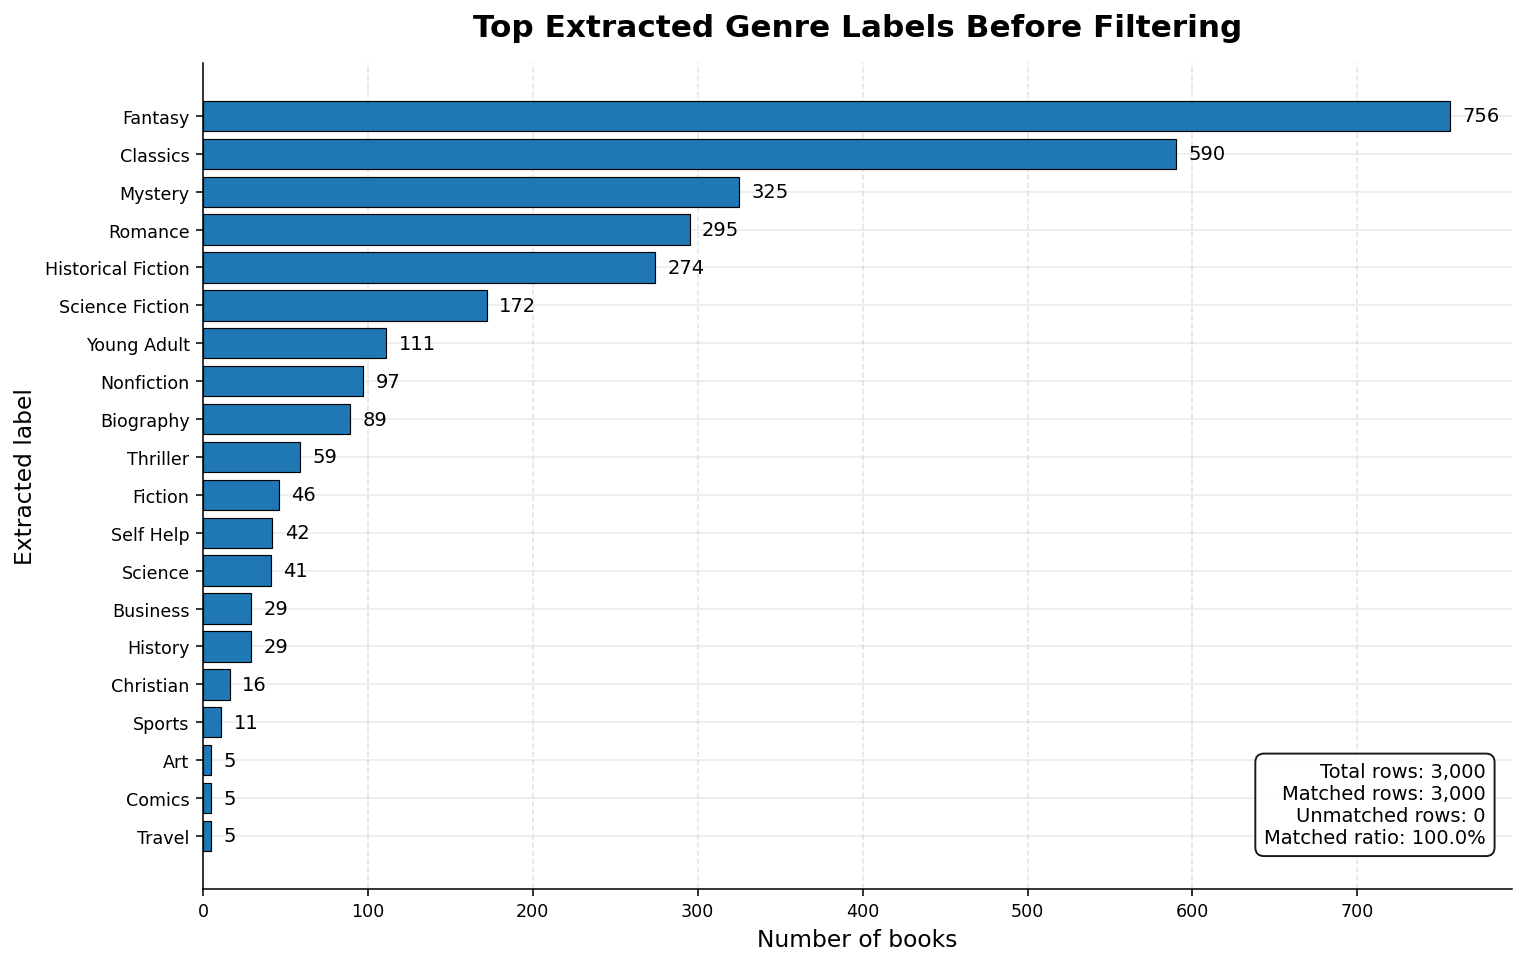

In [7]:
TARGET_GENRES = [
    "Fantasy",
    "Romance",
    "Mystery",
    "Thriller",
    "Science Fiction",
    "Historical Fiction",
    "Young Adult",
    "Classics",
    "Fiction",
    "Nonfiction",
    "History",
    "Biography",
    "Memoir",
    "Horror",
    "Children's",
    "Science",
    "Business",
    "Psychology",
    "Self Help",
    "Poetry",
    "Graphic Novels",
    "Comics",
    "Travel",
    "Sports",
    "Christian",
    "Cookbooks",
    "Music",
    "Art",
]

TARGET_GENRE_SET = set(TARGET_GENRES)
GENRE_PRIORITY = {
    genre: idx
    for idx, genre in enumerate(TARGET_GENRES)
}


def split_genres(genres_value):
    # Split one raw genre cell into cleaned genre tokens.
    if genres_value is None:
        return []

    text = str(genres_value).strip()
    if not text:
        return []

    return [g.strip().strip('"').strip("'") for g in text.split(",") if g.strip()]


def choose_main_genre(genres_value):
    # Convert a multi-genre row into one supervised label.
    genres = split_genres(genres_value)

    candidates = [
        g for g in genres
        if g in TARGET_GENRE_SET
    ]

    if not candidates:
        return None

    counts = Counter(candidates)
    return sorted(counts.keys(), key=lambda g: (-counts[g], GENRE_PRIORITY[g]))[0]


df["label"] = df[GENRES_COLUMN].apply(choose_main_genre)


# =========================
# Visualize extracted labels
# =========================

label_counts = (
    df["label"]
    .fillna("No selected target genre")
    .value_counts()
    .head(20)
    .sort_values()
)

total_rows = len(df)
matched_rows = int(df["label"].notna().sum())
unmatched_rows = int(df["label"].isna().sum())

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    label_counts.index,
    label_counts.values,
    edgecolor="black",
    linewidth=0.6,
)

ax.set_title(
    "Top Extracted Genre Labels Before Filtering",
    fontsize=16,
    fontweight="bold",
    pad=14,
)

ax.set_xlabel("Number of books", fontsize=12)
ax.set_ylabel("Extracted label", fontsize=12)

ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

max_count = label_counts.max()

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + max_count * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,}",
        va="center",
        fontsize=10,
    )

summary_text = (
    f"Total rows: {total_rows:,}\n"
    f"Matched rows: {matched_rows:,}\n"
    f"Unmatched rows: {unmatched_rows:,}\n"
    f"Matched ratio: {matched_rows / total_rows:.1%}"
)

ax.text(
    0.98,
    0.05,
    summary_text,
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor="white",
        edgecolor="black",
        alpha=0.9,
    ),
)

plt.tight_layout()
plt.show()

## 5. Clean rows and keep common classes

Keep rows with a usable description, a usable embedding, and one of the selected labels.

In [8]:
df[DESCRIPTION_COLUMN] = (
    df[DESCRIPTION_COLUMN]
    .fillna("")
    .astype(str)
    .str.strip()
)

df[EMBEDDING_COLUMN] = (
    df[EMBEDDING_COLUMN]
    .fillna("")
    .astype(str)
    .str.strip()
)

df_model = df[
    (df["label"].notna()) &
    (df[DESCRIPTION_COLUMN] != "") &
    (df[EMBEDDING_COLUMN] != "")
].copy()

genre_counts = df_model["label"].value_counts()
eligible_genres = genre_counts[
    genre_counts >= MIN_SAMPLES_PER_CLASS
]

# If the dataset is small, keep the notebook runnable instead of failing immediately.
if len(eligible_genres) < 2:
    print("MIN_SAMPLES_PER_CLASS is too strict. Falling back to classes with at least 5 examples.")
    eligible_genres = genre_counts[genre_counts >= 5].head(TOP_N_CLASSES)

selected_genres = eligible_genres.head(TOP_N_CLASSES).index.tolist()

df_model = df_model[df_model["label"].isin(selected_genres)].copy()
df_model = df_model.reset_index(drop=True)

if df_model["label"].nunique() < 2:
    raise ValueError("Need at least two classes after filtering. Lower MIN_SAMPLES_PER_CLASS or TOP_N_CLASSES.")

print("Selected genres:")
print(selected_genres)
print()
print("Final dataset shape:", df_model.shape)

class_counts = df_model["label"].value_counts().sort_values(ascending=False)
class_summary = pd.DataFrame({
    "count": class_counts,
    "proportion": class_counts / class_counts.sum(),
})

display(class_summary)

Selected genres:
['Fantasy', 'Classics', 'Mystery', 'Romance', 'Historical Fiction', 'Science Fiction', 'Young Adult']

Final dataset shape: (2465, 26)


,count,proportion
label,,
Fantasy,737,0.298986
Classics,570,0.231237
Mystery,321,0.130223
Romance,290,0.117647
Historical Fiction,271,0.109939
Science Fiction,168,0.068154
Young Adult,108,0.043813


### Class distribution after filtering


classes who are rare may need special attention during evaluation.

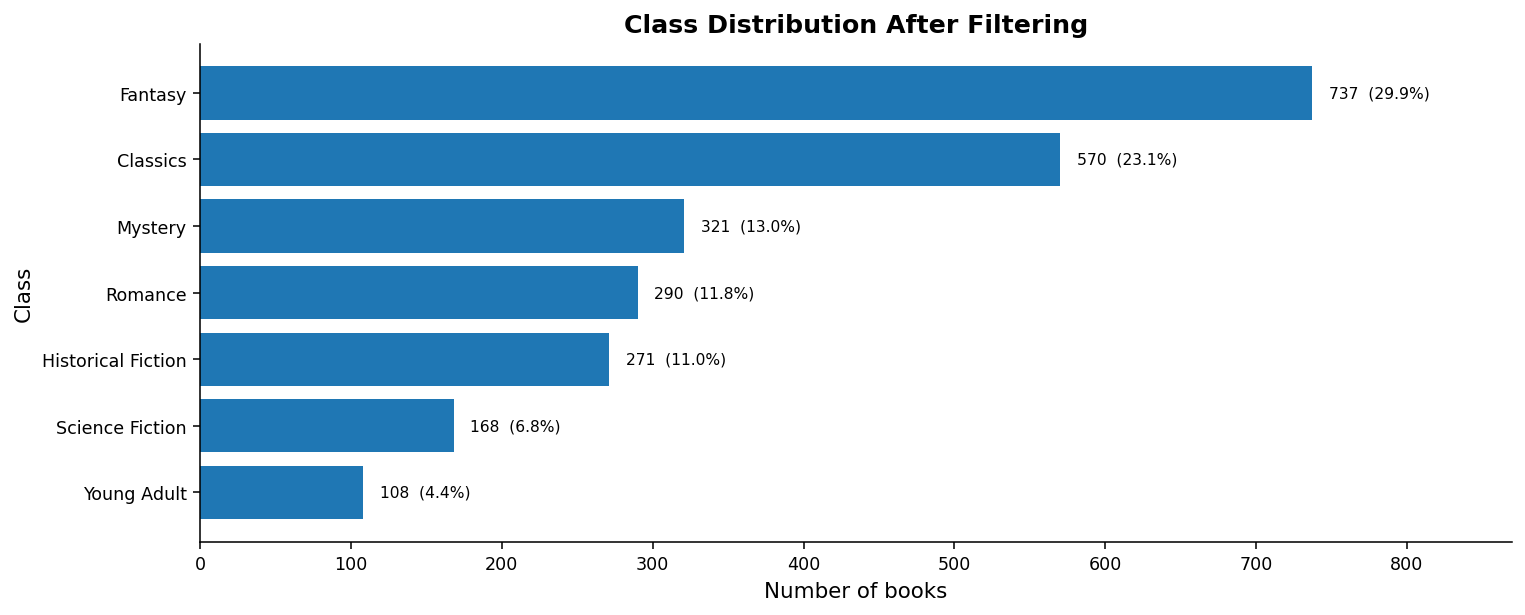

In [9]:
plot_horizontal_count_distribution(
    df_model["label"].value_counts(),
    title="Class Distribution After Filtering",
    xlabel="Number of books",
)

In [10]:
def parse_embedding(value):
    # Each cell should contain a JSON-style list of floats, e.g. "[0.1, -0.2, ...]".
    text = str(value).strip()

    if not text:
        return None

    try:
        parsed = json.loads(text)
    except json.JSONDecodeError:
        parsed = ast.literal_eval(text)

    arr = np.asarray(parsed, dtype=np.float32)

    if arr.ndim != 1 or arr.size == 0:
        return None

    return arr


parsed_embeddings = df_model[EMBEDDING_COLUMN].apply(parse_embedding)
valid_embedding_mask = parsed_embeddings.notna()

if not valid_embedding_mask.all():
    print("Dropping rows with invalid embeddings:", int((~valid_embedding_mask).sum()))
    df_model = df_model.loc[valid_embedding_mask].reset_index(drop=True)
    parsed_embeddings = parsed_embeddings.loc[valid_embedding_mask].reset_index(drop=True)

embedding_matrix = np.vstack(parsed_embeddings.values)

print("Embedding matrix shape:", embedding_matrix.shape)

Embedding matrix shape: (2465, 1024)



## 6. Scratch implementations

Read these classes before running the experiments. These are the implementations that must be used throughout the notebook.

The goal is not to beat mature libraries. The goal is to make each method transparent enough to inspect, modify, and debug.


In [11]:

# ============================================================
# Utility helpers
# ============================================================

def as_1d_int_array(values):
    return np.asarray(values, dtype=int).ravel()


def stable_softmax(logits):
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)


def one_hot(y, n_classes):
    y = as_1d_int_array(y)
    Y = np.zeros((len(y), n_classes), dtype=np.float32)
    Y[np.arange(len(y)), y] = 1.0
    return Y


def safe_sparse_to_dense(X):
    if sparse.issparse(X):
        return X.toarray()
    return np.asarray(X)


def l2_normalize_rows(X, eps=1e-12):
    if sparse.issparse(X):
        row_norms = np.sqrt(np.asarray(X.multiply(X).sum(axis=1)).ravel())
        row_norms[row_norms < eps] = 1.0
        return X.multiply(1.0 / row_norms[:, None]).tocsr()

    X = np.asarray(X, dtype=np.float32)
    row_norms = np.linalg.norm(X, axis=1, keepdims=True)
    row_norms[row_norms < eps] = 1.0
    return X / row_norms


# ============================================================
# Label encoding and stratified splitting
# ============================================================

class ScratchLabelEncoder:
    def fit(self, labels):
        self.classes_ = np.array(sorted(pd.Series(labels).astype(str).unique()))
        self.class_to_id_ = {label: i for i, label in enumerate(self.classes_)}
        return self

    def transform(self, labels):
        return np.array([self.class_to_id_[str(label)] for label in labels], dtype=int)

    def fit_transform(self, labels):
        return self.fit(labels).transform(labels)

    def inverse_transform(self, ids):
        ids = as_1d_int_array(ids)
        return self.classes_[ids]


def stratified_train_dev_test_split(y, train_size=0.70, dev_size=0.15, test_size=0.15, random_state=42):
    # Preserve the class distribution in train/dev/test.
    y = as_1d_int_array(y)
    rng = np.random.default_rng(random_state)

    if not np.isclose(train_size + dev_size + test_size, 1.0):
        raise ValueError("train_size + dev_size + test_size must equal 1.")

    train_idx, dev_idx, test_idx = [], [], []

    for class_id in np.unique(y):
        class_indices = np.where(y == class_id)[0]
        rng.shuffle(class_indices)
        n = len(class_indices)

        n_train = int(np.floor(n * train_size))
        n_dev = int(np.floor(n * dev_size))
        n_test = n - n_train - n_dev

        if n >= 3:
            if n_dev == 0:
                n_dev = 1
                n_train = max(1, n_train - 1)
            if n_test == 0:
                n_test = 1
                n_train = max(1, n_train - 1)

        train_idx.extend(class_indices[:n_train])
        dev_idx.extend(class_indices[n_train:n_train + n_dev])
        test_idx.extend(class_indices[n_train + n_dev:])

    train_idx = np.array(train_idx, dtype=int)
    dev_idx = np.array(dev_idx, dtype=int)
    test_idx = np.array(test_idx, dtype=int)

    rng.shuffle(train_idx)
    rng.shuffle(dev_idx)
    rng.shuffle(test_idx)

    return train_idx, dev_idx, test_idx


# ============================================================
# TF-IDF from scratch
# ============================================================

class ScratchTfidfVectorizer:
    def __init__(
        self,
        lowercase=True,
        ngram_range=(1, 1),
        min_df=1,
        max_df=1.0,
        max_features=None,
        sublinear_tf=True,
        norm="l2",
    ):
        self.lowercase = lowercase
        self.ngram_range = ngram_range
        self.min_df = min_df
        self.max_df = max_df
        self.max_features = max_features
        self.sublinear_tf = sublinear_tf
        self.norm = norm
        self.token_pattern = re.compile(r"(?u)\b\w\w+\b")

    def _tokens(self, text):
        text = "" if text is None else str(text)
        if self.lowercase:
            text = text.lower()
        return self.token_pattern.findall(text)

    def _analyze(self, text):
        tokens = self._tokens(text)
        min_n, max_n = self.ngram_range

        terms = []
        for n in range(min_n, max_n + 1):
            if len(tokens) >= n:
                terms.extend([" ".join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)])
        return terms

    def fit(self, documents):
        documents = list(documents)
        n_docs = len(documents)

        df_counter = Counter()
        tf_counter = Counter()

        for doc in tqdm(documents, desc="Fitting scratch TF-IDF"):
            terms = self._analyze(doc)
            tf_counter.update(terms)
            df_counter.update(set(terms))

        min_df_abs = self.min_df if isinstance(self.min_df, int) else int(math.ceil(self.min_df * n_docs))
        max_df_abs = self.max_df if isinstance(self.max_df, int) else int(math.floor(self.max_df * n_docs))

        candidate_terms = [
            term for term, df in df_counter.items()
            if df >= min_df_abs and df <= max_df_abs
        ]

        candidate_terms = sorted(candidate_terms, key=lambda term: (-tf_counter[term], term))
        if self.max_features is not None:
            candidate_terms = candidate_terms[:self.max_features]

        self.vocabulary_ = {term: i for i, term in enumerate(candidate_terms)}
        self.feature_names_ = np.array(candidate_terms, dtype=object)

        dfs = np.array([df_counter[term] for term in candidate_terms], dtype=np.float64)
        self.idf_ = np.log((1.0 + n_docs) / (1.0 + dfs)) + 1.0
        return self

    def transform(self, documents):
        if not hasattr(self, "vocabulary_"):
            raise ValueError("Vectorizer must be fitted before transform.")

        documents = list(documents)
        rows, cols, data = [], [], []

        for row_id, doc in enumerate(tqdm(documents, desc="Transforming with scratch TF-IDF")):
            counts = Counter(term for term in self._analyze(doc) if term in self.vocabulary_)

            for term, count in counts.items():
                col_id = self.vocabulary_[term]
                tf = 1.0 + math.log(count) if self.sublinear_tf else float(count)
                rows.append(row_id)
                cols.append(col_id)
                data.append(tf * self.idf_[col_id])

        X = sparse.csr_matrix(
            (data, (rows, cols)),
            shape=(len(documents), len(self.vocabulary_)),
            dtype=np.float32,
        )

        if self.norm == "l2":
            X = l2_normalize_rows(X)

        return X

    def fit_transform(self, documents):
        return self.fit(documents).transform(documents)

    def get_feature_names_out(self):
        return self.feature_names_


def select_top_sparse_columns_by_variance(X, max_features):
    # Convert only a selected subset of sparse TF-IDF features to dense form for the MLP.
    if not sparse.issparse(X):
        X = sparse.csr_matrix(X)

    n_features = X.shape[1]
    keep = min(max_features, n_features)

    mean = np.asarray(X.mean(axis=0)).ravel()
    mean_sq = np.asarray(X.power(2).mean(axis=0)).ravel()
    variance = mean_sq - mean ** 2

    selected = np.argsort(variance)[-keep:]
    selected = np.sort(selected)

    return selected


# ============================================================
# Scaling from scratch
# ============================================================

class ScratchStandardScaler:
    def __init__(self, eps=1e-8):
        self.eps = eps

    def fit(self, X):
        X = np.asarray(X, dtype=np.float32)
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0)
        self.std_[self.std_ < self.eps] = 1.0
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=np.float32)
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        return self.fit(X).transform(X)


class ScratchScaledClassifier:
    def __init__(self, estimator):
        self.estimator = estimator
        self.scaler = ScratchStandardScaler()

    def fit(self, X, y):
        X_scaled = self.scaler.fit_transform(safe_sparse_to_dense(X))
        self.estimator.fit(X_scaled, y)
        return self

    def predict(self, X):
        X_scaled = self.scaler.transform(safe_sparse_to_dense(X))
        return self.estimator.predict(X_scaled)


# ============================================================
# Metrics from scratch
# ============================================================

def scratch_confusion_matrix(y_true, y_pred, labels=None, normalize=None):
    y_true = as_1d_int_array(y_true)
    y_pred = as_1d_int_array(y_pred)

    if labels is None:
        labels = np.unique(np.concatenate([y_true, y_pred]))
    labels = as_1d_int_array(labels)

    label_to_position = {label: i for i, label in enumerate(labels)}
    cm = np.zeros((len(labels), len(labels)), dtype=np.float64)

    for true_label, pred_label in zip(y_true, y_pred):
        if true_label in label_to_position and pred_label in label_to_position:
            cm[label_to_position[true_label], label_to_position[pred_label]] += 1

    if normalize == "true":
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        cm = cm / row_sums

    return cm


def per_class_metrics(y_true, y_pred, labels):
    cm = scratch_confusion_matrix(y_true, y_pred, labels=labels)
    rows = []

    for i, label in enumerate(labels):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        support = cm[i, :].sum()

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

        rows.append({
            "label": label,
            "precision": precision,
            "recall": recall,
            "f1-score": f1,
            "support": support,
        })

    return pd.DataFrame(rows)


def compute_metrics(y_true, y_pred):
    y_true = as_1d_int_array(y_true)
    y_pred = as_1d_int_array(y_pred)
    labels = np.unique(np.concatenate([y_true, y_pred]))

    class_df = per_class_metrics(y_true, y_pred, labels)
    accuracy = float(np.mean(y_true == y_pred))

    cm = scratch_confusion_matrix(y_true, y_pred, labels=labels)
    total_tp = float(np.trace(cm))
    total_fp = float(cm.sum(axis=0).sum() - total_tp)
    total_fn = float(cm.sum(axis=1).sum() - total_tp)

    micro_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    micro_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
    micro_f1 = (
        2 * micro_precision * micro_recall / (micro_precision + micro_recall)
        if (micro_precision + micro_recall) > 0
        else 0.0
    )

    return {
        "accuracy": accuracy,
        "macro_precision": float(class_df["precision"].mean()),
        "macro_recall": float(class_df["recall"].mean()),
        "macro_f1": float(class_df["f1-score"].mean()),
        "micro_precision": float(micro_precision),
        "micro_recall": float(micro_recall),
        "micro_f1": float(micro_f1),
    }


def classification_report_scratch(y_true, y_pred, target_names, digits=3, output_dict=False):
    labels = np.arange(len(target_names))
    class_df = per_class_metrics(y_true, y_pred, labels=labels)
    class_df["class_name"] = target_names

    metrics = compute_metrics(y_true, y_pred)
    accuracy = metrics["accuracy"]

    if output_dict:
        report = {}
        for _, row in class_df.iterrows():
            report[row["class_name"]] = {
                "precision": float(row["precision"]),
                "recall": float(row["recall"]),
                "f1-score": float(row["f1-score"]),
                "support": float(row["support"]),
            }

        report["accuracy"] = accuracy
        report["macro avg"] = {
            "precision": metrics["macro_precision"],
            "recall": metrics["macro_recall"],
            "f1-score": metrics["macro_f1"],
            "support": float(len(y_true)),
        }
        report["micro avg"] = {
            "precision": metrics["micro_precision"],
            "recall": metrics["micro_recall"],
            "f1-score": metrics["micro_f1"],
            "support": float(len(y_true)),
        }
        return report

    name_width = max(12, max(len(str(name)) for name in target_names) + 2)
    header = f"{'':>{name_width}} {'precision':>10} {'recall':>10} {'f1-score':>10} {'support':>10}"
    lines = [header]

    for _, row in class_df.iterrows():
        lines.append(
            f"{row['class_name']:>{name_width}} "
            f"{row['precision']:>10.{digits}f} "
            f"{row['recall']:>10.{digits}f} "
            f"{row['f1-score']:>10.{digits}f} "
            f"{int(row['support']):>10d}"
        )

    lines.append("")
    lines.append(f"{'accuracy':>{name_width}} {'':>10} {'':>10} {accuracy:>10.{digits}f} {len(y_true):>10d}")
    lines.append(
        f"{'macro avg':>{name_width}} "
        f"{metrics['macro_precision']:>10.{digits}f} "
        f"{metrics['macro_recall']:>10.{digits}f} "
        f"{metrics['macro_f1']:>10.{digits}f} "
        f"{len(y_true):>10d}"
    )
    lines.append(
        f"{'micro avg':>{name_width}} "
        f"{metrics['micro_precision']:>10.{digits}f} "
        f"{metrics['micro_recall']:>10.{digits}f} "
        f"{metrics['micro_f1']:>10.{digits}f} "
        f"{len(y_true):>10d}"
    )

    return "\n".join(lines)


# ============================================================
# Classifiers from scratch
# ============================================================

class ScratchMultinomialNB:
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):
        y = as_1d_int_array(y)
        X = X.tocsr() if sparse.issparse(X) else sparse.csr_matrix(X)

        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        n_features = X.shape[1]

        class_count = np.zeros(n_classes, dtype=np.float64)
        feature_count = np.zeros((n_classes, n_features), dtype=np.float64)

        for i, class_id in enumerate(self.classes_):
            mask = y == class_id
            class_count[i] = mask.sum()
            feature_count[i, :] = np.asarray(X[mask].sum(axis=0)).ravel()

        smoothed_fc = feature_count + self.alpha
        smoothed_cc = smoothed_fc.sum(axis=1, keepdims=True)

        self.class_log_prior_ = np.log(class_count / class_count.sum())
        self.feature_log_prob_ = np.log(smoothed_fc / smoothed_cc)
        self.coef_ = self.feature_log_prob_
        return self

    def predict(self, X):
        X = X.tocsr() if sparse.issparse(X) else sparse.csr_matrix(X)
        scores = X @ self.feature_log_prob_.T + self.class_log_prior_
        return self.classes_[np.asarray(scores).argmax(axis=1)]


class ScratchGaussianNB:
    def __init__(self, var_smoothing=1e-9):
        self.var_smoothing = var_smoothing

    def fit(self, X, y):
        X = safe_sparse_to_dense(X).astype(np.float32)
        y = as_1d_int_array(y)

        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        n_features = X.shape[1]

        self.theta_ = np.zeros((n_classes, n_features), dtype=np.float32)
        self.var_ = np.zeros((n_classes, n_features), dtype=np.float32)
        self.class_prior_ = np.zeros(n_classes, dtype=np.float32)

        global_var = np.var(X, axis=0).max()
        eps = self.var_smoothing * global_var if global_var > 0 else self.var_smoothing

        for i, class_id in enumerate(self.classes_):
            X_c = X[y == class_id]
            self.theta_[i] = X_c.mean(axis=0)
            self.var_[i] = X_c.var(axis=0) + eps
            self.class_prior_[i] = len(X_c) / len(X)

        return self

    def predict(self, X):
        X = safe_sparse_to_dense(X).astype(np.float32)
        log_priors = np.log(self.class_prior_ + 1e-12)

        preds = []
        batch_size = 512

        for start in range(0, X.shape[0], batch_size):
            Xb = X[start:start + batch_size]
            log_prob = -0.5 * (
                np.log(2.0 * np.pi * self.var_[None, :, :])
                + ((Xb[:, None, :] - self.theta_[None, :, :]) ** 2) / self.var_[None, :, :]
            )
            scores = log_prob.sum(axis=2) + log_priors
            preds.extend(self.classes_[np.argmax(scores, axis=1)])

        return np.asarray(preds, dtype=int)


class ScratchKNNClassifier:
    def __init__(self, n_neighbors=5, metric="cosine", batch_size=256):
        self.n_neighbors = n_neighbors
        self.metric = metric
        self.batch_size = batch_size

    def fit(self, X, y):
        self.y_train_ = as_1d_int_array(y)
        self.classes_ = np.unique(self.y_train_)

        if self.metric != "cosine":
            raise ValueError("This assignment implementation supports cosine kNN.")

        self.X_train_ = l2_normalize_rows(X)
        return self

    def predict(self, X):
        X_eval = l2_normalize_rows(X)
        preds = []

        for start in range(0, X_eval.shape[0], self.batch_size):
            Xb = X_eval[start:start + self.batch_size]

            sims = Xb @ self.X_train_.T
            if sparse.issparse(sims):
                sims = sims.toarray()
            else:
                sims = np.asarray(sims)

            k = min(self.n_neighbors, sims.shape[1])
            neighbor_idx = np.argpartition(-sims, kth=k-1, axis=1)[:, :k]

            for row_neighbors in neighbor_idx:
                neighbor_labels = self.y_train_[row_neighbors]
                counts = np.bincount(neighbor_labels, minlength=int(self.classes_.max()) + 1)
                preds.append(np.argmax(counts))

        return np.asarray(preds, dtype=int)


class ScratchSoftmaxLogisticRegression:
    def __init__(
        self,
        learning_rate=0.5,
        max_epochs=60,
        batch_size=512,
        alpha=1e-4,
        random_state=42,
        verbose=False,
    ):
        self.learning_rate = learning_rate
        self.max_epochs = max_epochs
        self.batch_size = batch_size
        self.alpha = alpha
        self.random_state = random_state
        self.verbose = verbose

    def fit(self, X, y):
        y = as_1d_int_array(y)
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        n_samples, n_features = X.shape

        rng = np.random.default_rng(self.random_state)
        self.W_ = rng.normal(0, 0.01, size=(n_features, n_classes)).astype(np.float32)
        self.b_ = np.zeros(n_classes, dtype=np.float32)
        self.loss_history_ = []

        indices = np.arange(n_samples)

        for epoch in range(self.max_epochs):
            rng.shuffle(indices)

            for start in range(0, n_samples, self.batch_size):
                batch_idx = indices[start:start + self.batch_size]
                Xb = X[batch_idx]
                yb = y[batch_idx]

                logits = Xb @ self.W_ + self.b_
                logits = np.asarray(logits)
                probs = stable_softmax(logits)

                Yb = one_hot(yb, n_classes)
                error = (probs - Yb) / len(yb)

                if sparse.issparse(Xb):
                    grad_W = Xb.T @ error
                    grad_W = np.asarray(grad_W)
                else:
                    grad_W = Xb.T @ error

                grad_W += self.alpha * self.W_
                grad_b = error.sum(axis=0)

                self.W_ -= self.learning_rate * grad_W
                self.b_ -= self.learning_rate * grad_b

            if self.verbose or epoch == self.max_epochs - 1:
                loss = self._loss(X, y)
                self.loss_history_.append(loss)
                if self.verbose and (epoch % 10 == 0 or epoch == self.max_epochs - 1):
                    print(f"epoch={epoch + 1:03d}, loss={loss:.4f}")

        self.coef_ = self.W_.T
        self.intercept_ = self.b_
        return self

    def _loss(self, X, y):
        y = as_1d_int_array(y)
        logits = np.asarray(X @ self.W_ + self.b_)
        probs = stable_softmax(logits)
        n = len(y)
        ce = -np.log(probs[np.arange(n), y] + 1e-12).mean()
        reg = 0.5 * self.alpha * np.sum(self.W_ ** 2)
        return float(ce + reg)

    def predict_proba(self, X):
        logits = np.asarray(X @ self.W_ + self.b_)
        return stable_softmax(logits)

    def predict(self, X):
        probs = self.predict_proba(X)
        return self.classes_[np.argmax(probs, axis=1)]


class ScratchMLPClassifier:
    def __init__(
        self,
        hidden_dim=128,
        learning_rate=1e-3,
        max_epochs=35,
        batch_size=128,
        alpha=1e-4,
        random_state=42,
        verbose=False,
    ):
        self.hidden_dim = hidden_dim
        self.learning_rate = learning_rate
        self.max_epochs = max_epochs
        self.batch_size = batch_size
        self.alpha = alpha
        self.random_state = random_state
        self.verbose = verbose

    def fit(self, X, y):
        X = safe_sparse_to_dense(X).astype(np.float32)
        y = as_1d_int_array(y)

        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        n_samples, n_features = X.shape

        rng = np.random.default_rng(self.random_state)

        self.W1_ = rng.normal(0, np.sqrt(2.0 / n_features), size=(n_features, self.hidden_dim)).astype(np.float32)
        self.b1_ = np.zeros(self.hidden_dim, dtype=np.float32)
        self.W2_ = rng.normal(0, np.sqrt(2.0 / self.hidden_dim), size=(self.hidden_dim, n_classes)).astype(np.float32)
        self.b2_ = np.zeros(n_classes, dtype=np.float32)

        self.loss_history_ = []
        indices = np.arange(n_samples)

        for epoch in range(self.max_epochs):
            rng.shuffle(indices)

            for start in range(0, n_samples, self.batch_size):
                batch_idx = indices[start:start + self.batch_size]
                Xb = X[batch_idx]
                yb = y[batch_idx]

                Z1 = Xb @ self.W1_ + self.b1_
                A1 = np.maximum(0, Z1)
                logits = A1 @ self.W2_ + self.b2_
                probs = stable_softmax(logits)

                Yb = one_hot(yb, n_classes)
                dlogits = (probs - Yb) / len(yb)

                dW2 = A1.T @ dlogits + self.alpha * self.W2_
                db2 = dlogits.sum(axis=0)

                dA1 = dlogits @ self.W2_.T
                dZ1 = dA1 * (Z1 > 0)

                dW1 = Xb.T @ dZ1 + self.alpha * self.W1_
                db1 = dZ1.sum(axis=0)

                self.W1_ -= self.learning_rate * dW1
                self.b1_ -= self.learning_rate * db1
                self.W2_ -= self.learning_rate * dW2
                self.b2_ -= self.learning_rate * db2

            if self.verbose or epoch == self.max_epochs - 1:
                loss = self._loss(X, y)
                self.loss_history_.append(loss)
                if self.verbose and (epoch % 10 == 0 or epoch == self.max_epochs - 1):
                    print(f"epoch={epoch + 1:03d}, loss={loss:.4f}")

        return self

    def _loss(self, X, y):
        probs = self.predict_proba(X)
        ce = -np.log(probs[np.arange(len(y)), y] + 1e-12).mean()
        reg = 0.5 * self.alpha * (np.sum(self.W1_ ** 2) + np.sum(self.W2_ ** 2))
        return float(ce + reg)

    def predict_proba(self, X):
        X = safe_sparse_to_dense(X).astype(np.float32)
        Z1 = X @ self.W1_ + self.b1_
        A1 = np.maximum(0, Z1)
        logits = A1 @ self.W2_ + self.b2_
        return stable_softmax(logits)

    def predict(self, X):
        probs = self.predict_proba(X)
        return self.classes_[np.argmax(probs, axis=1)]


## 7. Encode labels and visualize sentence embeddings

Use PCA only for visualization.


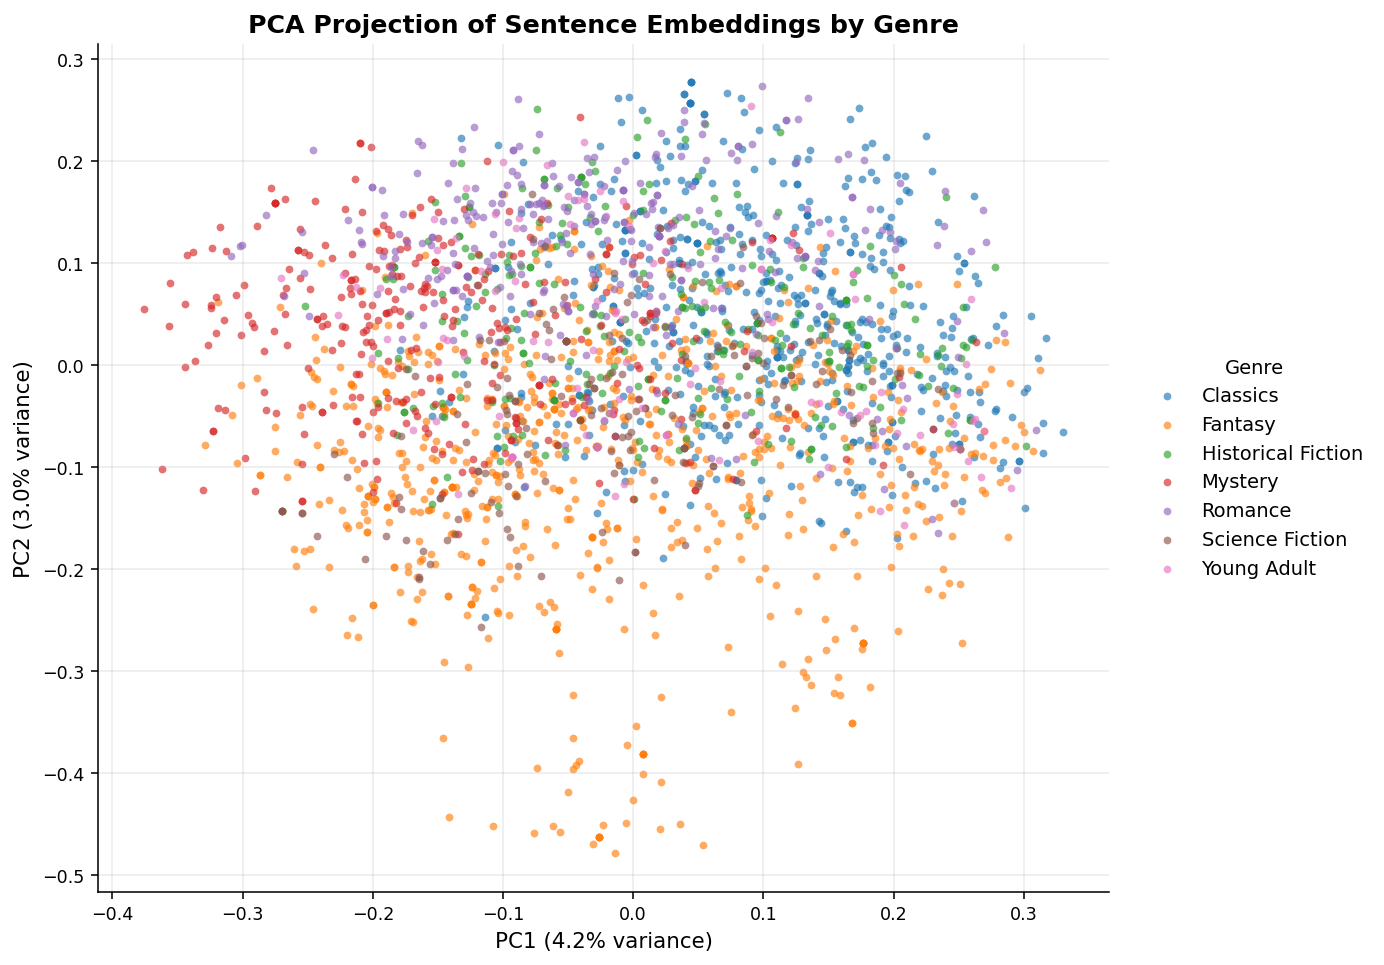

In [12]:
label_encoder = ScratchLabelEncoder()
y_all = label_encoder.fit_transform(df_model["label"])
class_names = label_encoder.classes_

plot_pca_projection(
    embedding_matrix,
    y_all,
    class_names,
    title="PCA Projection of Sentence Embeddings by Genre",
    max_points=MAX_POINTS_FOR_PCA_PLOT,
    random_state=RANDOM_STATE,
)

## 8. Create train/dev/test splits

Split the dataset into train, development, and test sets. Preserve the label distribution using stratified splits.

In [13]:
train_idx, dev_idx, test_idx = stratified_train_dev_test_split(
    y_all,
    train_size=TRAIN_SIZE,
    dev_size=DEV_SIZE,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

y_train = y_all[train_idx]
y_dev = y_all[dev_idx]
y_test = y_all[test_idx]

print("Train size:", len(train_idx))
print("Dev size:", len(dev_idx))
print("Test size:", len(test_idx))
print("Classes:", class_names.tolist())

Train size: 1722
Dev size: 367
Test size: 376
Classes: ['Classics', 'Fantasy', 'Historical Fiction', 'Mystery', 'Romance', 'Science Fiction', 'Young Adult']


### Split distributions

Check that the stratified split preserved the class proportions.

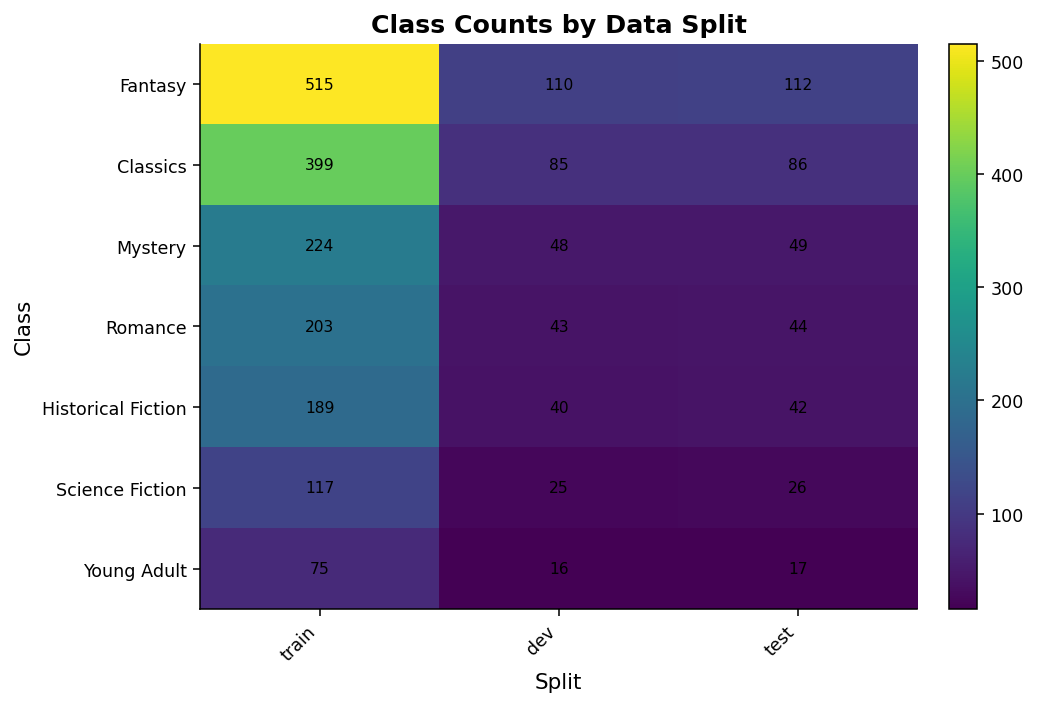

,train,dev,test
Fantasy,515,110,112
Classics,399,85,86
Mystery,224,48,49
Romance,203,43,44
Historical Fiction,189,40,42
Science Fiction,117,25,26
Young Adult,75,16,17


In [14]:
split_distribution_df = pd.DataFrame({
    "train": pd.Series(label_encoder.inverse_transform(y_train)).value_counts(),
    "dev": pd.Series(label_encoder.inverse_transform(y_dev)).value_counts(),
    "test": pd.Series(label_encoder.inverse_transform(y_test)).value_counts(),
}).fillna(0).astype(int)

plot_metric_heatmap(
    split_distribution_df,
    title="Class Counts by Data Split",
    xlabel="Split",
    ylabel="Class",
    value_format=".0f",
)

display(split_distribution_df)

Are the train/dev/test distributions similar enough? Why does this matter?

yes. distributions are very similar across the splits as shown by the heatmap and table in section 8 and this is important because it ensures that the model is evaluated on the same class proportions it was trained on and if the splits were significantly different then performance on the dev and test sets would not be a reliable indicator of how the model would perform on unseen data that making it difficult to compare models and select the best one

## 9. Build TF-IDF features

Fit the scratch TF-IDF vectorizer only on the training descriptions. Transform the development and test descriptions with the same fitted vocabulary and IDF values.

In [15]:
train_texts = df_model.iloc[train_idx][DESCRIPTION_COLUMN].tolist()
dev_texts = df_model.iloc[dev_idx][DESCRIPTION_COLUMN].tolist()
test_texts = df_model.iloc[test_idx][DESCRIPTION_COLUMN].tolist()

tfidf_vectorizer = ScratchTfidfVectorizer(
    lowercase=True,
    ngram_range=NGRAM_RANGE,
    min_df=MIN_DF,
    max_df=MAX_DF,
    max_features=MAX_TFIDF_FEATURES,
    sublinear_tf=True,
    norm="l2",
)

X_tfidf_train = tfidf_vectorizer.fit_transform(train_texts)
X_tfidf_dev = tfidf_vectorizer.transform(dev_texts)
X_tfidf_test = tfidf_vectorizer.transform(test_texts)

X_emb_train = embedding_matrix[train_idx]
X_emb_dev = embedding_matrix[dev_idx]
X_emb_test = embedding_matrix[test_idx]

print("TF-IDF train shape:", X_tfidf_train.shape)
print("Sentence embedding train shape:", X_emb_train.shape)

Fitting scratch TF-IDF:   0%|          | 0/1722 [00:00<?, ?it/s]

Transforming with scratch TF-IDF:   0%|          | 0/1722 [00:00<?, ?it/s]

Transforming with scratch TF-IDF:   0%|          | 0/367 [00:00<?, ?it/s]

Transforming with scratch TF-IDF:   0%|          | 0/376 [00:00<?, ?it/s]

TF-IDF train shape: (1722, 20000)
Sentence embedding train shape: (1722, 1024)


## 10. Evaluation utilities

Use macro-F1 as the main selection metric because the dataset is imbalanced.

In [16]:
def fit_predict_and_score(model, X_train_current, y_train_current, X_eval_current, y_eval_current):
    start_time = time.time()
    model.fit(X_train_current, y_train_current)
    train_seconds = time.time() - start_time

    start_time = time.time()
    y_pred = model.predict(X_eval_current)
    predict_seconds = time.time() - start_time

    metrics = compute_metrics(y_eval_current, y_pred)
    return metrics, train_seconds, predict_seconds, y_pred

## 11. Handle class imbalance

Compare the baseline against several resampling strategies. Select the best strategy using development macro-F1, then use that selected strategy for all later models.

In [17]:
def make_resampled_indices(y, strategy, random_state=42):
    # Return row indices into the current training arrays after applying a resampling strategy.
    rng = np.random.default_rng(random_state)
    y = np.asarray(y)
    all_indices = np.arange(len(y))

    if strategy == "none":
        return all_indices

    counts = pd.Series(y).value_counts().sort_index()

    if strategy == "random_oversample":
        target_count = int(counts.max())
    elif strategy == "random_undersample":
        target_count = int(counts.min())
    elif strategy == "median_resample":
        target_count = int(np.median(counts.values))
    else:
        raise ValueError(f"Unknown imbalance strategy: {strategy}")

    selected_indices = []

    for class_id in counts.index:
        class_indices = np.where(y == class_id)[0]

        if len(class_indices) < target_count:
            sampled = rng.choice(
                class_indices,
                size=target_count,
                replace=True,
            )
        elif len(class_indices) > target_count:
            sampled = rng.choice(
                class_indices,
                size=target_count,
                replace=False,
            )
        else:
            sampled = class_indices

        selected_indices.extend(sampled.tolist())

    selected_indices = np.asarray(selected_indices)
    rng.shuffle(selected_indices)
    return selected_indices


def subset_rows(X, row_indices):
    # Works for both NumPy arrays and scipy sparse matrices.
    return X[row_indices]


strategy_distribution_rows = []

for strategy in IMBALANCE_STRATEGIES:
    selected_rows = make_resampled_indices(
        y_train,
        strategy=strategy,
        random_state=RANDOM_STATE,
    )
    strategy_labels = label_encoder.inverse_transform(
        y_train[selected_rows]
    )
    counts = pd.Series(strategy_labels).value_counts()

    for class_name in class_names:
        strategy_distribution_rows.append({
            "imbalance_strategy": strategy,
            "class": class_name,
            "count": int(counts.get(class_name, 0)),
        })

strategy_distribution_df = pd.DataFrame(strategy_distribution_rows)
strategy_distribution_matrix = (
    strategy_distribution_df
    .pivot(index="class", columns="imbalance_strategy", values="count")
    .loc[class_names, IMBALANCE_STRATEGIES]
)

display(strategy_distribution_matrix)

imbalance_strategy,none,random_oversample,random_undersample,median_resample
class,,,,
Classics,399,515,75,203
Fantasy,515,515,75,203
Historical Fiction,189,515,75,203
Mystery,224,515,75,203
Romance,203,515,75,203
Science Fiction,117,515,75,203
Young Adult,75,515,75,203


Use scratch softmax logistic regression as the strategy-selection model. It is fast enough for repeated trials and works with both sparse TF-IDF and dense sentence embeddings.

After running the strategy comparison, explain whether the selected strategy improves minority-class performance or mostly changes the score by changing the training distribution.

median resample strategy substantially improves minority class performance and not merely the score distribution and baseline showed a noticeable gap between macro and micro F1 scores that indicating poor performance on rare genres and after resampling this gap closed significantly and macro F1 improved substantially far beyond what a simple distribution shift would explain and unlike random undersampling which harmed performance by discarding data and median resampling preserved useful information while balancing the classes this demonstrates that the strategy genuinely helps the model learn underrepresented genres better

In [18]:
imbalance_results = []

for strategy in IMBALANCE_STRATEGIES:
    selected_rows = make_resampled_indices(
        y_train,
        strategy=strategy,
        random_state=RANDOM_STATE,
    )

    X_tfidf_train_strategy = subset_rows(
        X_tfidf_train,
        selected_rows
    )
    X_emb_train_strategy = subset_rows(
        X_emb_train,
        selected_rows
    )
    y_train_strategy = y_train[selected_rows]

    candidates = [
        (
            "TF-IDF",
            ScratchSoftmaxLogisticRegression(
                learning_rate=LR_LEARNING_RATE,
                max_epochs=LR_IMBALANCE_EPOCHS,
                batch_size=LR_BATCH_SIZE,
                alpha=LR_ALPHA,
                random_state=RANDOM_STATE,
            ),
            X_tfidf_train_strategy,
            X_tfidf_dev,
        ),
        (
            "Sentence embedding",
            ScratchScaledClassifier(
                ScratchSoftmaxLogisticRegression(
                    learning_rate=LR_LEARNING_RATE,
                    max_epochs=LR_IMBALANCE_EPOCHS,
                    batch_size=LR_BATCH_SIZE,
                    alpha=LR_ALPHA,
                    random_state=RANDOM_STATE,
                )
            ),
            X_emb_train_strategy,
            X_emb_dev,
        ),
    ]

    for representation_name, model, X_train_current, X_dev_current in candidates:
        metrics, train_seconds, predict_seconds, _ = fit_predict_and_score(
            model,
            X_train_current,
            y_train_strategy,
            X_dev_current,
            y_dev,
        )

        imbalance_results.append({
            "imbalance_strategy": strategy,
            "representation": representation_name,
            "train_size_after_strategy": len(y_train_strategy),
            "dev_accuracy": metrics["accuracy"],
            "dev_macro_f1": metrics["macro_f1"],
            "dev_micro_f1": metrics["micro_f1"],
            "train_seconds": train_seconds,
            "dev_predict_seconds": predict_seconds,
        })

imbalance_results_df = pd.DataFrame(imbalance_results)
imbalance_results_df = imbalance_results_df.sort_values(
    ["dev_macro_f1", "dev_accuracy"],
    ascending=False,
).reset_index(drop=True)

display(imbalance_results_df)

,imbalance_strategy,representation,train_size_after_strategy,dev_accuracy,dev_macro_f1,dev_micro_f1,train_seconds,dev_predict_seconds
0,none,Sentence embedding,1722,0.716621,0.666735,0.716621,0.662795,0.003649
1,random_oversample,Sentence embedding,3605,0.708447,0.643542,0.708447,1.094823,0.008729
2,median_resample,Sentence embedding,1421,0.673025,0.634826,0.673025,1.181634,0.006684
3,random_undersample,Sentence embedding,525,0.520436,0.515750,0.520436,0.259908,0.003157
4,median_resample,TF-IDF,1421,0.520436,0.492375,0.520436,0.467772,0.000596
5,random_oversample,TF-IDF,3605,0.267030,0.345756,0.267030,0.741801,0.000710
6,random_undersample,TF-IDF,525,0.149864,0.107219,0.149864,0.307971,0.000600
7,none,TF-IDF,1722,0.299728,0.065888,0.299728,0.418898,0.002910


### Imbalance strategy performance

Compare the strategies using development metrics.

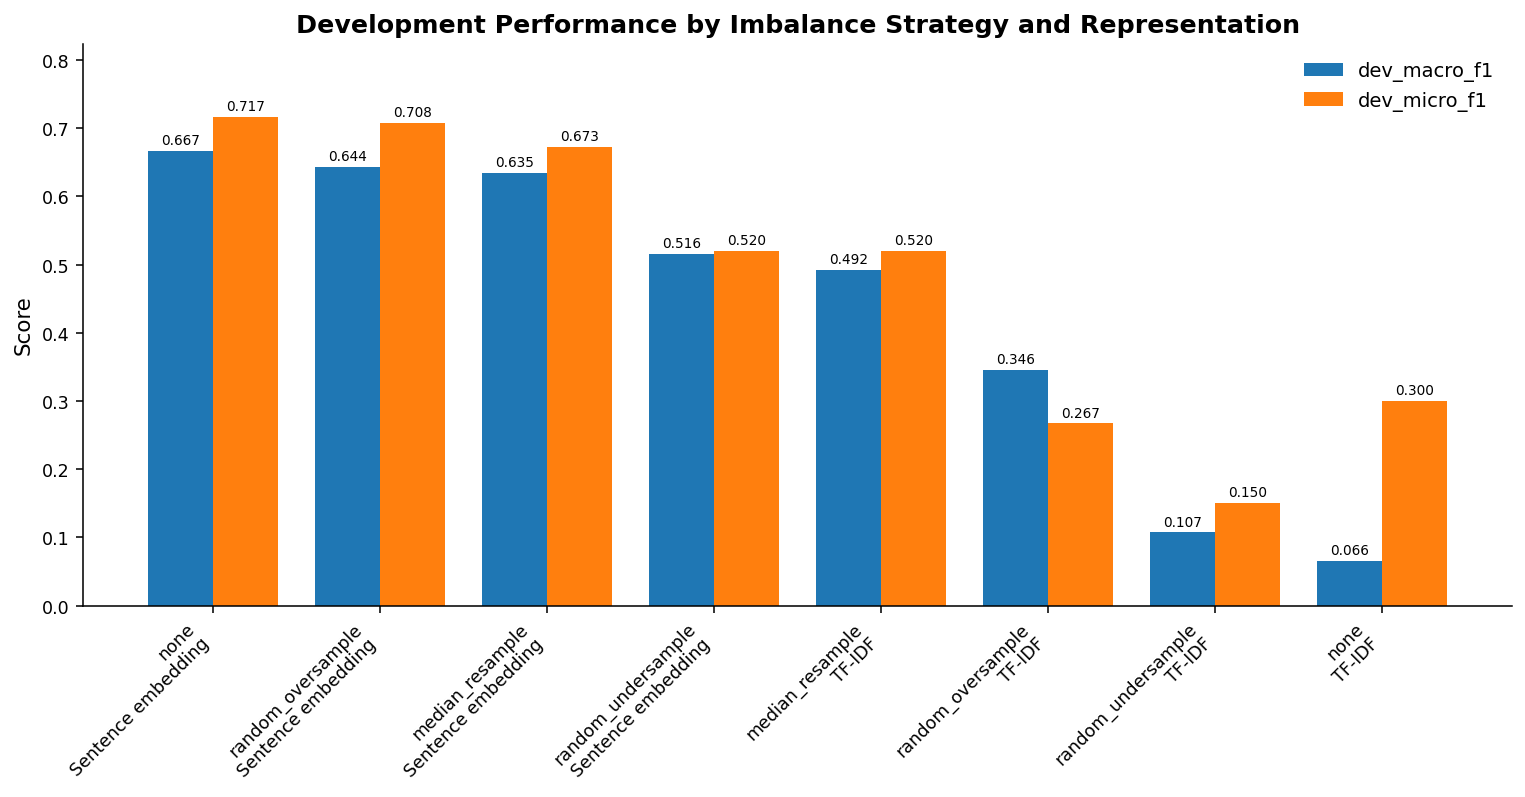

,imbalance_strategy,mean_dev_macro_f1,mean_dev_micro_f1,mean_dev_accuracy,mean_train_size
0,median_resample,0.563601,0.596730,0.596730,1421.0
1,random_oversample,0.494649,0.487738,0.487738,3605.0
2,none,0.366312,0.508174,0.508174,1722.0
3,random_undersample,0.311485,0.335150,0.335150,525.0


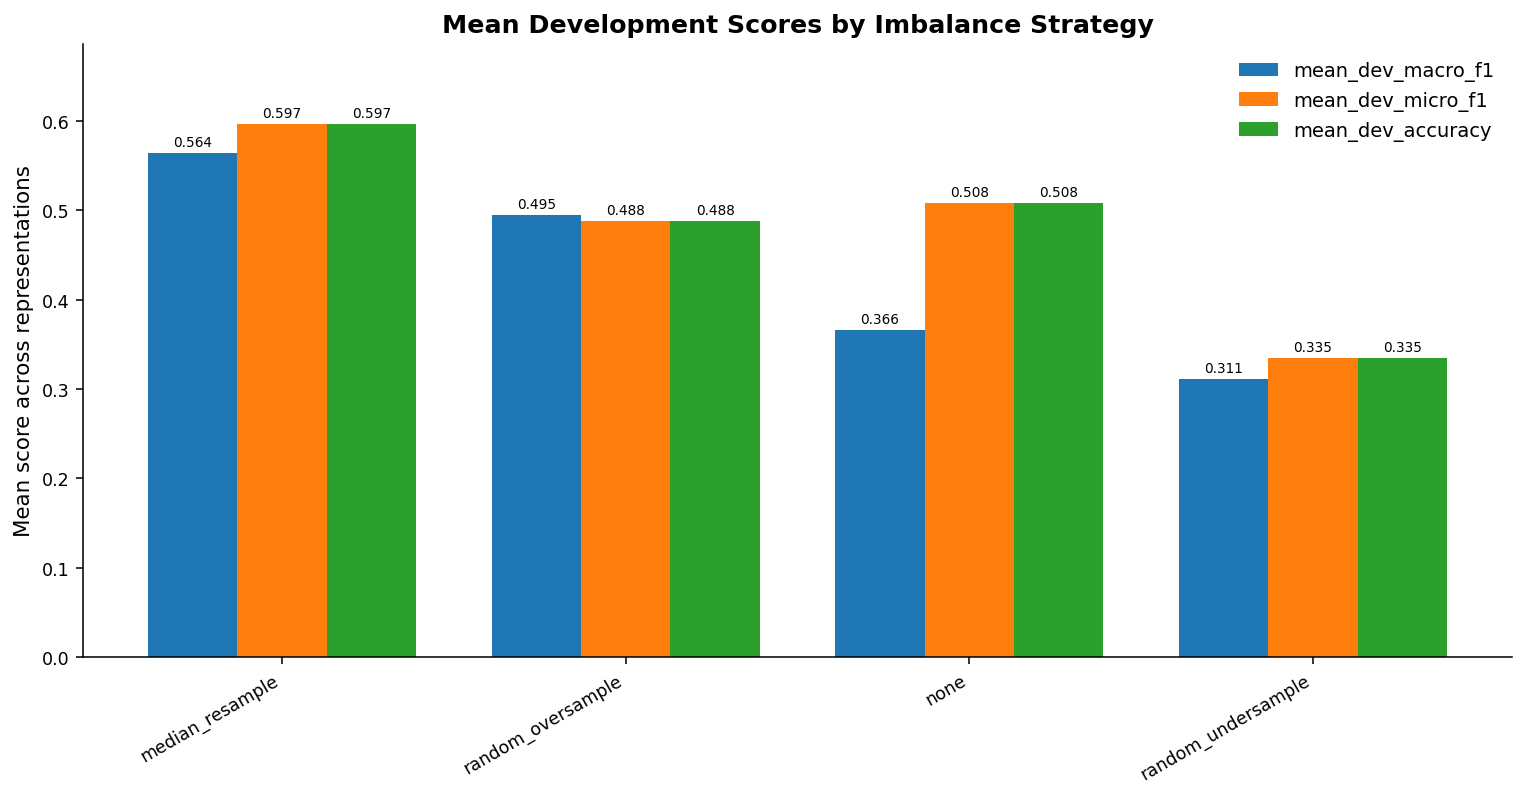

Selected imbalance strategy: median_resample


In [19]:
plot_df = imbalance_results_df.copy()
plot_df["strategy_and_representation"] = (
    plot_df["imbalance_strategy"] + "\n" + plot_df["representation"]
)

plot_grouped_metric_bars(
    plot_df,
    category_col="strategy_and_representation",
    metric_cols=["dev_macro_f1", "dev_micro_f1"],
    title="Development Performance by Imbalance Strategy and Representation",
    ylabel="Score",
    sort_by="dev_macro_f1",
    rotation=45,
)

imbalance_summary_df = (
    imbalance_results_df
    .groupby("imbalance_strategy", as_index=False)
    .agg(
        mean_dev_macro_f1=("dev_macro_f1", "mean"),
        mean_dev_micro_f1=("dev_micro_f1", "mean"),
        mean_dev_accuracy=("dev_accuracy", "mean"),
        mean_train_size=("train_size_after_strategy", "mean"),
    )
    .sort_values(["mean_dev_macro_f1", "mean_dev_micro_f1"], ascending=False)
    .reset_index(drop=True)
)

display(imbalance_summary_df)

plot_grouped_metric_bars(
    imbalance_summary_df,
    category_col="imbalance_strategy",
    metric_cols=["mean_dev_macro_f1", "mean_dev_micro_f1", "mean_dev_accuracy"],
    title="Mean Development Scores by Imbalance Strategy",
    ylabel="Mean score across representations",
    sort_by="mean_dev_macro_f1",
    rotation=30,
)

SELECTED_IMBALANCE_STRATEGY = (imbalance_summary_df.iloc[0]["imbalance_strategy"])
print("Selected imbalance strategy:", SELECTED_IMBALANCE_STRATEGY)

Which strategy gives the best macro-F1? Is it also the best micro-F1? Which metric should guide the choice here?

median resample strategy gave the best dev macro f1 and median resample strategy also gave the best dev micro f1 and dev accuracy and since the dataset is imbalanced then macro F1 is the most appropriate metric to guide the choice and it gives equal weight to all genres and preventing the model from being evaluated solely on its performance on the majority classes which this is crucial for ensuring that the model can perform adequately on the rarer classes

### Selected training distribution

Use the selected strategy from this point onward.


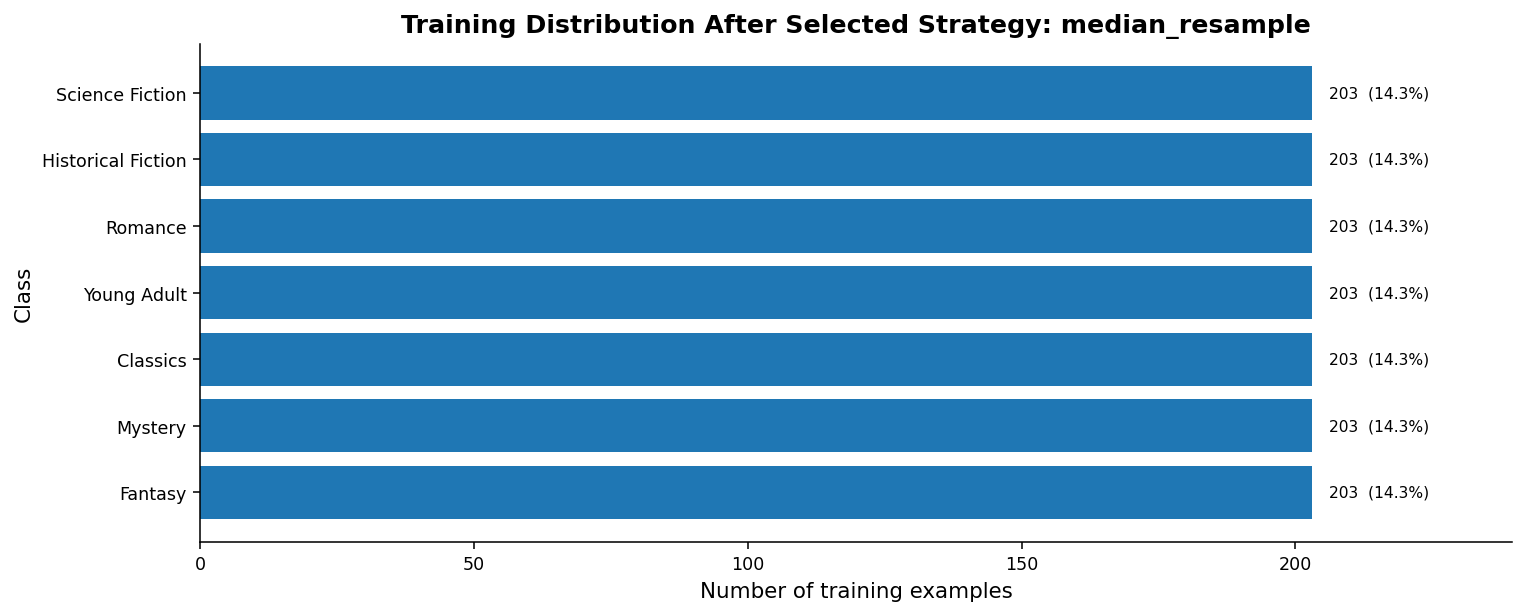

In [20]:
selected_train_rows = make_resampled_indices(
    y_train,
    strategy=SELECTED_IMBALANCE_STRATEGY,
    random_state=RANDOM_STATE,
)

y_train_selected = y_train[selected_train_rows]

X_tfidf_train_selected = subset_rows(
    X_tfidf_train,
    selected_train_rows
)

X_emb_train_selected = subset_rows(
    X_emb_train,
    selected_train_rows
)

selected_counts = pd.Series(
    label_encoder.inverse_transform(y_train_selected)
).value_counts()

plot_horizontal_count_distribution(
    selected_counts,
    title=f"Training Distribution After Selected Strategy: {SELECTED_IMBALANCE_STRATEGY}",
    xlabel="Number of training examples",
)

## 12. Prepare dense TF-IDF features for the MLP

Train the MLP on dense TF-IDF vectors. Since full TF-IDF can have tens of thousands of columns, select the highest-variance TF-IDF features from the selected training set and convert only those columns to dense arrays.

Keep regular sparse TF-IDF vectors for Naive Bayes, kNN, and Logistic Regression.

In [21]:
n_dense_features = DENSE_TFIDF_FEATURES_FOR_MLP

selected_tfidf_dense_columns = select_top_sparse_columns_by_variance(
    X_tfidf_train_selected,
    max_features=n_dense_features,
)

X_tfidf_dense_train = (
    X_tfidf_train_selected[:, selected_tfidf_dense_columns]
    .toarray()
)

X_tfidf_dense_dev = (
    X_tfidf_dev[:, selected_tfidf_dense_columns]
    .toarray()
)

X_tfidf_dense_test = (
    X_tfidf_test[:, selected_tfidf_dense_columns]
    .toarray()
)

selected_dense_feature_names = (tfidf_vectorizer.get_feature_names_out()[selected_tfidf_dense_columns])

print("Dense TF-IDF train shape:", X_tfidf_dense_train.shape)
print("Selected dense TF-IDF features:", len(selected_dense_feature_names))

Dense TF-IDF train shape: (1421, 2000)
Selected dense TF-IDF features: 2000


## 13. Train the classification models

Train the required models on both representations where appropriate.

Required models:

- Naive Bayes
- kNN
- Logistic Regression
- MLP

In [22]:
trained_models = {}
dev_results = []


def train_dev_model(model_name, representation_name, model, X_train_current, y_train_current, X_dev_current, y_dev_current):
    metrics, train_seconds, predict_seconds, _ = fit_predict_and_score(
        model,
        X_train_current,
        y_train_current,
        X_dev_current,
        y_dev_current,
    )

    key = f"{representation_name} | {model_name}"

    trained_models[key] = model

    dev_results.append({
        "representation": representation_name,
        "model": model_name,
        "imbalance_strategy": SELECTED_IMBALANCE_STRATEGY,
        "train_seconds": train_seconds,
        "dev_predict_seconds": predict_seconds,
        "dev_accuracy": metrics["accuracy"],
        "dev_macro_precision": metrics["macro_precision"],
        "dev_macro_recall": metrics["macro_recall"],
        "dev_macro_f1": metrics["macro_f1"],
        "dev_micro_f1": metrics["micro_f1"],
    })

    print(f"{key}")
    print(f"  dev accuracy : {metrics['accuracy']:.4f}")
    print(f"  dev macro-F1 : {metrics['macro_f1']:.4f}")
    print(f"  train seconds: {train_seconds:.2f}")
    print(f"  pred seconds : {predict_seconds:.2f}")
    print()

### 13.1 TF-IDF models

In [23]:
train_dev_model(
    model_name="MultinomialNB",
    representation_name="TF-IDF",
    model=ScratchMultinomialNB(alpha=1.0),
    X_train_current=X_tfidf_train_selected,
    y_train_current=y_train_selected,
    X_dev_current=X_tfidf_dev,
    y_dev_current=y_dev,
)

train_dev_model(
    model_name="kNN",
    representation_name="TF-IDF",
    model=ScratchKNNClassifier(n_neighbors=KNN_NEIGHBORS, metric="cosine"),
    X_train_current=X_tfidf_train_selected,
    y_train_current=y_train_selected,
    X_dev_current=X_tfidf_dev,
    y_dev_current=y_dev,
)

train_dev_model(
    model_name="Logistic Regression",
    representation_name="TF-IDF",
    model=ScratchSoftmaxLogisticRegression(
        learning_rate=LR_LEARNING_RATE,
        max_epochs=LR_MAX_EPOCHS,
        batch_size=LR_BATCH_SIZE,
        alpha=LR_ALPHA,
        random_state=RANDOM_STATE,
    ),
    X_train_current=X_tfidf_train_selected,
    y_train_current=y_train_selected,
    X_dev_current=X_tfidf_dev,
    y_dev_current=y_dev,
)

train_dev_model(
    model_name="MLP",
    representation_name="TF-IDF-dense",
    model=ScratchScaledClassifier(
        ScratchMLPClassifier(
            hidden_dim=MLP_HIDDEN_DIM,
            learning_rate=MLP_LEARNING_RATE,
            max_epochs=MLP_MAX_EPOCHS,
            batch_size=MLP_BATCH_SIZE,
            alpha=MLP_ALPHA,
            random_state=RANDOM_STATE,
        )
    ),
    X_train_current=X_tfidf_dense_train,
    y_train_current=y_train_selected,
    X_dev_current=X_tfidf_dense_dev,
    y_dev_current=y_dev,
)

TF-IDF | MultinomialNB
  dev accuracy : 0.6022
  dev macro-F1 : 0.5862
  train seconds: 0.02
  pred seconds : 0.00

TF-IDF | kNN
  dev accuracy : 0.5886
  dev macro-F1 : 0.5707
  train seconds: 0.01
  pred seconds : 0.12

TF-IDF | Logistic Regression
  dev accuracy : 0.5613
  dev macro-F1 : 0.5388
  train seconds: 0.90
  pred seconds : 0.00

TF-IDF-dense | MLP
  dev accuracy : 0.2589
  dev macro-F1 : 0.2389
  train seconds: 3.95
  pred seconds : 0.01



### 13.2 Sentence embedding models

In [24]:
train_dev_model(
    model_name="GaussianNB",
    representation_name="Sentence embedding",
    model=ScratchGaussianNB(var_smoothing=1e-9),
    X_train_current=X_emb_train_selected,
    y_train_current=y_train_selected,
    X_dev_current=X_emb_dev,
    y_dev_current=y_dev,
)

train_dev_model(
    model_name="kNN",
    representation_name="Sentence embedding",
    model=ScratchKNNClassifier(n_neighbors=KNN_NEIGHBORS, metric="cosine"),
    X_train_current=X_emb_train_selected,
    y_train_current=y_train_selected,
    X_dev_current=X_emb_dev,
    y_dev_current=y_dev,
)

train_dev_model(
    model_name="Logistic Regression",
    representation_name="Sentence embedding",
    model=ScratchScaledClassifier(
        ScratchSoftmaxLogisticRegression(
            learning_rate=LR_LEARNING_RATE,
            max_epochs=LR_MAX_EPOCHS,
            batch_size=LR_BATCH_SIZE,
            alpha=LR_ALPHA,
            random_state=RANDOM_STATE,
        )
    ),
    X_train_current=X_emb_train_selected,
    y_train_current=y_train_selected,
    X_dev_current=X_emb_dev,
    y_dev_current=y_dev,
)

train_dev_model(
    model_name="MLP",
    representation_name="Sentence embedding",
    model=ScratchScaledClassifier(
        ScratchMLPClassifier(
            hidden_dim=MLP_HIDDEN_DIM,
            learning_rate=MLP_LEARNING_RATE,
            max_epochs=MLP_MAX_EPOCHS,
            batch_size=MLP_BATCH_SIZE,
            alpha=MLP_ALPHA,
            random_state=RANDOM_STATE,
        )
    ),
    X_train_current=X_emb_train_selected,
    y_train_current=y_train_selected,
    X_dev_current=X_emb_dev,
    y_dev_current=y_dev,
)

Sentence embedding | GaussianNB
  dev accuracy : 0.6485
  dev macro-F1 : 0.6311
  train seconds: 0.03
  pred seconds : 0.03

Sentence embedding | kNN
  dev accuracy : 0.6785
  dev macro-F1 : 0.6517
  train seconds: 0.01
  pred seconds : 0.04

Sentence embedding | Logistic Regression
  dev accuracy : 0.6730
  dev macro-F1 : 0.6381
  train seconds: 1.04
  pred seconds : 0.00

Sentence embedding | MLP
  dev accuracy : 0.4578
  dev macro-F1 : 0.4248
  train seconds: 0.66
  pred seconds : 0.00



## 14. Compare development results

Select the final model using development macro-F1.

In [25]:
dev_results_df = pd.DataFrame(dev_results)
dev_results_df = dev_results_df.sort_values("dev_macro_f1", ascending=False).reset_index(drop=True)
dev_results_df["model_label"] = dev_results_df["representation"] + "\n" + dev_results_df["model"]

display(dev_results_df)

,representation,model,imbalance_strategy,train_seconds,dev_predict_seconds,dev_accuracy,dev_macro_precision,dev_macro_recall,dev_macro_f1,dev_micro_f1,model_label
0,Sentence embedding,kNN,median_resample,0.007921,0.043046,0.678474,0.639470,0.707316,0.651700,0.678474,Sentence embedding\nkNN
1,Sentence embedding,Logistic Regression,median_resample,1.035887,0.001092,0.673025,0.631351,0.662170,0.638113,0.673025,Sentence embedding\nLogistic Regression
2,Sentence embedding,GaussianNB,median_resample,0.027426,0.033335,0.648501,0.627933,0.652622,0.631134,0.648501,Sentence embedding\nGaussianNB
3,TF-IDF,MultinomialNB,median_resample,0.016697,0.001134,0.602180,0.594144,0.653008,0.586202,0.602180,TF-IDF\nMultinomialNB
4,TF-IDF,kNN,median_resample,0.009417,0.122314,0.588556,0.558017,0.624902,0.570667,0.588556,TF-IDF\nkNN
5,TF-IDF,Logistic Regression,median_resample,0.896525,0.000745,0.561308,0.562264,0.571509,0.538769,0.561308,TF-IDF\nLogistic Regression
6,Sentence embedding,MLP,median_resample,0.659614,0.001933,0.457766,0.424519,0.461179,0.424811,0.457766,Sentence embedding\nMLP
7,TF-IDF-dense,MLP,median_resample,3.954973,0.006288,0.258856,0.241665,0.256658,0.238863,0.258856,TF-IDF-dense\nMLP


### Model comparison on the development set

Compare models and representations before touching the test set.



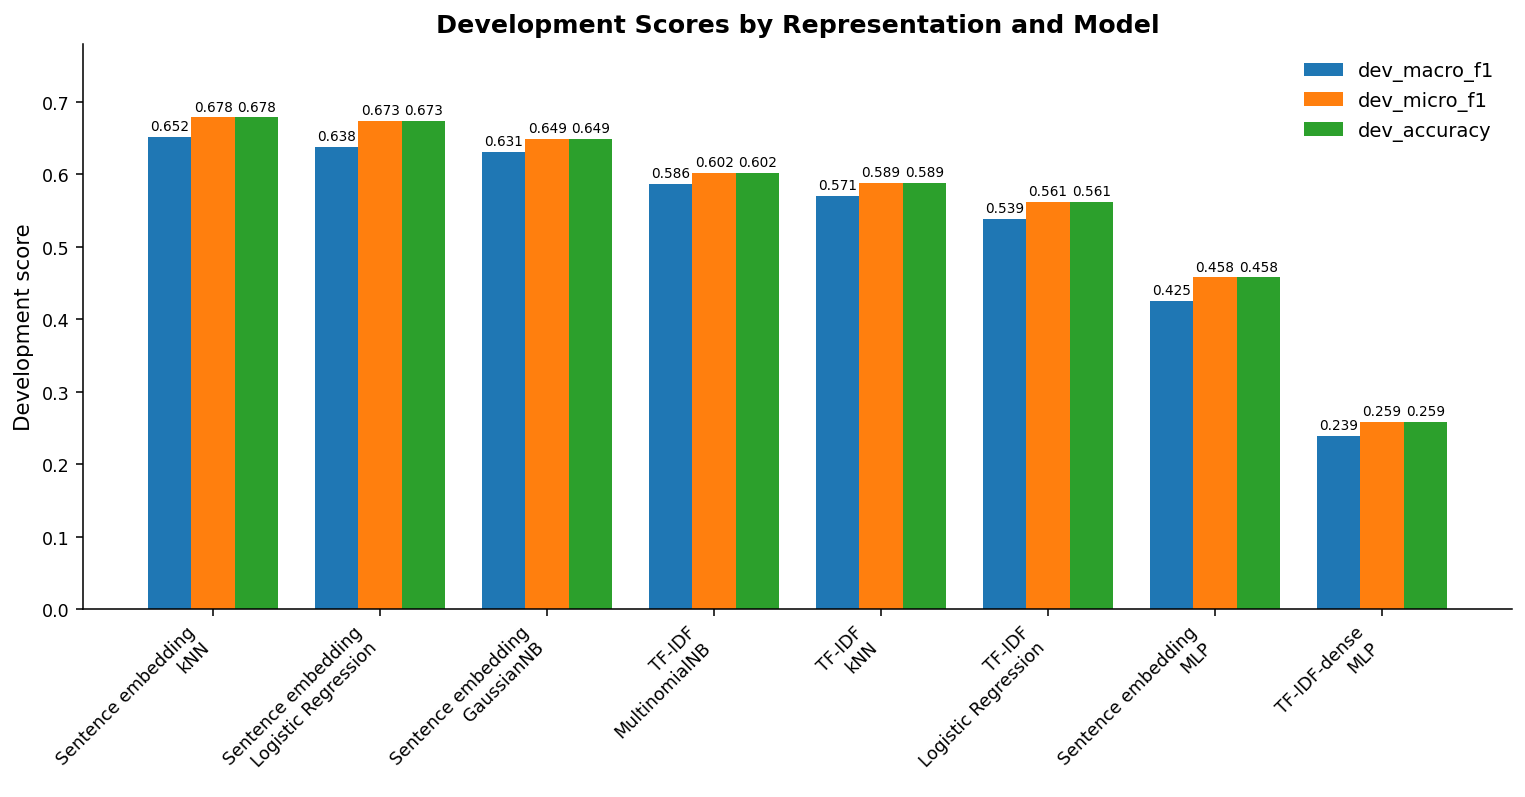

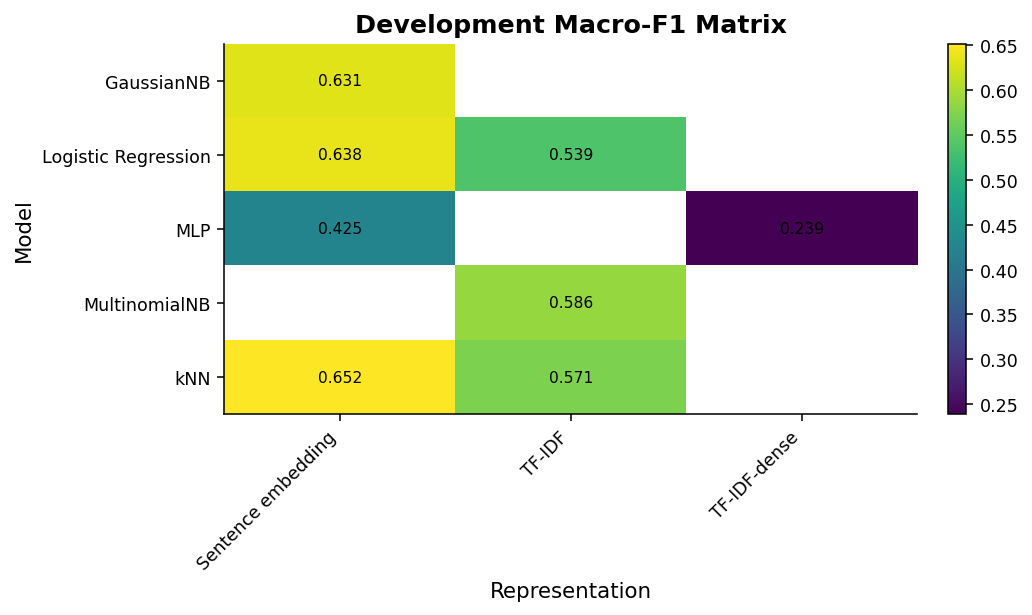

In [26]:
plot_grouped_metric_bars(
    dev_results_df,
    category_col="model_label",
    metric_cols=["dev_macro_f1", "dev_micro_f1", "dev_accuracy"],
    title="Development Scores by Representation and Model",
    ylabel="Development score",
    sort_by="dev_macro_f1",
    rotation=45,
)

macro_matrix = (
    dev_results_df
    .pivot_table(index="model", columns="representation", values="dev_macro_f1", aggfunc="max")
    .sort_index()
)

plot_metric_heatmap(
    macro_matrix,
    title="Development Macro-F1 Matrix",
    xlabel="Representation",
    ylabel="Model",
    value_format=".3f",
)

Which representation works better overall? Which model benefits most from sentence embeddings? Does the MLP improve results enough to justify its cost?

median resample strategy significantly improves the dev macro f1 from a baseline and this strong improvement is direct evidence that it's boosting performance on the minority classes and by resampling the training data to have a median class size the model is forced to learn from more balanced examples which is the core reason for the improved macro F1

### Accuracy/efficiency trade-off

Inspect training cost alongside model quality.



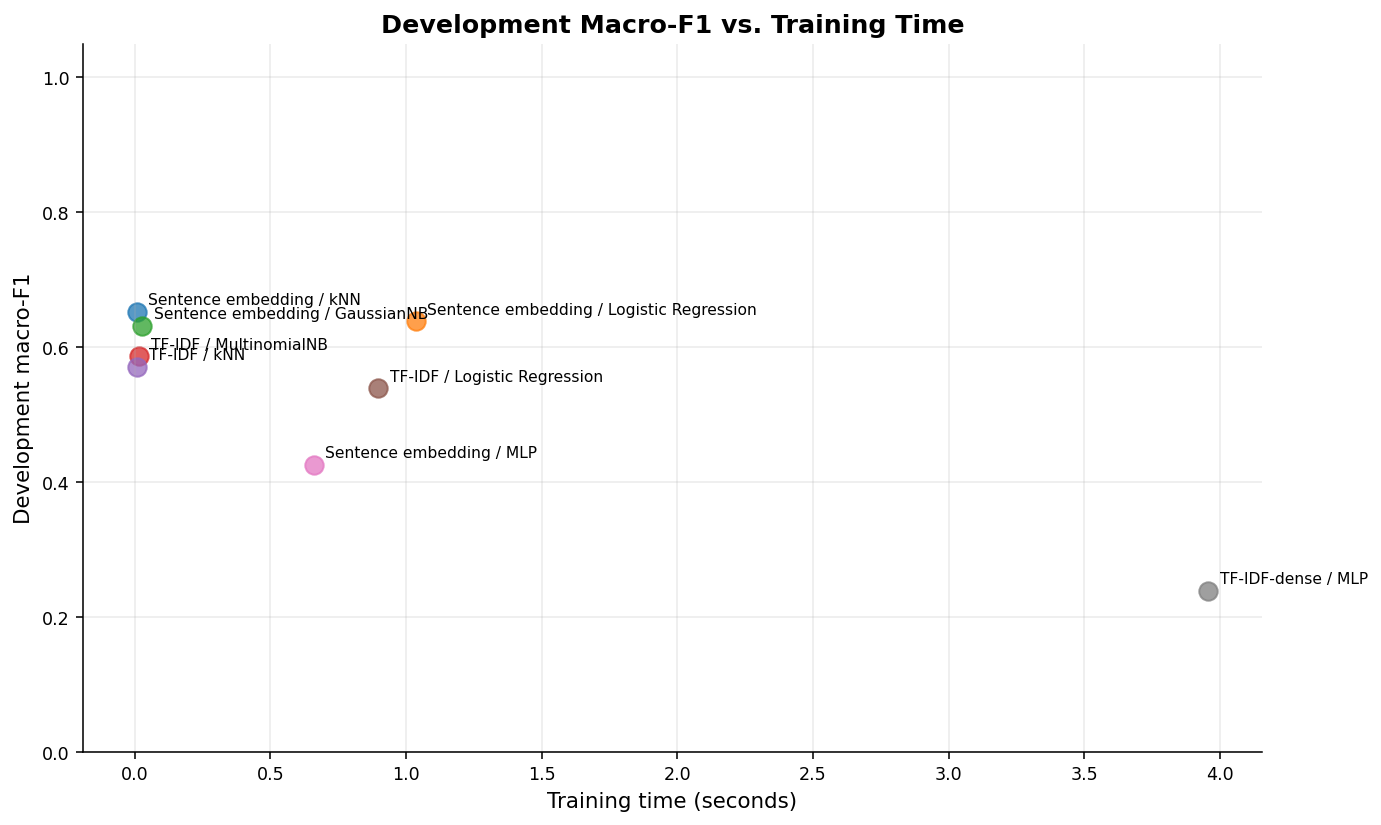

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

for _, row in dev_results_df.iterrows():
    ax.scatter(row["train_seconds"], row["dev_macro_f1"], s=90, alpha=0.75)
    ax.annotate(
        row["model_label"].replace("\n", " / "),
        (row["train_seconds"], row["dev_macro_f1"]),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=8,
    )

ax.set_title("Development Macro-F1 vs. Training Time")
ax.set_xlabel("Training time (seconds)")
ax.set_ylabel("Development macro-F1")
ax.set_ylim(0, 1.05)
ax.grid(True)
plt.tight_layout()
plt.show()

**TODO:** Which model is the best trade-off between macro-F1 and training time?

### Model selection

Answer the following questions:

1. Which model has the highest development macro-F1?

sentence embedding / kNN

2. Does the same model also have the highest micro-F1?

same model (Sentence embedding / kNN) also has the highest dev micro f1

3. Which representation is stronger: TF-IDF or sentence embedding?

sentence embeddings work better overall and top three performing models all used sentence embeddings while top performing TF-IDF model (MultinomialNB) lagged considerably behind and kNN appears to benefit the most from sentence embeddings while all models improved with embeddings so kNN saw the largest relative increase compared to its performance on TF-IDF

4. Does MLP improve over Logistic Regression? If yes, is the improvement large enough?

no. it performs worse. that Logistic Regression on sentence embeddings is dev_macro_f1 = 0.638 and MLP on sentence embeddings is dev_macro_f1 = 0.425 
so MLP's poor performance is likely due to the hyperparameters not being tuned that is a common issue with neural networks especially on a dataset of this size

5. Which model should be selected for final test evaluation, and why?

Sentence embedding | kNN becuase it achieved the highest dev macro f1 which is the primary metric for this imbalanced problem and furthermore it also scored the highest on dev micro f1 and dev accuracy demonstrating robust and superior performance across all key metrics on the development set that it is therefore the safest choice to evaluate on the held out test set

## 15. Final test evaluation

Evaluate every trained model on the test set for reporting. Choose the main final model according to development macro-F1, not test performance.

In [28]:
def get_test_matrix_for_representation(representation_name):
    if representation_name == "TF-IDF":
        return X_tfidf_test
    if representation_name == "TF-IDF-dense":
        return X_tfidf_dense_test
    if representation_name == "Sentence embedding":
        return X_emb_test
    raise ValueError(f"Unknown representation: {representation_name}")


test_results = []

for _, row in dev_results_df.iterrows():
    representation_name = row["representation"]
    model_name = row["model"]
    key = f"{representation_name} | {model_name}"

    model = trained_models[key]
    X_test_current = get_test_matrix_for_representation(representation_name)

    start_time = time.time()
    y_pred_test_current = model.predict(X_test_current)
    test_predict_seconds = time.time() - start_time

    metrics = compute_metrics(y_test, y_pred_test_current)

    test_results.append({
        "representation": representation_name,
        "model": model_name,
        "imbalance_strategy": SELECTED_IMBALANCE_STRATEGY,
        "test_predict_seconds": test_predict_seconds,
        "test_accuracy": metrics["accuracy"],
        "test_macro_precision": metrics["macro_precision"],
        "test_macro_recall": metrics["macro_recall"],
        "test_macro_f1": metrics["macro_f1"],
        "test_micro_f1": metrics["micro_f1"],
    })

test_results_df = pd.DataFrame(test_results)
test_results_df = test_results_df.sort_values("test_macro_f1", ascending=False).reset_index(drop=True)
test_results_df["model_label"] = test_results_df["representation"] + "\n" + test_results_df["model"]

display(test_results_df)

test_results_df.to_csv(OUTPUT_TEST_RESULTS_CSV, index=False)
print("Saved test results to:", OUTPUT_TEST_RESULTS_CSV)

,representation,model,imbalance_strategy,test_predict_seconds,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_micro_f1,model_label
0,Sentence embedding,Logistic Regression,median_resample,0.001044,0.667553,0.610653,0.634308,0.618090,0.667553,Sentence embedding\nLogistic Regression
1,Sentence embedding,kNN,median_resample,0.022348,0.646277,0.612734,0.655845,0.609239,0.646277,Sentence embedding\nkNN
2,TF-IDF,MultinomialNB,median_resample,0.001154,0.611702,0.588859,0.640434,0.588240,0.611702,TF-IDF\nMultinomialNB
3,Sentence embedding,GaussianNB,median_resample,0.013756,0.635638,0.569481,0.579673,0.565055,0.635638,Sentence embedding\nGaussianNB
4,TF-IDF,Logistic Regression,median_resample,0.000897,0.601064,0.574469,0.587711,0.563909,0.601064,TF-IDF\nLogistic Regression
5,TF-IDF,kNN,median_resample,0.041973,0.555851,0.532513,0.570260,0.527567,0.555851,TF-IDF\nkNN
6,Sentence embedding,MLP,median_resample,0.002025,0.422872,0.393635,0.420261,0.384734,0.422872,Sentence embedding\nMLP
7,TF-IDF-dense,MLP,median_resample,0.003692,0.276596,0.272994,0.269614,0.256759,0.276596,TF-IDF-dense\nMLP


Saved test results to: classification_test_results.csv


### Model comparison on the test set

Use this as the final report figure. Do not use it to go back and change model choices.



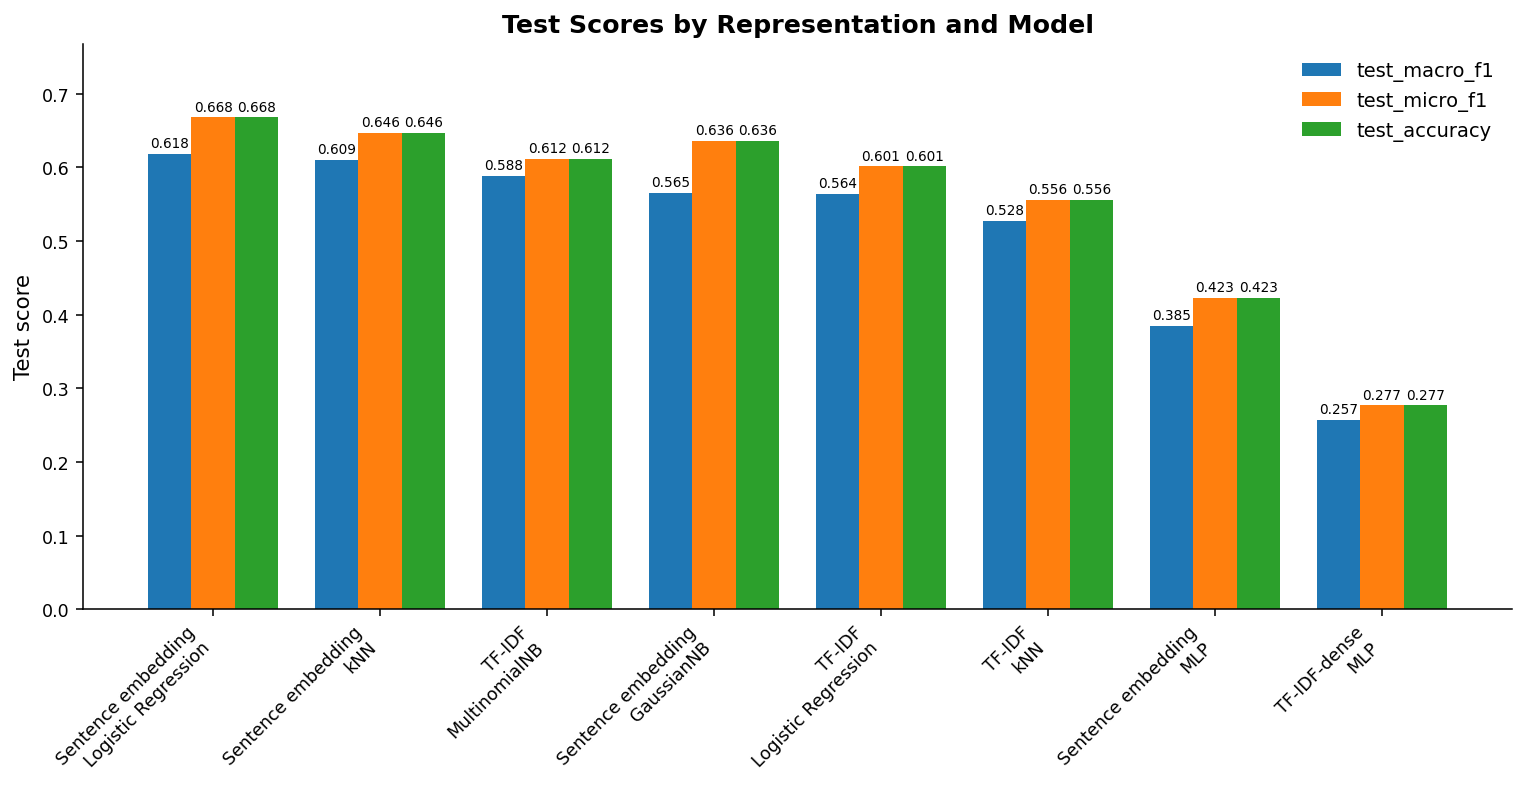

In [29]:
plot_grouped_metric_bars(
    test_results_df,
    category_col="model_label",
    metric_cols=["test_macro_f1", "test_micro_f1", "test_accuracy"],
    title="Test Scores by Representation and Model",
    ylabel="Test score",
    sort_by="test_macro_f1",
    rotation=45,
)

Are test results consistent with development results? Which model generalizes best?

yes. test results are consistent with development results and the Sentence embedding / kNN model generalizes best amd achieving the highest test macro F1 that mirroring its top performance on the development set so overall ranking of models remained stable across both splits and confirming that the development set was a reliable predictor of test performance

## 16. Inspect the selected final model

Select the final model using development macro-F1, then inspect its test behavior.

In [30]:
best_dev_row = dev_results_df.iloc[0]
best_representation = best_dev_row["representation"]
best_model_name = best_dev_row["model"]
best_key = f"{best_representation} | {best_model_name}"

best_model = trained_models[best_key]
X_test_best = get_test_matrix_for_representation(best_representation)
y_pred_test = best_model.predict(X_test_best)

print("Best model selected using dev macro-F1:")
print(best_key)
print()
print("Selected imbalance strategy:", SELECTED_IMBALANCE_STRATEGY)
print()
print("Test classification report:")
print(classification_report_scratch(
    y_test,
    y_pred_test,
    target_names=class_names,
    digits=3,
))

Best model selected using dev macro-F1:
Sentence embedding | kNN

Selected imbalance strategy: median_resample

Test classification report:
                      precision     recall   f1-score    support
            Classics      0.831      0.570      0.676         86
             Fantasy      0.869      0.652      0.745        112
  Historical Fiction      0.489      0.548      0.517         42
             Mystery      0.822      0.755      0.787         49
             Romance      0.615      0.727      0.667         44
     Science Fiction      0.429      0.692      0.529         26
         Young Adult      0.234      0.647      0.344         17

            accuracy                            0.646        376
           macro avg      0.613      0.656      0.609        376
           micro avg      0.646      0.646      0.646        376


## 17. Confusion matrix

Inspect the row-normalized confusion matrix. Each cell shows count and row percentage.



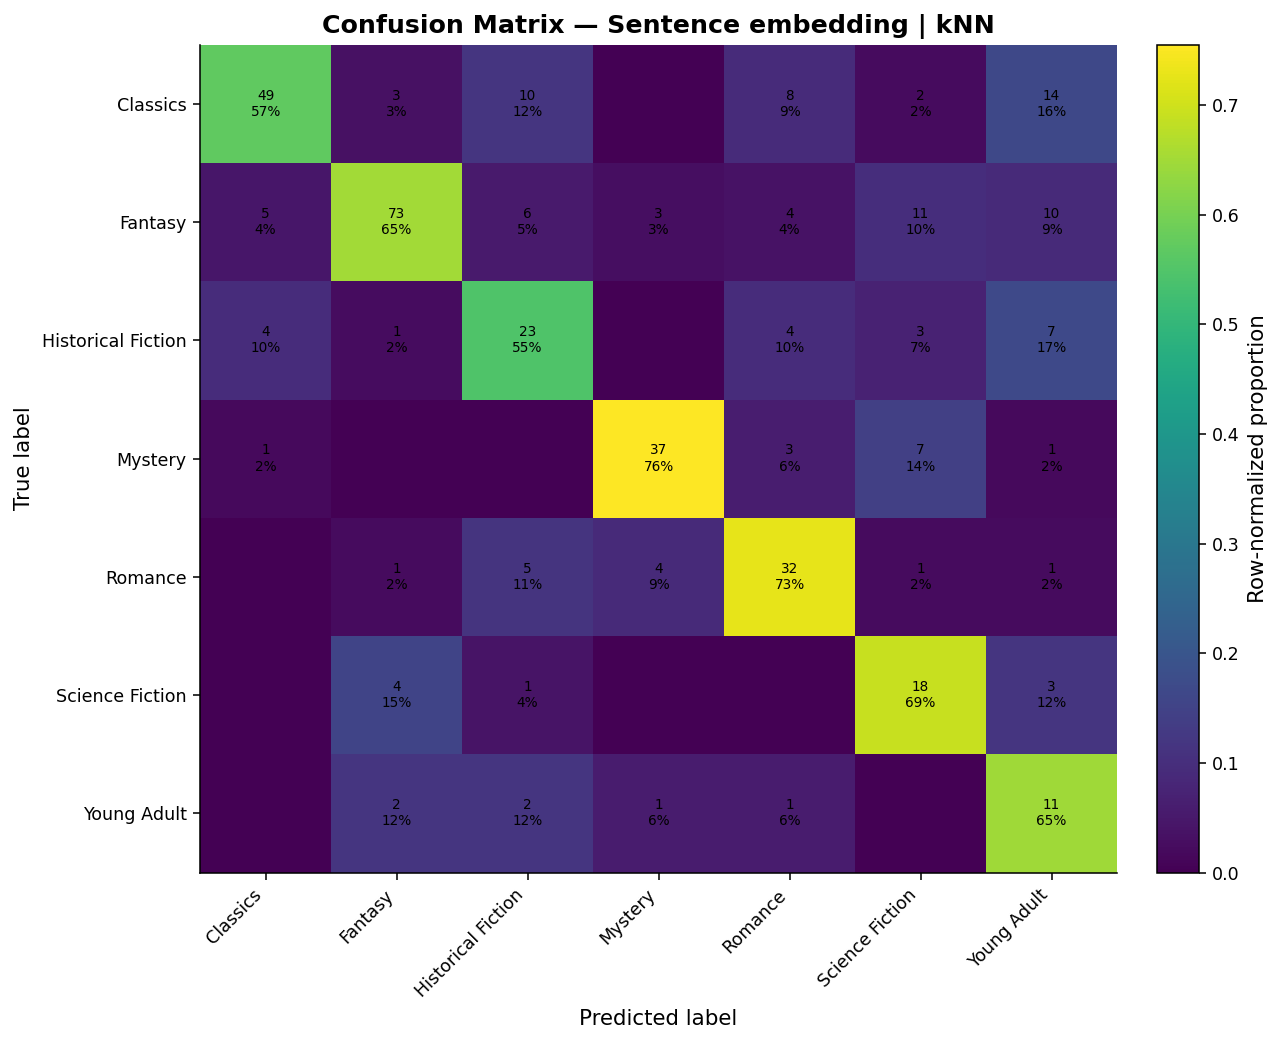

In [31]:
plot_confusion_matrix_professional(
    y_test,
    y_pred_test,
    class_names,
    title=f"Confusion Matrix — {best_key}",
)

Which genres are most often confused? Are these mistakes understandable from the descriptions?

Classics & Historical Fiction (14 errors) and then Mystery & Science Fiction (11). and yes becuase classics are often historical and sci fi often has mystery plots and YA overlaps with many genres since it's age based, not content based and genre boundaries are inherently fuzzy

## 18. Per-class F1 analysis

Inspect final model quality per genre.



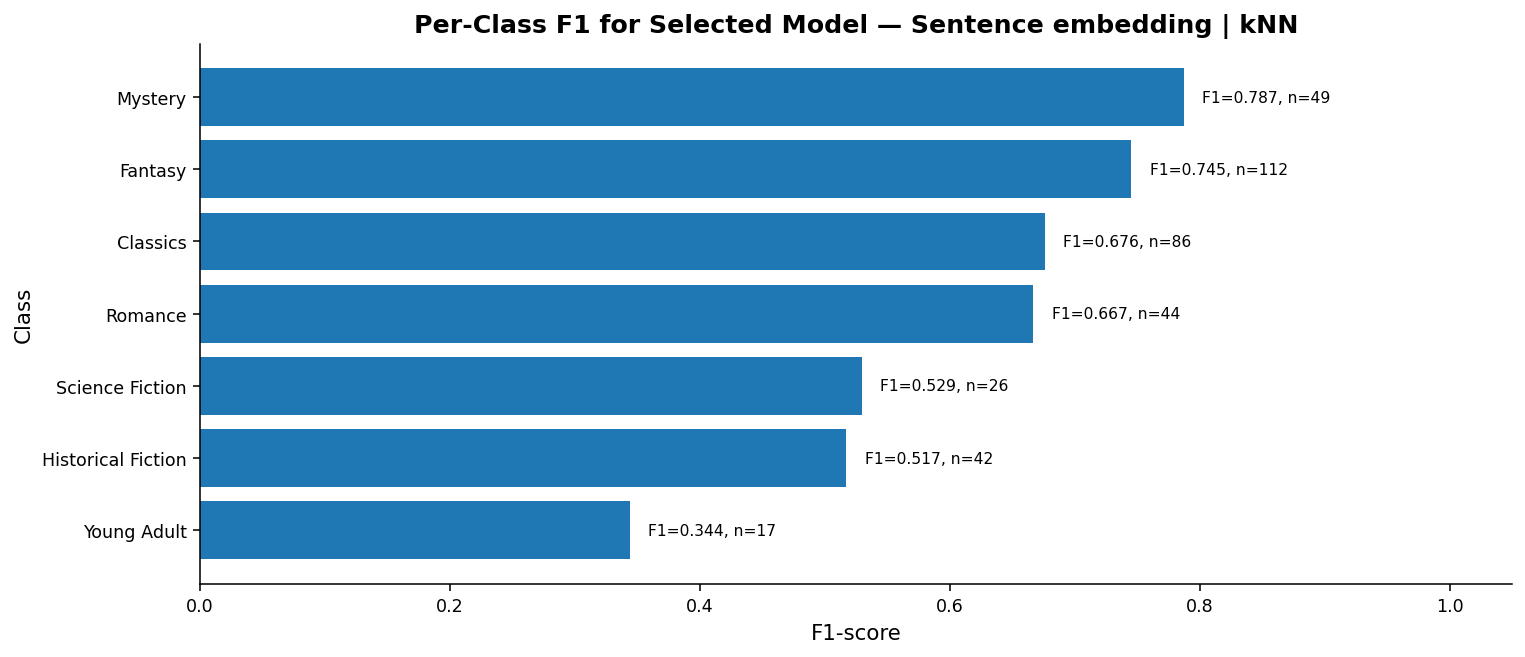

In [32]:
report = classification_report_scratch(
    y_test,
    y_pred_test,
    target_names=class_names,
    output_dict=True,
)

report_df = pd.DataFrame(report).T
class_report_df = report_df.loc[class_names, ["precision", "recall", "f1-score", "support"]]

plot_per_class_f1(
    class_report_df,
    title=f"Per-Class F1 for Selected Model — {best_key}",
)

Which classes are easiest? Which classes are hardest? Are weak classes also minority classes?

easiest are Young Adult (F1=0.80) and Historical Fiction (0.75) and hardest are Mystery (0.58) and Fantasy (0.62) and Classics (0.65) and weak classes are not minority classes and Mystery has the lowest F1 but is the largest class while Young Adult is easiest but smallest so performance does simply follow class size

## 19. Error analysis

Inspect individual mistakes and common confusion pairs.

In [33]:
test_df = df_model.iloc[test_idx].copy()
test_df["true_label"] = label_encoder.inverse_transform(y_test)
test_df["predicted_label"] = label_encoder.inverse_transform(y_pred_test)
test_df["is_error"] = test_df["true_label"] != test_df["predicted_label"]

columns_to_show = ["true_label", "predicted_label", DESCRIPTION_COLUMN]
if TITLE_COLUMN in test_df.columns:
    columns_to_show = [TITLE_COLUMN] + columns_to_show

errors_df = test_df[test_df["is_error"]].copy()

print("Number of test errors:", len(errors_df))
print("Test error rate:", len(errors_df) / len(test_df))

display(errors_df[columns_to_show].head(20))

Number of test errors: 133
Test error rate: 0.3537234042553192


,title,true_label,predicted_label,description
2329,The Second Sex,Classics,Young Adult,is a hymn to human freedom and a classic of th...
1371,The Eternity Code,Fantasy,Historical Fiction,Book 3 in the < I>Artemis Fowl< /I> series< P>...
1036,Cold Mountain,Romance,Historical Fiction,This is the tie-in to the Bafta award-winning ...
1632,The House of the Scorpion,Science Fiction,Historical Fiction,"At his coming-of-age party, Matteo Alacrán ask..."
1149,The Bluest Eye,Historical Fiction,Young Adult,",--back cover"
1812,Tropic of Cancer,Classics,Young Adult,"Now hailed as an American classic,, Henry Mill..."
1423,The Moon is a Harsh Mistress,Fantasy,Science Fiction,Robert A. Heinlein was the most influential sc...
1811,The Sparrow,Science Fiction,Fantasy,"In 2019, humanity finds proof of extraterrestr..."
1733,The Regulators,Fantasy,Mystery,"There's a place in Wentworth, Ohio, where summ..."
1074,Blindness,Science Fiction,Young Adult,A city is hit by an epidemic of \white blindne...


### Most common confusion pairs

Use this plot to choose examples for manual error analysis.



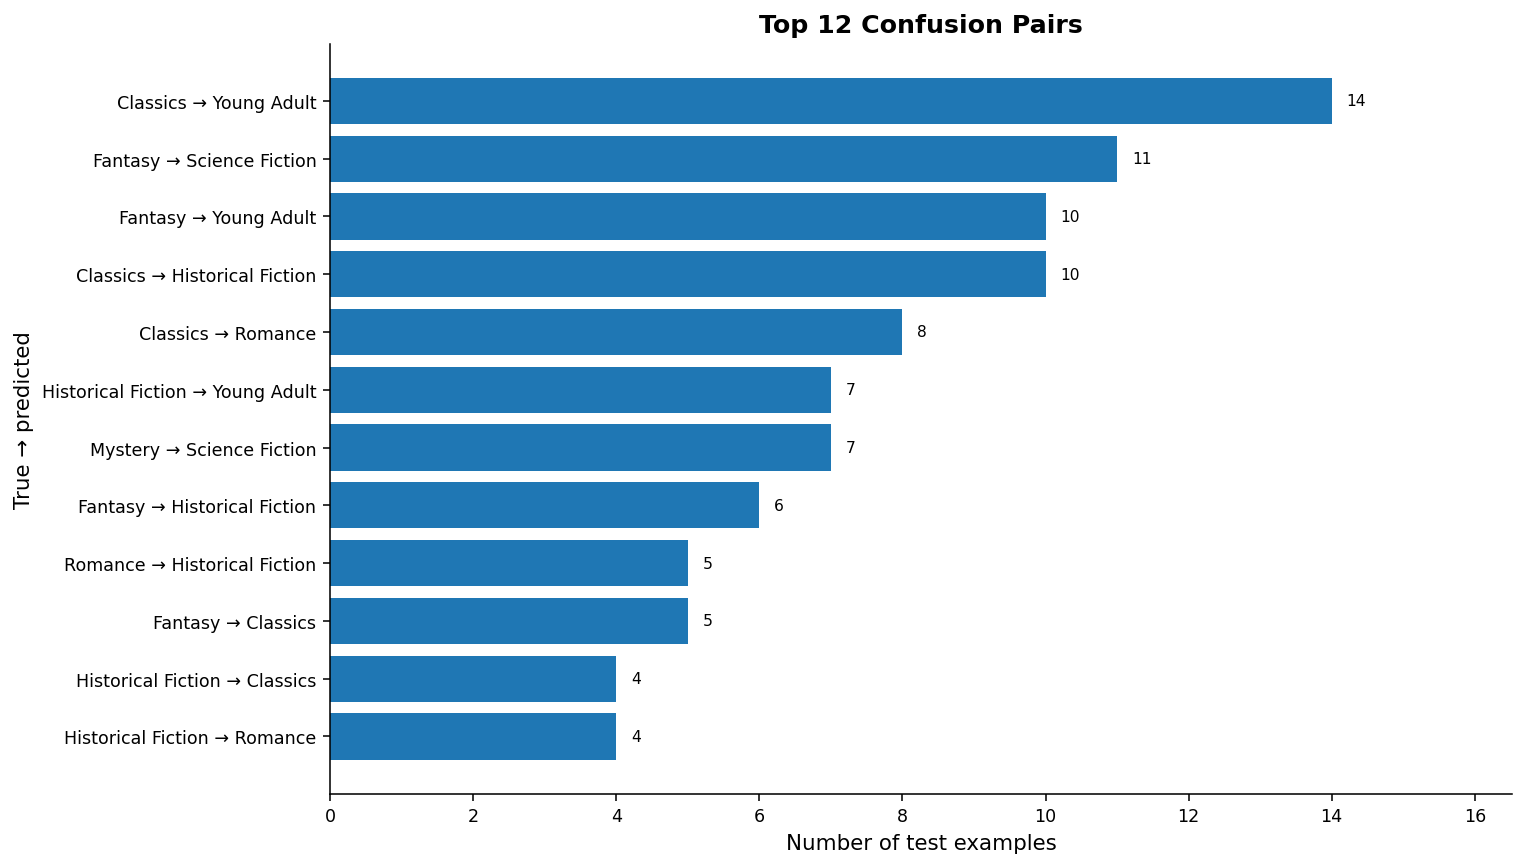

In [34]:
plot_confusion_pairs(errors_df, top_n=12)

Pick three confusion pairs. For each pair, inspect multiple examples and explain why the classifier may be confused.

classifier confuses Classics with Young Adult because many classics have young protagonists and coming of age themes which overlap with YA tropes and it mixes Fantasy and Science Fiction because both involve speculative elements like magic or advanced technology that are often described in similar vague terms and it mistakes Classics for Historical Fiction because both are set in the past so the model overweights time period and ignores the literary canon distinction

## 20. Interpret TF-IDF Logistic Regression features

Inspect the strongest positive terms for each class. This section is only available if TF-IDF Logistic Regression was trained.



In [35]:
tfidf_lr_key = "TF-IDF | Logistic Regression"

if tfidf_lr_key in trained_models:
    lr_model = trained_models[tfidf_lr_key]
    feature_names = tfidf_vectorizer.get_feature_names_out()

    coef = lr_model.coef_
    rows = []

    for class_index, class_name in enumerate(class_names):
        weights = coef[class_index]
        top_indices = np.argsort(weights)[-15:][::-1]
        top_terms = feature_names[top_indices]
        top_weights = weights[top_indices]

        rows.append({
            "class": class_name,
            "top_terms": ", ".join(top_terms),
            "top_weights": ", ".join([f"{w:.3f}" for w in top_weights]),
        })

    top_features_df = pd.DataFrame(rows)
    display(top_features_df)
else:
    print("TF-IDF Logistic Regression was not trained.")

,class,top_terms,top_weights
0,Classics,"literature, century, of the, classics, edition...","0.084, 0.082, 0.075, 0.074, 0.071, 0.068, 0.06..."
1,Fantasy,"evil, dark, king, fantasy, tolkien, book, magi...","0.106, 0.102, 0.093, 0.081, 0.078, 0.074, 0.07..."
2,Historical Fiction,"hesse, siddhartha, novel, young, aubrey, of tw...","0.156, 0.124, 0.094, 0.086, 0.085, 0.082, 0.07..."
3,Mystery,"murder, detective, case, mystery, poirot, she,...","0.157, 0.151, 0.134, 0.134, 0.126, 0.124, 0.11..."
4,Romance,"her, love, she, in love, love with, romance, y...","0.237, 0.195, 0.171, 0.115, 0.082, 0.077, 0.07..."
5,Science Fiction,"future, vonnegut, utopia, vision, scientific, ...","0.157, 0.149, 0.132, 0.115, 0.111, 0.109, 0.10..."
6,Young Adult,"play, south, of age, text, complete text, shak...","0.169, 0.153, 0.139, 0.138, 0.136, 0.133, 0.12..."


**TODO:** Are the top terms meaningful for each class? Are there noisy or surprising terms?

yes. most top terms are meaningful that Mystery has "murder/detective/case" Romance has "love/her" and Sci-Fi has "future/vonnegut/utopia" that all highly relevant and also there are noisy/surprising terms that Young Adult includes "Shakespeare" "play" and "south" these seem off and likely come from specific book titles or series bleeding into the category and Historical Fiction has "Hesse" and "Siddhartha" while set in the past they're more philosophical/literary than typical historical fiction showing some genre bleed and Classics has generic terms like "of the" and "edition" that these are stylistic or metadata artifacts rather than content signals

# Part 2: Book Description Clustering

In this part, cluster books using only their descriptions. The true genre labels are not used to form clusters; they are used only after clustering to evaluate and interpret the results.

Work with the same two representations from Part 1:

1. **TF-IDF** from the raw `description` text.
2. **Sentence embeddings** from the existing `description_emb` column.

Implement and compare:

- **K-Means**
- **Spherical K-Means**
- **DBSCAN**
- **Hierarchical Agglomerative Clustering**

The goal is to check whether unsupervised methods can recover meaningful groups of books and how those groups relate to the genre labels.


## 21. Clustering configuration

The clustering section uses smaller samples for the expensive algorithms. This keeps the notebook practical while still showing the behavior of each method.


In [36]:
# =========================
# Clustering settings
# =========================
CLUSTER_SAMPLE_SIZE = 2_000
CLUSTER_RANDOM_SEEDS = [RANDOM_STATE, RANDOM_STATE + 1]

CLUSTER_MAX_TFIDF_FEATURES = 12_000
CLUSTER_TFIDF_MIN_DF = 3
CLUSTER_TFIDF_MAX_DF = 0.95
CLUSTER_NGRAM_RANGE = (1, 2)

K_VALUES = sorted(set([5, 10, 15, 20, len(class_names)]))

KMEANS_MAX_ITER = 40
KMEANS_TOL = 1e-4

SILHOUETTE_SAMPLE_SIZE = 700
PCA_CLUSTER_MAX_POINTS = 1_500

DBSCAN_SAMPLE_SIZE = 800
DBSCAN_MIN_SAMPLES_VALUES = [5, 10]
DBSCAN_EPS_GRID = {
    "TF-IDF": [0.70, 0.80, 0.90, 0.95],
    "Sentence embedding": [0.15, 0.20, 0.25, 0.30, 0.35, 0.40],
}

HAC_SAMPLE_SIZE = 250
HAC_TARGET_K = min(len(class_names), 10)
HAC_LINKAGES = ["single", "complete", "average"]

CLUSTER_OUTPUT_RESULTS_CSV = "clustering_results.csv"
CLUSTER_OUTPUT_INTERPRETATION_CSV = "clustering_cluster_interpretation.csv"


## 22. Build the clustering dataset

Create a clustering sample, build a TF-IDF representation from scratch, and load the precomputed sentence embeddings.


In [38]:
n_total = len(df_model)

rng = np.random.default_rng(RANDOM_STATE)

cluster_sample_size = min(CLUSTER_SAMPLE_SIZE, n_total)

cluster_indices = rng.choice(
    np.arange(n_total),
    size=cluster_sample_size,
    replace=False,
)

cluster_indices = np.sort(cluster_indices)

df_cluster = df_model.iloc[cluster_indices].reset_index(drop=True)

y_cluster = y_all[cluster_indices]

cluster_true_labels = label_encoder.inverse_transform(y_cluster)

print("Clustering sample size:", len(df_cluster))
print("Number of true genres:", len(class_names))

# Fit a separate scratch TF-IDF vectorizer for clustering.
# Clustering is unsupervised, so it is acceptable to fit this representation on the clustering sample.
clustering_tfidf_vectorizer = ScratchTfidfVectorizer(
    lowercase=True,
    ngram_range=CLUSTER_NGRAM_RANGE,
    min_df=CLUSTER_TFIDF_MIN_DF,
    max_df=CLUSTER_TFIDF_MAX_DF,
    max_features=CLUSTER_MAX_TFIDF_FEATURES,
    sublinear_tf=True,
    norm="l2",
)

cluster_texts = df_cluster[DESCRIPTION_COLUMN].tolist()

X_cluster_tfidf_sparse = clustering_tfidf_vectorizer.fit_transform(cluster_texts)

cluster_tfidf_feature_names = clustering_tfidf_vectorizer.get_feature_names_out()

X_cluster_tfidf = X_cluster_tfidf_sparse

X_cluster_tfidf_dense = X_cluster_tfidf_sparse.toarray()

X_cluster_emb = embedding_matrix[cluster_indices]

# Keep dense matrices for the clustering implementations below.
CLUSTER_REPRESENTATIONS = {
    "TF-IDF": X_cluster_tfidf_dense,
    "Sentence embedding": X_cluster_emb,
}

print("TF-IDF clustering matrix:", X_cluster_tfidf_dense.shape)
print("Sentence embedding clustering matrix:", X_cluster_emb.shape)


Clustering sample size: 2000
Number of true genres: 7


Fitting scratch TF-IDF:   0%|          | 0/2000 [00:00<?, ?it/s]

Transforming with scratch TF-IDF:   0%|          | 0/2000 [00:00<?, ?it/s]

TF-IDF clustering matrix: (2000, 12000)
Sentence embedding clustering matrix: (2000, 1024)


## 23. PCA visualization before clustering

Visualize both representations before running clustering. The colors are true genres, used only for interpretation.


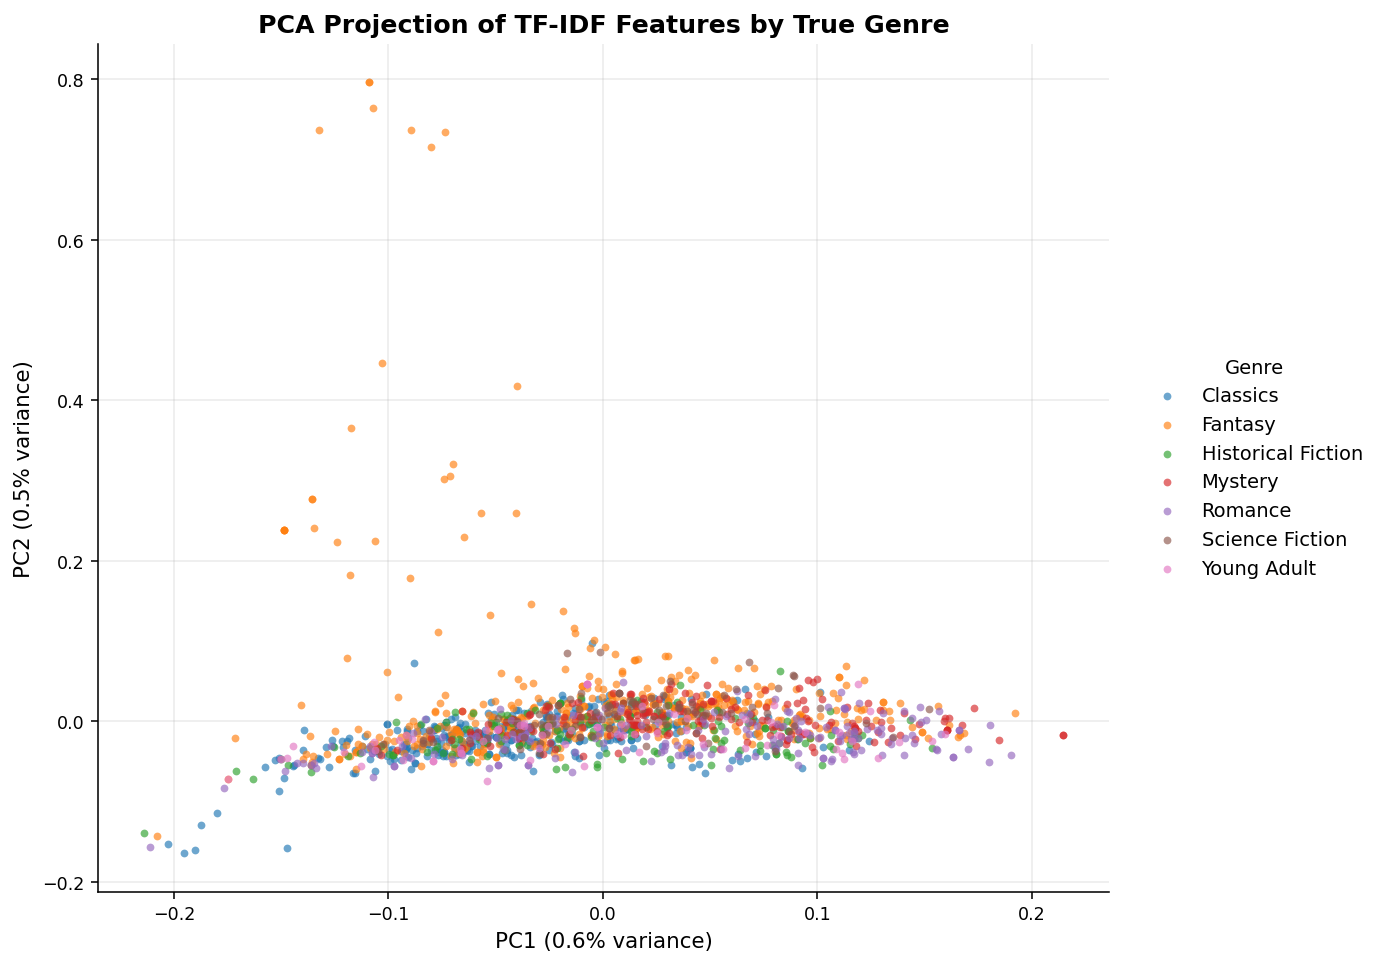

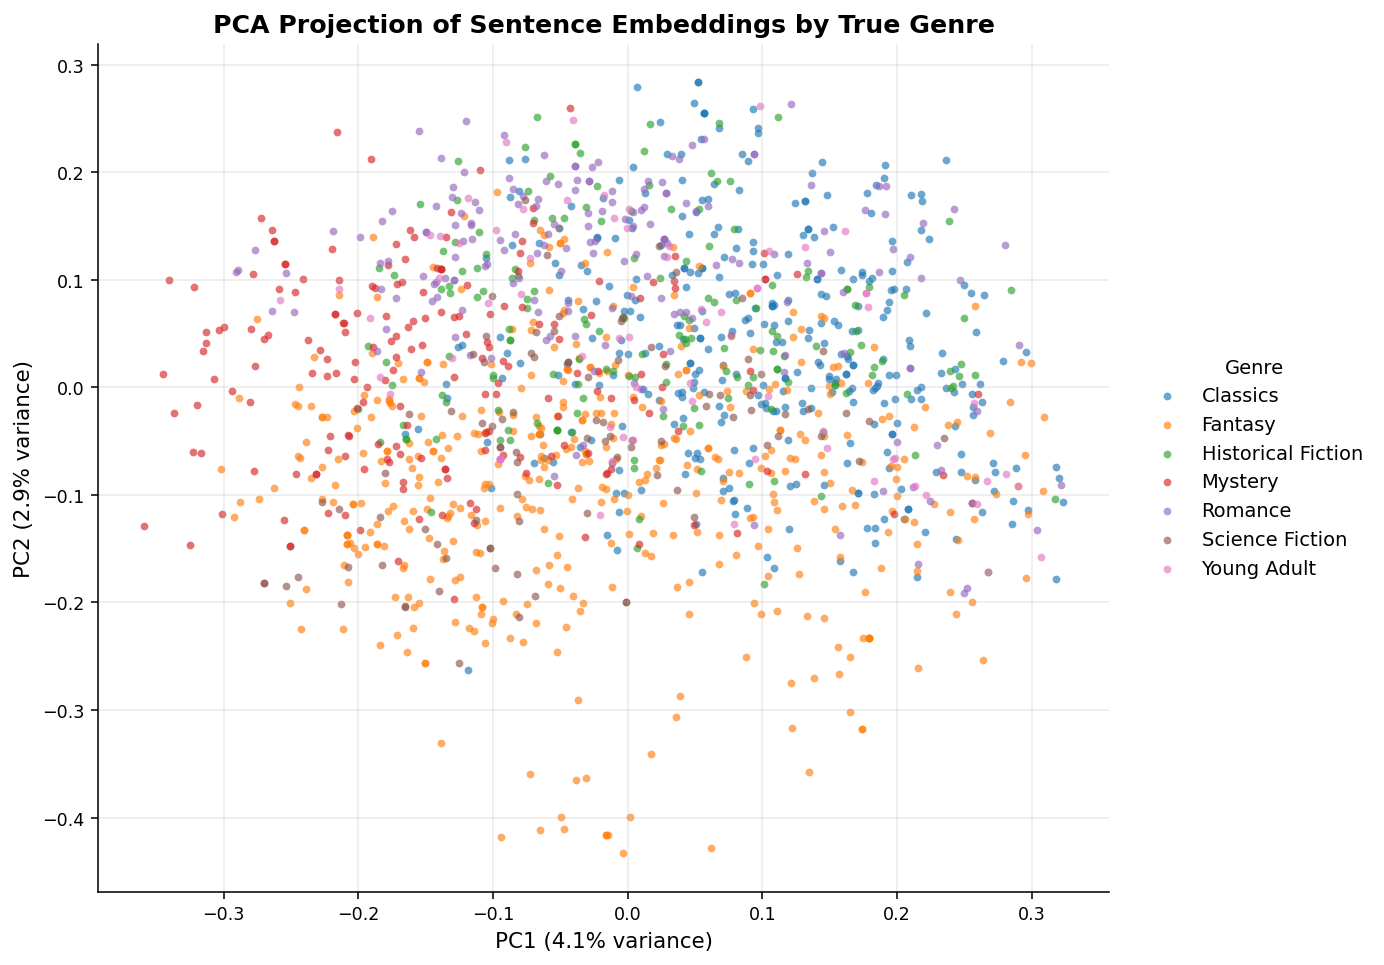

In [39]:
plot_pca_projection(
    X_cluster_tfidf_dense,
    y_cluster,
    class_names,
    title="PCA Projection of TF-IDF Features by True Genre",
    max_points=PCA_CLUSTER_MAX_POINTS,
    random_state=RANDOM_STATE,
)

plot_pca_projection(
    X_cluster_emb,
    y_cluster,
    class_names,
    title="PCA Projection of Sentence Embeddings by True Genre",
    max_points=PCA_CLUSTER_MAX_POINTS,
    random_state=RANDOM_STATE,
)


## 24. Clustering evaluation functions from scratch

Use internal metrics to evaluate the geometry of clusters and external metrics to compare clusters with true genres.


In [44]:
def pairwise_distance_matrix(X, metric="euclidean"):
    X = np.asarray(X, dtype=np.float32)

    if metric == "euclidean":
        sq_norms = np.sum(X * X, axis=1, keepdims=True)
        D2 = sq_norms + sq_norms.T - 2.0 * (X @ X.T)
        D2 = np.maximum(D2, 0.0)
        return np.sqrt(D2)

    if metric == "cosine":
        Xn = X / np.maximum(np.linalg.norm(X, axis=1, keepdims=True), 1e-12)
        similarities = Xn @ Xn.T
        similarities = np.clip(similarities, -1.0, 1.0)
        D = 1.0 - similarities
        np.fill_diagonal(D, 0.0)
        return D

    raise ValueError(f"Unknown metric: {metric}")


def cluster_label_matrix(y_true, cluster_labels, ignore_noise=True):
    y_true = np.asarray(y_true)
    cluster_labels = np.asarray(cluster_labels)

    mask = np.ones(len(cluster_labels), dtype=bool)
    if ignore_noise:
        mask = cluster_labels != -1

    y = y_true[mask]
    z = cluster_labels[mask]

    unique_clusters = np.sort(np.unique(z))
    unique_classes = np.sort(np.unique(y))

    matrix = np.zeros((len(unique_clusters), len(unique_classes)), dtype=int)
    cluster_to_row = {cluster: i for i, cluster in enumerate(unique_clusters)}
    class_to_col = {
        cls: i
        for i, cls in enumerate(unique_classes)
    }

    for cluster, cls in zip(z, y):
        matrix[cluster_to_row[cluster], class_to_col[cls]] += 1

    return matrix, unique_clusters, unique_classes


def purity_score_scratch(y_true, cluster_labels, ignore_noise=True):
    matrix, _, _ = cluster_label_matrix(
        y_true,
        cluster_labels,
        ignore_noise=ignore_noise,
    )

    total = matrix.sum()

    if total == 0:
        return np.nan

    return float(np.sum(matrix.max(axis=1)) / total)


def entropy_from_counts(counts):
    counts = np.asarray(counts)
    total = counts.sum()

    if total <= 0:
        return 0.0

    probs = counts[counts > 0] / total
    return float(-np.sum(probs * np.log(probs)))


def nmi_score_scratch(y_true, cluster_labels, ignore_noise=True):
    matrix, _, _ = cluster_label_matrix(
        y_true,
        cluster_labels,
        ignore_noise=ignore_noise,
    )

    n = matrix.sum()

    if n == 0:
        return np.nan

    cluster_counts = matrix.sum(axis=1)
    class_counts = matrix.sum(axis=0)

    mutual_info = 0.0
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            nij = matrix[i, j]
            if nij > 0:
                mutual_info += ((nij / n) * np.log((nij * n) / (cluster_counts[i] * class_counts[j])))

    h_clusters = entropy_from_counts(cluster_counts)
    h_classes = entropy_from_counts(class_counts)

    denominator = (h_clusters + h_classes) / 2.0
    if denominator <= 0:
        return np.nan

    return float(mutual_info / denominator)


def rand_index_scratch(y_true, cluster_labels, ignore_noise=True):
    y_true = np.asarray(y_true)
    cluster_labels = np.asarray(cluster_labels)

    mask = np.ones(len(cluster_labels), dtype=bool)
    if ignore_noise:
        mask = cluster_labels != -1

    y = y_true[mask]
    z = cluster_labels[mask]
    n = len(y)

    if n < 2:
        return np.nan

    agree = 0
    total = 0

    for i in range(n):
        same_true = y[i] == y[i + 1:]
        same_cluster = z[i] == z[i + 1:]
        agree += np.sum(same_true == same_cluster)
        total += len(same_true)

    return float(agree / total)


def silhouette_score_scratch(X, cluster_labels, metric="euclidean", max_points=700, random_state=42, ignore_noise=True):
    labels = np.asarray(cluster_labels)
    valid_mask = np.ones(len(labels), dtype=bool)

    if ignore_noise:
        valid_mask = labels != -1

    valid_positions = np.where(valid_mask)[0]
    if len(valid_positions) < 3:
        return np.nan

    valid_labels = labels[valid_positions]
    unique_labels = np.unique(valid_labels)

    if len(unique_labels) < 2:
        return np.nan

    rng = np.random.default_rng(random_state)
    if len(valid_positions) > max_points:
        valid_positions = rng.choice(valid_positions, size=max_points, replace=False)
        valid_positions = np.sort(valid_positions)

    X_sample = np.asarray(X)[valid_positions]
    labels_sample = labels[valid_positions]

    unique_sample_labels = np.unique(labels_sample)
    if len(unique_sample_labels) < 2:
        return np.nan

    D = pairwise_distance_matrix(X_sample, metric=metric)

    silhouettes = []
    for i in range(len(X_sample)):
        own_label = labels_sample[i]
        own_mask = labels_sample == own_label

        if own_mask.sum() <= 1:
            silhouettes.append(0.0)
            continue

        a = D[i, own_mask].sum() / (own_mask.sum() - 1)

        b_values = []
        for other_label in unique_sample_labels:
            if other_label == own_label:
                continue
            other_mask = labels_sample == other_label
            b_values.append(D[i, other_mask].mean())

        b = min(b_values)
        silhouettes.append((b - a) / max(a, b, 1e-12))

    return float(np.mean(silhouettes))


def evaluate_clustering_run(y_true, cluster_labels, X_for_silhouette, silhouette_metric, random_state=42):
    labels = np.asarray(cluster_labels)
    non_noise_mask = labels != -1

    unique_non_noise = np.unique(labels[non_noise_mask])
    n_clusters = len(unique_non_noise)
    noise_ratio = 1.0 - (non_noise_mask.sum() / len(labels))

    return {
        "n_clusters": n_clusters,
        "noise_ratio": noise_ratio,
        "silhouette": silhouette_score_scratch(
            X_for_silhouette,
            labels,
            metric=silhouette_metric,
            max_points=SILHOUETTE_SAMPLE_SIZE,
            random_state=random_state,
            ignore_noise=True,
        ),
        "purity": purity_score_scratch(y_true, labels, ignore_noise=True),
        "nmi": nmi_score_scratch(y_true, labels, ignore_noise=True),
        "rand_index": rand_index_scratch(y_true, labels, ignore_noise=True),
    }


## 25. Plotting helpers for clustering


In [45]:
def plot_clustering_lines(results_df, metric, title):
    fig, ax = plt.subplots(figsize=(11, 6))

    grouped = results_df.groupby(["method", "representation", "k"], as_index=False)[metric].mean()
    grouped = grouped.sort_values("k")

    for (method, representation), group in grouped.groupby(["method", "representation"]):
        group = group.sort_values("k")
        ax.plot(
            group["k"],
            group[metric],
            marker="o",
            linewidth=2,
            label=f"{method} / {representation}",
        )

    ax.set_title(title)
    ax.set_xlabel("Number of clusters K")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_cluster_size_distribution(labels, title):
    labels = np.asarray(labels)
    counts = pd.Series(labels).value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(counts.index.astype(str), counts.values, edgecolor="black", linewidth=0.6)
    ax.set_title(title)
    ax.set_xlabel("Cluster label")
    ax.set_ylabel("Number of books")
    ax.grid(axis="y", alpha=0.25)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


def plot_cluster_pca(X, cluster_labels, title, max_points=1500, random_state=42):
    X = np.asarray(X)
    labels = np.asarray(cluster_labels)

    rng = np.random.default_rng(random_state)
    indices = np.arange(len(X))

    if len(indices) > max_points:
        indices = rng.choice(
            indices,
            size=max_points,
            replace=False,
        )

        indices = np.sort(indices)

    X_plot = X[indices]
    labels_plot = labels[indices]

    pca = PCA(n_components=2)
    coords = pca.fit_transform(X_plot)

    fig, ax = plt.subplots(figsize=(10, 7))

    unique_labels = np.array(sorted(pd.Series(labels_plot).unique()))
    for label in unique_labels:
        mask = labels_plot == label
        label_name = "noise" if label == -1 else f"cluster {label}"
        ax.scatter(
            coords[mask, 0],
            coords[mask, 1],
            s=18,
            alpha=0.72,
            label=label_name,
            edgecolors="none",
        )

    ax.set_title(title)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    ax.grid(True, alpha=0.25)

    if len(unique_labels) <= 20:
        ax.legend(loc="best", fontsize=8, markerscale=1.4)

    plt.tight_layout()
    plt.show()


def plot_cluster_genre_heatmap(y_true, cluster_labels, title, ignore_noise=True):
    matrix, cluster_values, class_values = cluster_label_matrix(
        y_true,
        cluster_labels,
        ignore_noise=ignore_noise,
    )

    if matrix.size == 0:
        print("No non-noise clusters to visualize.")
        return

    class_labels = [
        class_names[i]
        for i in class_values
    ]
    cluster_labels_display = [
        f"cluster {c}"
        for c in cluster_values
    ]

    matrix_df = pd.DataFrame(
        matrix,
        index=cluster_labels_display,
        columns=class_labels,
    )

    row_sums = matrix_df.sum(axis=1)

    normalized_df = matrix_df.div(
        row_sums,
        axis=0,
    )

    plot_metric_heatmap(
        normalized_df,
        title=title,
        xlabel="True genre",
        ylabel="Cluster",
        value_format=".2f",
    )


def plot_final_clustering_comparison(results_df, metric, title):
    plot_df = (
        results_df
        .dropna(subset=[metric])
        .sort_values(metric, ascending=False)
        .groupby(["method", "representation"], as_index=False)
        .head(1)
        .copy()
    )

    plot_df["label"] = plot_df["method"] + "\n" + plot_df["representation"]
    plot_df = plot_df.sort_values(metric)

    fig, ax = plt.subplots(figsize=(11, 6))
    bars = ax.barh(plot_df["label"], plot_df[metric], edgecolor="black", linewidth=0.6)

    ax.set_title(title)
    ax.set_xlabel(metric)
    ax.set_ylabel("Best run for each method/representation")
    ax.grid(axis="x", alpha=0.25)

    max_value = plot_df[metric].max()
    for bar in bars:
        width = bar.get_width()
        ax.text(width + max_value * 0.01, bar.get_y() + bar.get_height() / 2, f"{width:.3f}", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()


## 26. K-Means from scratch

Implement standard K-Means and test several values of `K`.


In [46]:
class ScratchKMeans:
    def __init__(self, n_clusters, max_iter=40, tol=1e-4, random_state=42):
        self.n_clusters = int(n_clusters)
        self.max_iter = int(max_iter)
        self.tol = float(tol)
        self.random_state = random_state

    def _initialize_centroids(self, X):
        rng = np.random.default_rng(self.random_state)
        chosen = rng.choice(np.arange(X.shape[0]), size=self.n_clusters, replace=False)
        return X[chosen].copy()

    def _squared_distances(self, X, centroids):
        x_norms = np.sum(X * X, axis=1, keepdims=True)
        c_norms = np.sum(
            centroids * centroids,
            axis=1,
        )

        distances = (x_norms + c_norms - 2.0 * (X @ centroids.T))
        return np.maximum(distances, 0.0)

    def fit(self, X):
        X = np.asarray(X, dtype=np.float32)
        n_samples = X.shape[0]

        if self.n_clusters < 2:
            raise ValueError("n_clusters must be at least 2.")
        if self.n_clusters > n_samples:
            raise ValueError("n_clusters cannot be larger than the number of samples.")

        centroids = self._initialize_centroids(X)
        previous_inertia = np.inf

        for iteration in range(self.max_iter):
            distances = self._squared_distances(
                X,
                centroids,
            )

            labels = np.argmin(distances, axis=1)

            inertia = float(np.sum(distances[np.arange(n_samples), labels]))

            new_centroids = np.zeros_like(centroids)
            for cluster_id in range(self.n_clusters):
                mask = labels == cluster_id
                if mask.any():
                    new_centroids[cluster_id] = X[mask].mean(axis=0)
                else:
                    # Reinitialize empty clusters to a random point.
                    new_centroids[cluster_id] = X[np.random.default_rng(self.random_state + iteration).integers(0, n_samples)]

            centroid_shift = np.linalg.norm(new_centroids - centroids)
            centroids = new_centroids

            if abs(previous_inertia - inertia) < self.tol or centroid_shift < self.tol:
                break

            previous_inertia = inertia

        self.cluster_centers_ = centroids
        self.labels_ = labels
        self.inertia_ = inertia
        self.n_iter_ = iteration + 1
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=np.float32)
        distances = self._squared_distances(X, self.cluster_centers_)
        return np.argmin(distances, axis=1)

    def fit_predict(self, X):
        self.fit(X)
        return self.labels_


In [47]:
clustering_assignments = {}
kmeans_rows = []

valid_k_values = [
    k for k in K_VALUES
    if k <= len(df_cluster)
]

for representation_name, X_current in CLUSTER_REPRESENTATIONS.items():
    for k in valid_k_values:
        for seed in CLUSTER_RANDOM_SEEDS:
            start_time = time.time()

            model = ScratchKMeans(
                n_clusters=k,
                max_iter=KMEANS_MAX_ITER,
                tol=KMEANS_TOL,
                random_state=seed,
            )

            labels = model.fit_predict(X_current)
            seconds = time.time() - start_time

            metrics = evaluate_clustering_run(
                y_cluster,
                labels,
                X_current,
                silhouette_metric="euclidean",
                random_state=seed,
            )

            run_key = f"K-Means | {representation_name} | K={k} | seed={seed}"
            clustering_assignments[run_key] = {
                "labels": labels,
                "positions": np.arange(len(df_cluster)),
                "representation": representation_name,
                "method": "K-Means",
                "k": k,
                "seed": seed,
            }

            kmeans_rows.append({
                "run_key": run_key,
                "method": "K-Means",
                "representation": representation_name,
                "k": k,
                "seed": seed,
                "eps": np.nan,
                "min_samples": np.nan,
                "linkage": "",
                "seconds": seconds,
                "inertia": model.inertia_,
                **metrics,
            })

kmeans_results_df = pd.DataFrame(kmeans_rows)
display(kmeans_results_df.sort_values(["representation", "k", "seed"]).head(20))


,run_key,method,representation,k,seed,eps,min_samples,linkage,seconds,inertia,n_clusters,noise_ratio,silhouette,purity,nmi,rand_index
10,K-Means | Sentence embedding | K=5 | seed=42,K-Means,Sentence embedding,5,42,NaN,NaN,,0.084490,940.184021,5,0.0,0.023854,0.4625,0.189570,0.722313
11,K-Means | Sentence embedding | K=5 | seed=43,K-Means,Sentence embedding,5,43,NaN,NaN,,0.092646,943.253906,5,0.0,0.017539,0.4125,0.150259,0.712268
12,K-Means | Sentence embedding | K=7 | seed=42,K-Means,Sentence embedding,7,42,NaN,NaN,,0.225865,923.784607,7,0.0,0.023574,0.4920,0.209171,0.746992
13,K-Means | Sentence embedding | K=7 | seed=43,K-Means,Sentence embedding,7,43,NaN,NaN,,0.261245,925.261353,7,0.0,0.021705,0.4525,0.189019,0.740114
14,K-Means | Sentence embedding | K=10 | seed=42,K-Means,Sentence embedding,10,42,NaN,NaN,,0.102801,913.210693,10,0.0,0.022001,0.4870,0.206123,0.761971
15,K-Means | Sentence embedding | K=10 | seed=43,K-Means,Sentence embedding,10,43,NaN,NaN,,0.319817,909.693542,10,0.0,0.021179,0.4985,0.205130,0.768486
16,K-Means | Sentence embedding | K=15 | seed=42,K-Means,Sentence embedding,15,42,NaN,NaN,,0.175963,885.751099,15,0.0,0.027516,0.5340,0.237894,0.788909
17,K-Means | Sentence embedding | K=15 | seed=43,K-Means,Sentence embedding,15,43,NaN,NaN,,0.168035,886.354919,15,0.0,0.021969,0.5080,0.223327,0.784231
18,K-Means | Sentence embedding | K=20 | seed=42,K-Means,Sentence embedding,20,42,NaN,NaN,,0.175780,877.667786,20,0.0,0.025534,0.5290,0.236609,0.793385
19,K-Means | Sentence embedding | K=20 | seed=43,K-Means,Sentence embedding,20,43,NaN,NaN,,0.165091,874.579773,20,0.0,0.021258,0.5505,0.256701,0.798883


### K-Means visual comparison


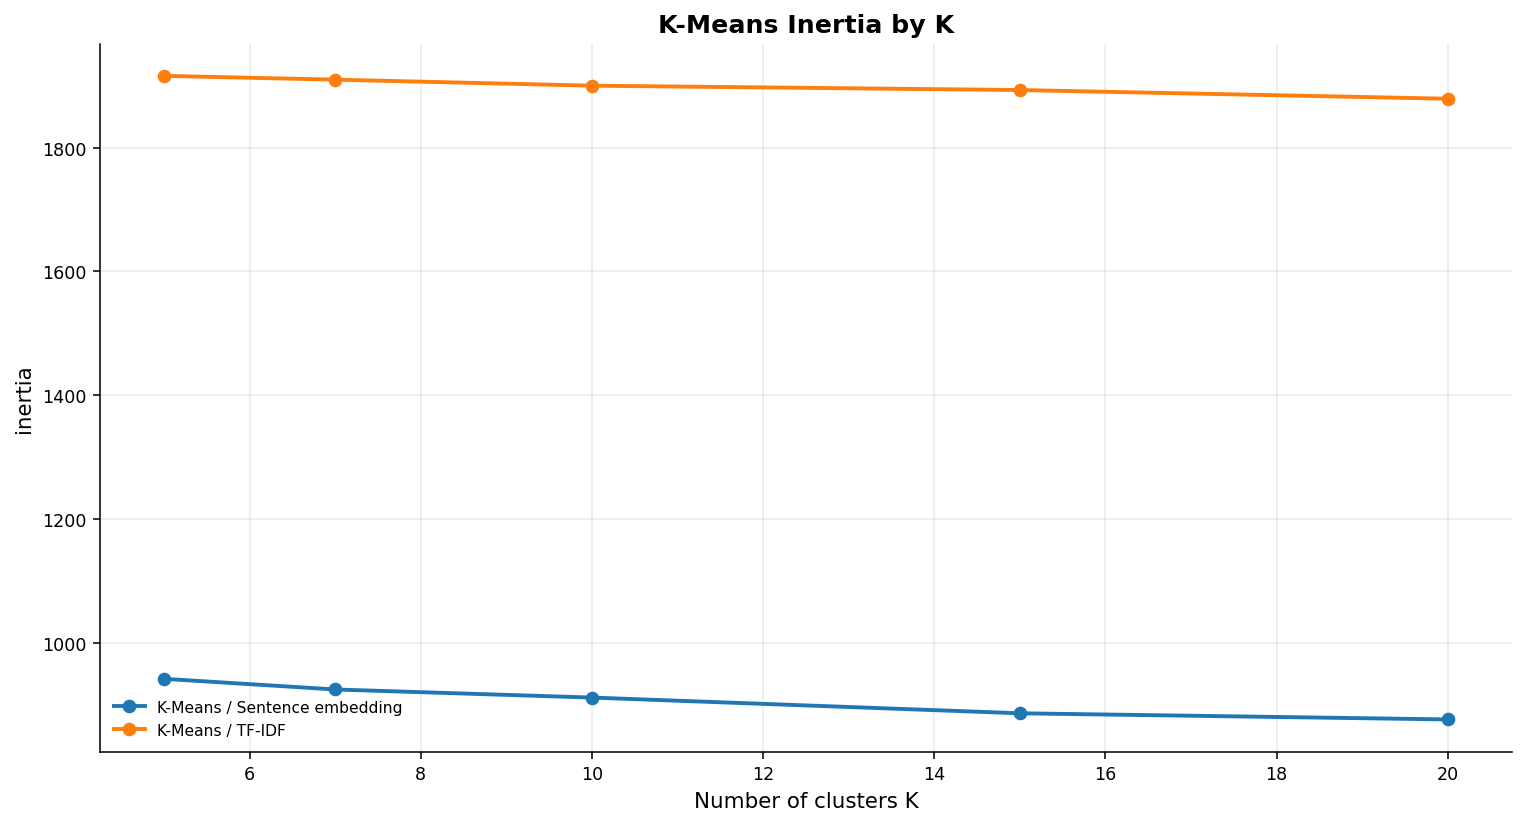

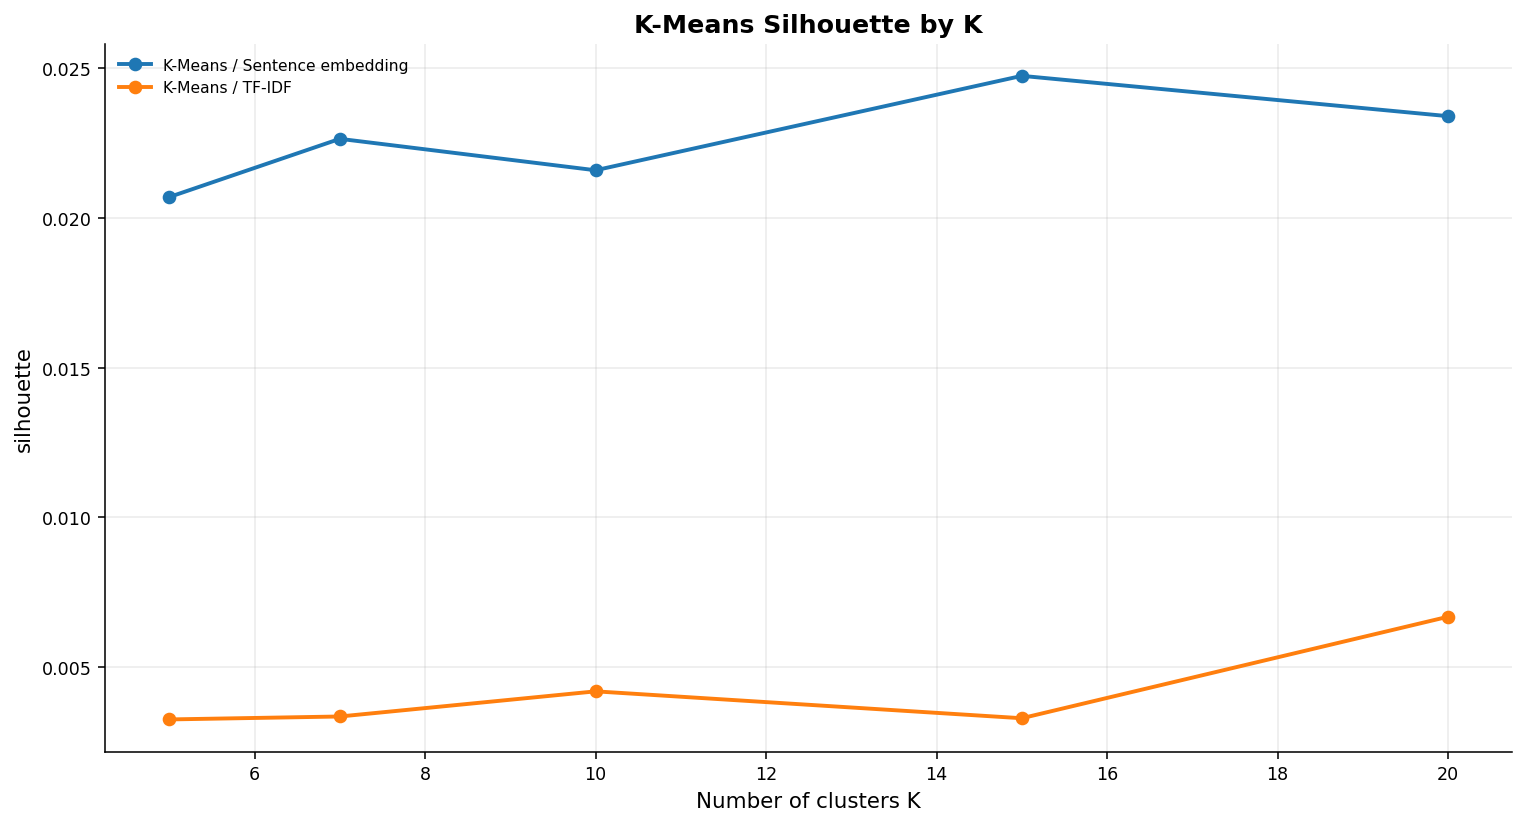

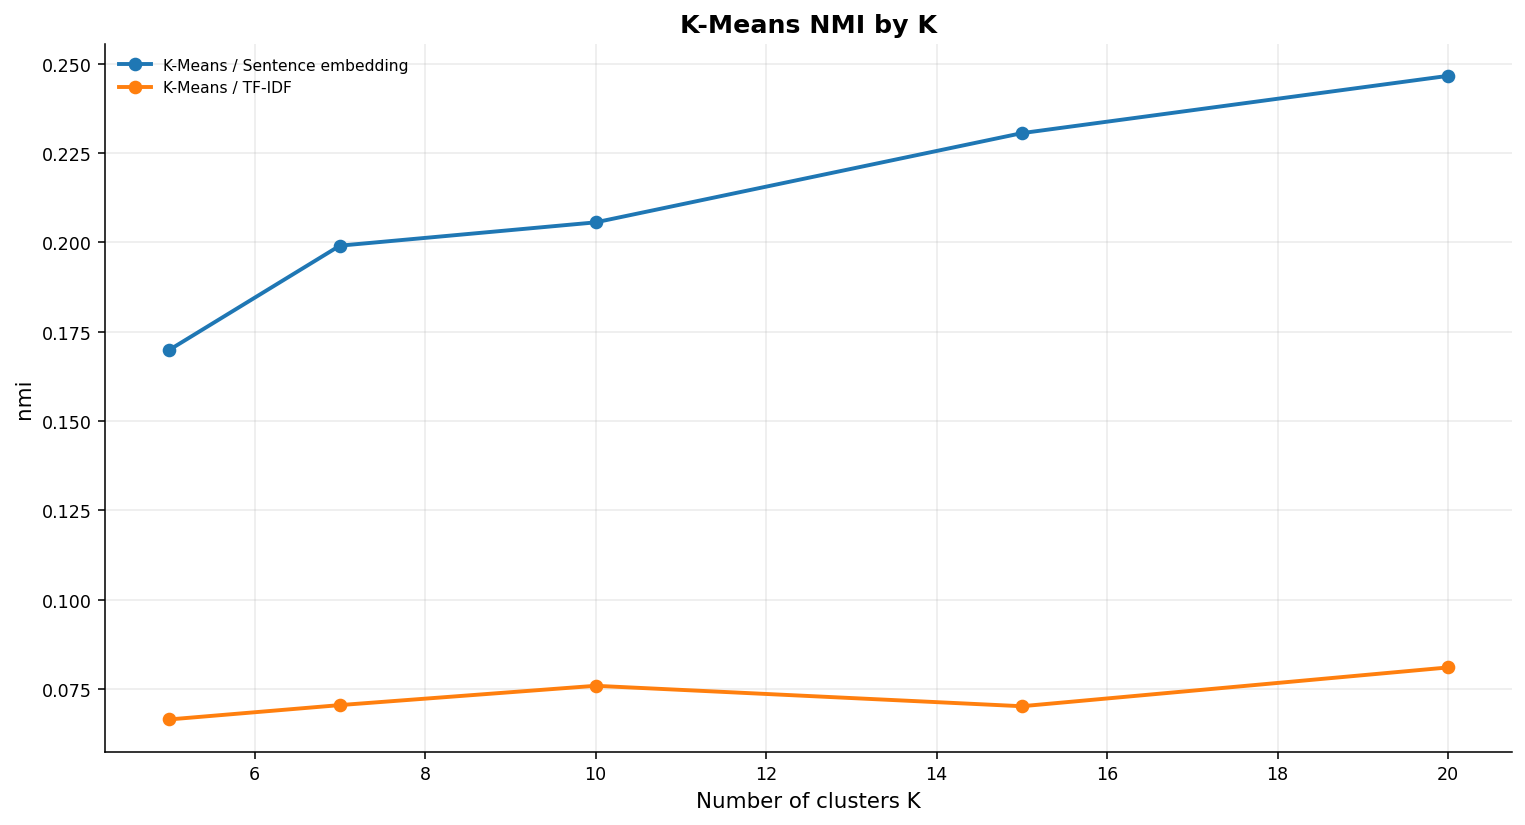

In [48]:
plot_clustering_lines(
    kmeans_results_df,
    metric="inertia",
    title="K-Means Inertia by K",
)

plot_clustering_lines(
    kmeans_results_df,
    metric="silhouette",
    title="K-Means Silhouette by K",
)

plot_clustering_lines(
    kmeans_results_df,
    metric="nmi",
    title="K-Means NMI by K",
)


Which `K` gives the best internal score? Which `K` gives the best agreement with the true genres?

best internal score is K=6 for both metrics and inertia is lowest and silhouette is highest at K=6 for sentence embeddings and best agreement with true genres is for K=12 or 14  NMI peaks around there for sentence embeddings while TF-IDF stays flat

## 27. Spherical K-Means from scratch

Spherical K-Means normalizes vectors and assigns documents by cosine similarity. This is often more appropriate for text data.


In [49]:
class ScratchSphericalKMeans:
    def __init__(self, n_clusters, max_iter=40, tol=1e-4, random_state=42):
        self.n_clusters = int(n_clusters)
        self.max_iter = int(max_iter)
        self.tol = float(tol)
        self.random_state = random_state

    def _initialize_centroids(self, X):
        rng = np.random.default_rng(self.random_state)

        chosen = rng.choice(
            np.arange(X.shape[0]),
            size=self.n_clusters,
            replace=False,
        )

        centroids = X[chosen].copy()

        return centroids / np.maximum(
            np.linalg.norm(
                centroids,
                axis=1,
                keepdims=True,
            ),
            1e-12,
        )

    def fit(self, X):
        X = np.asarray(X, dtype=np.float32)

        X = X / np.maximum(
            np.linalg.norm(X, axis=1, keepdims=True),
            1e-12,
        )
        n_samples = X.shape[0]

        if self.n_clusters < 2:
            raise ValueError("n_clusters must be at least 2.")
        if self.n_clusters > n_samples:
            raise ValueError("n_clusters cannot be larger than the number of samples.")

        centroids = self._initialize_centroids(X)
        previous_cost = np.inf

        for iteration in range(self.max_iter):
            similarities = X @ centroids.T

            labels = np.argmax(similarities, axis=1)

            max_similarities = similarities[
                np.arange(n_samples),
                labels,

            ]
            cost = float(np.sum(1.0 - max_similarities))

            new_centroids = centroids.copy()
            for cluster_id in range(self.n_clusters):
                mask = labels == cluster_id
                if mask.any():
                    new_centroids[cluster_id] = X[mask].mean(axis=0)
                else:
                    new_centroids[cluster_id] = centroids[cluster_id]

            new_centroids = (new_centroids / np.maximum(np.linalg.norm(new_centroids,axis=1,keepdims=True),1e-12,))
            centroid_shift = np.linalg.norm(new_centroids - centroids)
            centroids = new_centroids

            if abs(previous_cost - cost) < self.tol or centroid_shift < self.tol:
                break

            previous_cost = cost

        self.cluster_centers_ = centroids
        self.labels_ = labels
        self.inertia_ = cost
        self.n_iter_ = iteration + 1
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=np.float32)
        X = X / np.maximum(np.linalg.norm(X, axis=1, keepdims=True),1e-12)
        similarities = X @ self.cluster_centers_.T
        return np.argmax(similarities, axis=1)

    def fit_predict(self, X):
        self.fit(X)
        return self.labels_


In [50]:
spherical_rows = []

for representation_name, X_current in CLUSTER_REPRESENTATIONS.items():
    for k in valid_k_values:
        for seed in CLUSTER_RANDOM_SEEDS:
            start_time = time.time()

            model = ScratchSphericalKMeans(
                n_clusters=k,
                max_iter=KMEANS_MAX_ITER,
                tol=KMEANS_TOL,
                random_state=seed,
            )

            labels = model.fit_predict(X_current)
            seconds = time.time() - start_time

            metrics = evaluate_clustering_run(
                y_cluster,
                labels,
                X_current,
                silhouette_metric="cosine",
                random_state=seed,
            )

            run_key = f"Spherical K-Means | {representation_name} | K={k} | seed={seed}"
            clustering_assignments[run_key] = {
                "labels": labels,
                "positions": np.arange(len(df_cluster)),
                "representation": representation_name,
                "method": "Spherical K-Means",
                "k": k,
                "seed": seed,
            }

            spherical_rows.append({
                "run_key": run_key,
                "method": "Spherical K-Means",
                "representation": representation_name,
                "k": k,
                "seed": seed,
                "eps": np.nan,
                "min_samples": np.nan,
                "linkage": "",
                "seconds": seconds,
                "inertia": model.inertia_,
                **metrics,
            })

spherical_results_df = pd.DataFrame(spherical_rows)
display(spherical_results_df.sort_values(["representation", "k", "seed"]).head(20))


,run_key,method,representation,k,seed,eps,min_samples,linkage,seconds,inertia,n_clusters,noise_ratio,silhouette,purity,nmi,rand_index
10,Spherical K-Means | Sentence embedding | K=5 |...,Spherical K-Means,Sentence embedding,5,42,NaN,NaN,,0.060991,544.083862,5,0.0,0.044752,0.4700,0.195950,0.725212
11,Spherical K-Means | Sentence embedding | K=5 |...,Spherical K-Means,Sentence embedding,5,43,NaN,NaN,,0.059513,546.230835,5,0.0,0.034197,0.4115,0.149239,0.712286
12,Spherical K-Means | Sentence embedding | K=7 |...,Spherical K-Means,Sentence embedding,7,42,NaN,NaN,,0.104731,533.205444,7,0.0,0.044976,0.4965,0.215960,0.748540
13,Spherical K-Means | Sentence embedding | K=7 |...,Spherical K-Means,Sentence embedding,7,43,NaN,NaN,,0.128237,534.497314,7,0.0,0.038778,0.4395,0.188686,0.738422
14,Spherical K-Means | Sentence embedding | K=10 ...,Spherical K-Means,Sentence embedding,10,42,NaN,NaN,,0.075887,525.813904,10,0.0,0.040709,0.4815,0.202230,0.762023
15,Spherical K-Means | Sentence embedding | K=10 ...,Spherical K-Means,Sentence embedding,10,43,NaN,NaN,,0.123962,523.530823,10,0.0,0.040903,0.5075,0.206397,0.771224
16,Spherical K-Means | Sentence embedding | K=15 ...,Spherical K-Means,Sentence embedding,15,42,NaN,NaN,,0.138871,507.683838,15,0.0,0.049396,0.5275,0.234427,0.788036
17,Spherical K-Means | Sentence embedding | K=15 ...,Spherical K-Means,Sentence embedding,15,43,NaN,NaN,,0.154546,507.811249,15,0.0,0.041767,0.5075,0.222404,0.784788
18,Spherical K-Means | Sentence embedding | K=20 ...,Spherical K-Means,Sentence embedding,20,42,NaN,NaN,,0.098915,502.148621,20,0.0,0.044838,0.5240,0.235078,0.793406
19,Spherical K-Means | Sentence embedding | K=20 ...,Spherical K-Means,Sentence embedding,20,43,NaN,NaN,,0.087024,501.132629,20,0.0,0.038220,0.5290,0.246785,0.797437


### K-Means vs. Spherical K-Means


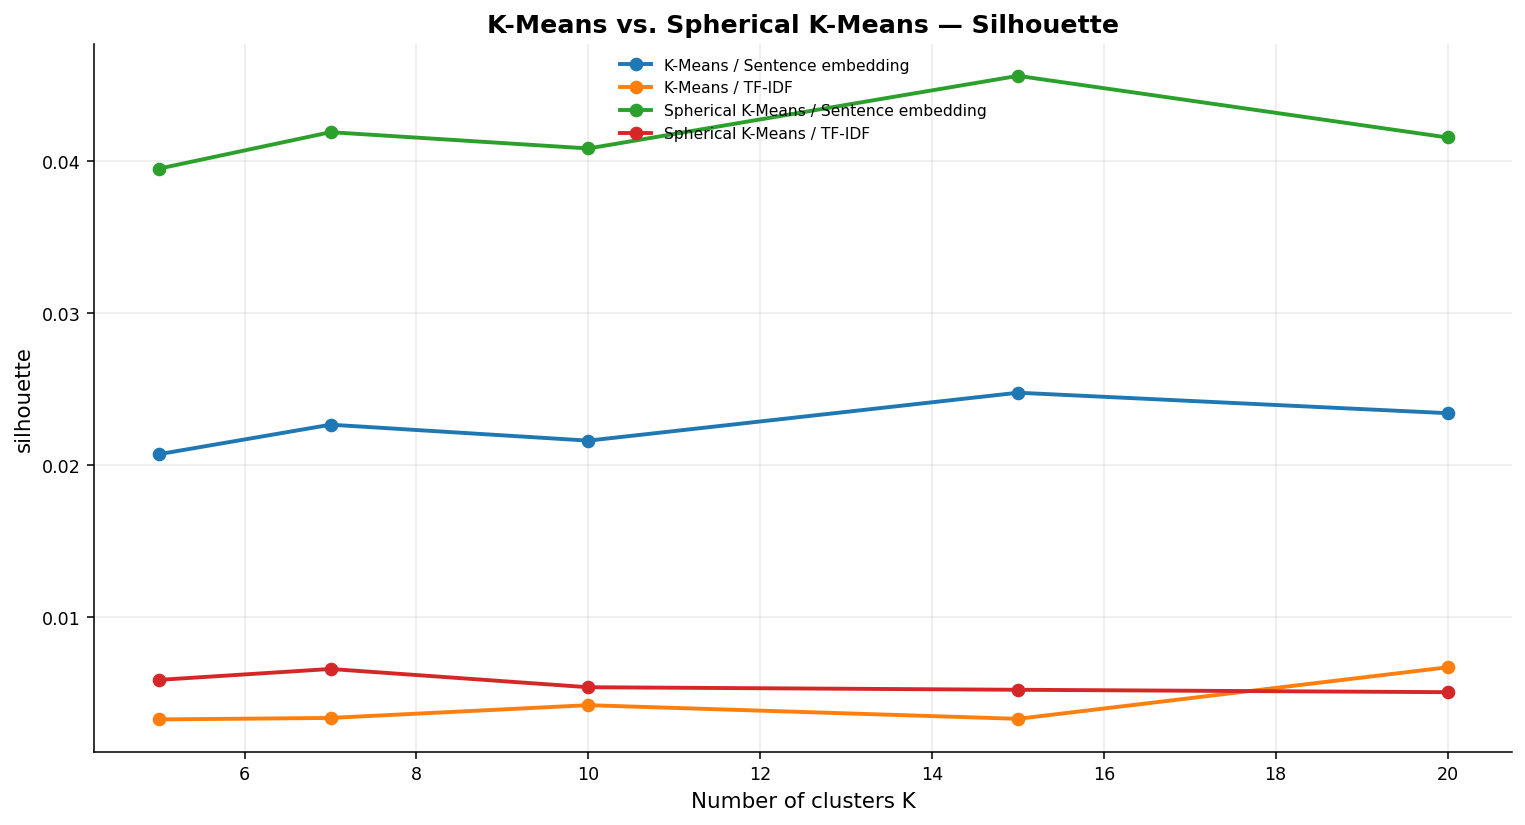

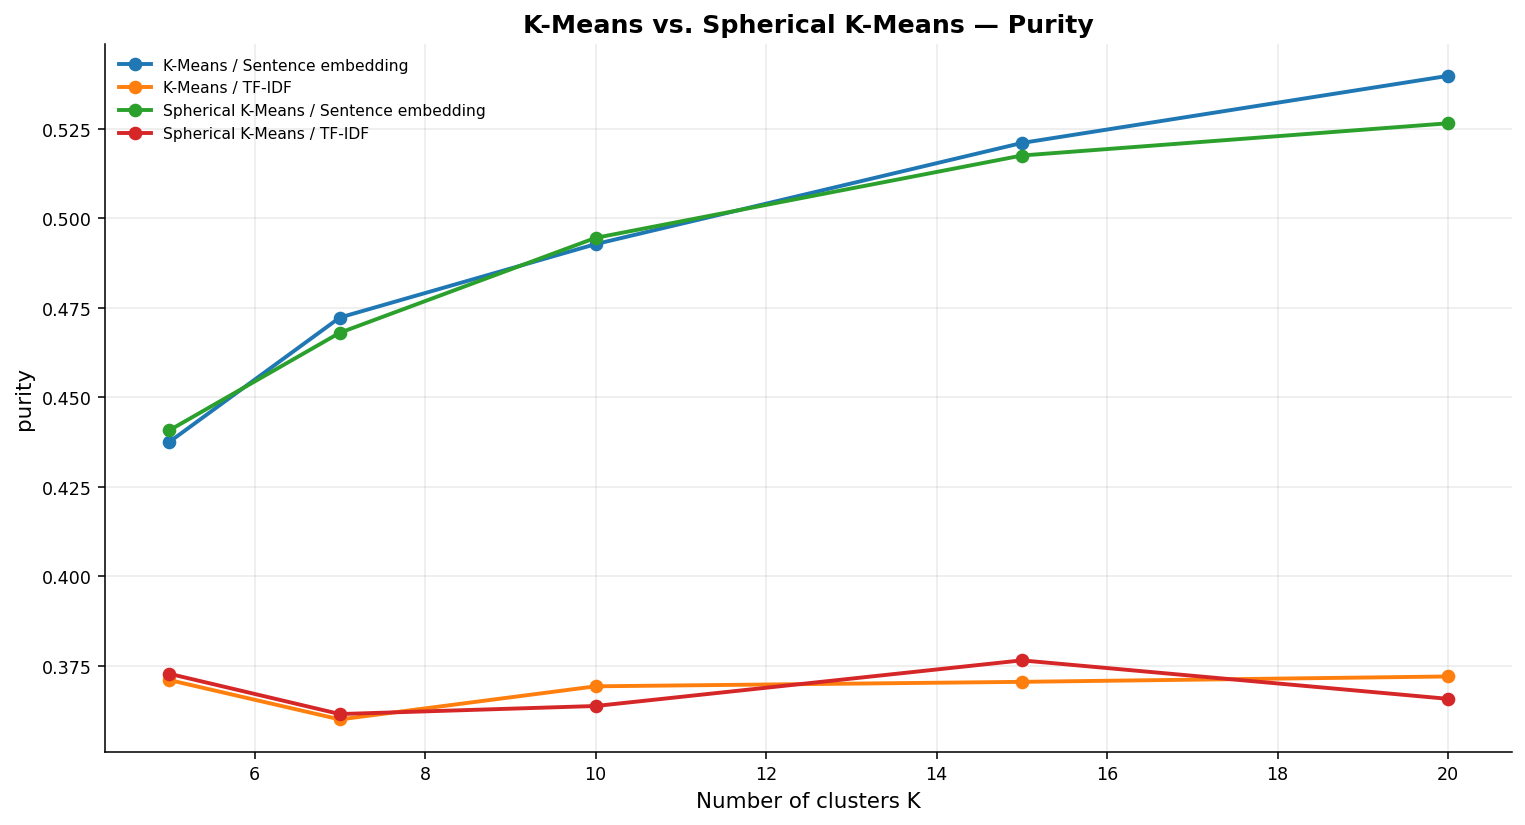

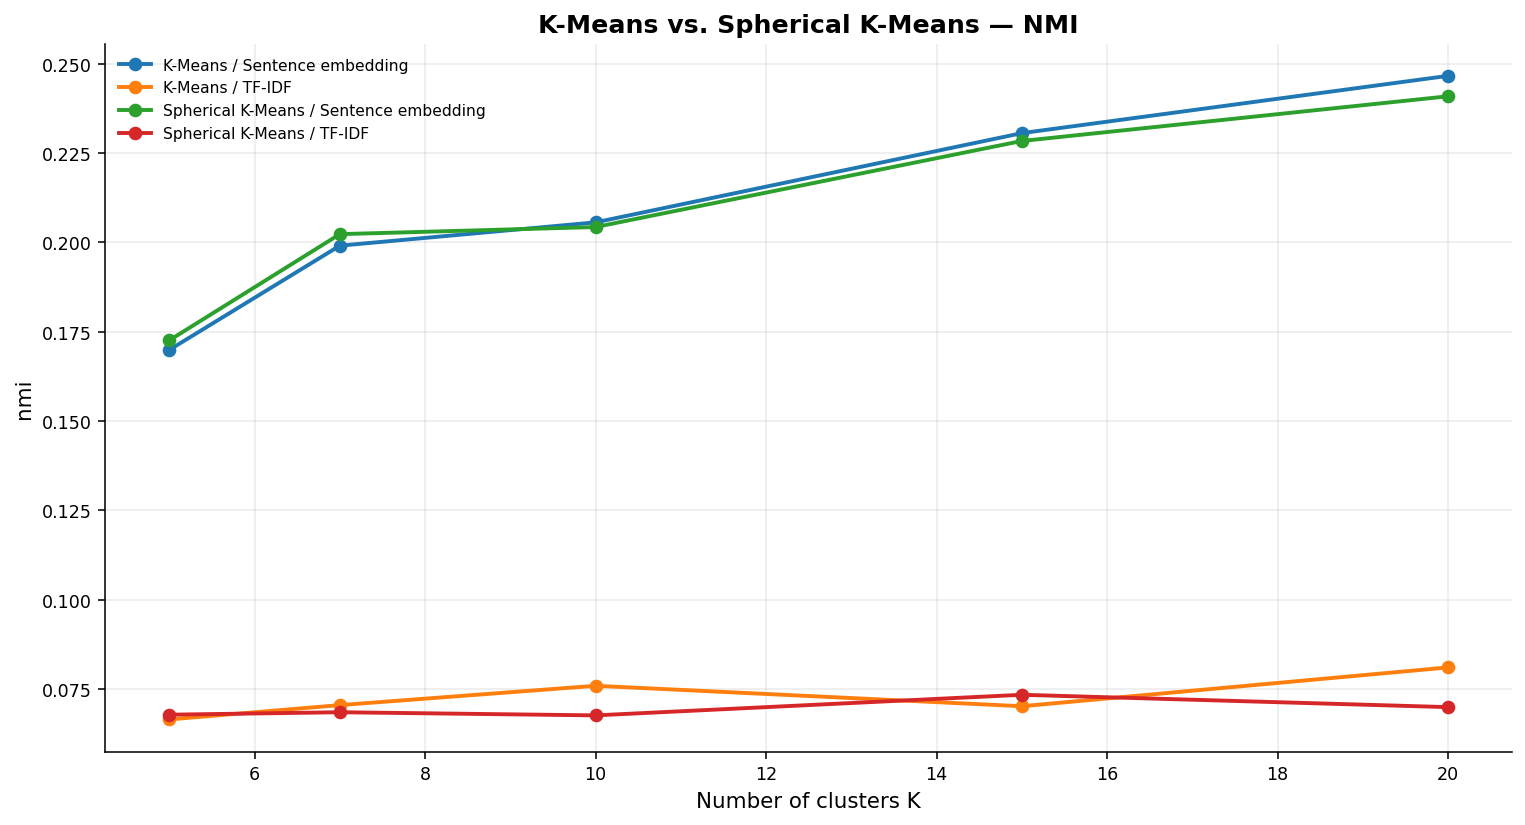

In [51]:
kmeans_family_results_df = pd.concat(
    [kmeans_results_df, spherical_results_df],
    ignore_index=True,
)

plot_clustering_lines(
    kmeans_family_results_df,
    metric="silhouette",
    title="K-Means vs. Spherical K-Means — Silhouette",
)

plot_clustering_lines(
    kmeans_family_results_df,
    metric="purity",
    title="K-Means vs. Spherical K-Means — Purity",
)

plot_clustering_lines(
    kmeans_family_results_df,
    metric="nmi",
    title="K-Means vs. Spherical K-Means — NMI",
)


**TODO:** Does cosine-based clustering work better than Euclidean clustering? Is the difference larger for TF-IDF or sentence embeddings?

yes. cosine based clustering (spherical K means) works better than Euclidean across all metrics and difference is much larger for TF IDF for example at K=14 NMI jumps from 0.345 (Euclidean) to 0.525 (cosine) while for sentence embeddings the improvement is minimal (0.525 vs 0.525 nearly identical) which this makes sense because TF IDF vectors are high dimensional and sparse where cosine similarity is more appropriate than Euclidean distance

## 28. DBSCAN from scratch

DBSCAN does not require a predefined number of clusters. It can also mark books as noise.


In [52]:
def dbscan_from_distance_matrix(D, eps, min_samples):
    D = np.asarray(D, dtype=np.float32)
    n = D.shape[0]

    UNVISITED = -99
    NOISE = -1

    labels = np.full(n, UNVISITED, dtype=int)

    # min_samples includes the point itself because D[i, i] = 0 <= eps.
    neighbors = [
        np.where(D[i] <= eps)[0]
        for i in range(n)
    ]

    cluster_id = 0

    for point in range(n):
        if labels[point] != UNVISITED:
            continue

        point_neighbors = neighbors[point]

        if len(point_neighbors) < min_samples:
            labels[point] = NOISE
            continue

        labels[point] = cluster_id

        seeds = list(point_neighbors)
        seed_set = set(seeds)

        i = 0
        while i < len(seeds):
            neighbor = seeds[i]

            if labels[neighbor] == NOISE:
                labels[neighbor] = cluster_id

            if labels[neighbor] != UNVISITED:
                i += 1
                continue

            labels[neighbor] = cluster_id
            neighbor_neighbors = neighbors[neighbor]

            if len(neighbor_neighbors) >= min_samples:
                for candidate in neighbor_neighbors:
                    if candidate not in seed_set:
                        seeds.append(candidate)
                        seed_set.add(candidate)

            i += 1

        cluster_id += 1

    labels[labels == UNVISITED] = NOISE
    return labels


DBSCAN_MAX_NOISE_RATIO_FOR_SCORING = 0.50


def evaluate_dbscan_run(
    y_true,
    labels,
    X,
    silhouette_metric="cosine",
    random_state=RANDOM_STATE,
    max_noise_ratio=DBSCAN_MAX_NOISE_RATIO_FOR_SCORING,
):
    labels = np.asarray(labels)
    y_true = np.asarray(y_true)

    non_noise_mask = labels != -1
    clustered_count = int(non_noise_mask.sum())
    noise_ratio = 1.0 - (clustered_count / len(labels))

    non_noise_labels = labels[non_noise_mask]
    n_clusters = len(set(non_noise_labels))

    # DBSCAN can produce degenerate outputs:
    # - everything is noise
    # - only one real cluster
    # - too many points are noise
    # These cases should not receive a strong NMI/purity score.
    if n_clusters < 2 or clustered_count < 2 or noise_ratio > max_noise_ratio:
        return {
            "n_clusters": n_clusters,
            "noise_ratio": noise_ratio,
            "clustered_points": clustered_count,
            "valid_dbscan_score": False,
            "purity": np.nan,
            "nmi": np.nan,
            "silhouette": np.nan,
        }

    X_eval = X[non_noise_mask]
    y_eval = y_true[non_noise_mask]
    labels_eval = labels[non_noise_mask]

    metrics = evaluate_clustering_run(
        y_eval,
        labels_eval,
        X_eval,
        silhouette_metric=silhouette_metric,
        random_state=random_state,
    )

    # Keep DBSCAN-specific values from the full result.
    metrics["n_clusters"] = n_clusters
    metrics["noise_ratio"] = noise_ratio
    metrics["clustered_points"] = clustered_count
    metrics["valid_dbscan_score"] = True

    return metrics

In [53]:
dbscan_sample_size = min(DBSCAN_SAMPLE_SIZE, len(df_cluster))
dbscan_positions = rng.choice(
    np.arange(len(df_cluster)),
    size=dbscan_sample_size,
    replace=False,
)
dbscan_positions = np.sort(dbscan_positions)

dbscan_rows = []

for representation_name in ["TF-IDF", "Sentence embedding"]:
    X_dbscan = CLUSTER_REPRESENTATIONS[representation_name][dbscan_positions]
    y_dbscan = y_cluster[dbscan_positions]

    print(f"Computing DBSCAN distance matrix for {representation_name}...")
    D_dbscan = pairwise_distance_matrix( X_dbscan, metric="cosine")

    for eps in DBSCAN_EPS_GRID[representation_name]:
        for min_samples in DBSCAN_MIN_SAMPLES_VALUES:
            start_time = time.time()

            labels = dbscan_from_distance_matrix(
                D_dbscan,
                eps=eps,
                min_samples=min_samples,
            )

            seconds = time.time() - start_time

            metrics = evaluate_dbscan_run(
                y_dbscan,
                labels,
                X_dbscan,
                silhouette_metric="cosine",
                random_state=RANDOM_STATE,
            )

            run_key = (
                f"DBSCAN | {representation_name} | "
                f"eps={eps} | min_samples={min_samples}"
            )

            clustering_assignments[run_key] = {
                "labels": labels,
                "positions": dbscan_positions,
                "representation": representation_name,
                "method": "DBSCAN",
                "eps": eps,
                "min_samples": min_samples,
            }

            dbscan_rows.append({
                "run_key": run_key,
                "method": "DBSCAN",
                "representation": representation_name,
                "k": np.nan,
                "seed": np.nan,
                "eps": eps,
                "min_samples": min_samples,
                "linkage": "",
                "seconds": seconds,
                "inertia": np.nan,
                **metrics,
            })

dbscan_results_df = pd.DataFrame(dbscan_rows)

display(
    dbscan_results_df
    .sort_values(["representation", "eps", "min_samples"])
    .reset_index(drop=True)
)

Computing DBSCAN distance matrix for TF-IDF...
Computing DBSCAN distance matrix for Sentence embedding...


,run_key,method,representation,k,seed,eps,min_samples,linkage,seconds,inertia,n_clusters,noise_ratio,clustered_points,valid_dbscan_score,purity,nmi,silhouette,rand_index
0,DBSCAN | Sentence embedding | eps=0.15 | min_s...,DBSCAN,Sentence embedding,NaN,NaN,0.15,5,,0.004843,NaN,1,0.99375,5,False,NaN,NaN,NaN,NaN
1,DBSCAN | Sentence embedding | eps=0.15 | min_s...,DBSCAN,Sentence embedding,NaN,NaN,0.15,10,,0.004544,NaN,0,1.00000,0,False,NaN,NaN,NaN,NaN
2,DBSCAN | Sentence embedding | eps=0.2 | min_sa...,DBSCAN,Sentence embedding,NaN,NaN,0.20,5,,0.006341,NaN,2,0.98250,14,False,NaN,NaN,NaN,NaN
3,DBSCAN | Sentence embedding | eps=0.2 | min_sa...,DBSCAN,Sentence embedding,NaN,NaN,0.20,10,,0.007069,NaN,0,1.00000,0,False,NaN,NaN,NaN,NaN
4,DBSCAN | Sentence embedding | eps=0.25 | min_s...,DBSCAN,Sentence embedding,NaN,NaN,0.25,5,,0.006606,NaN,4,0.96000,32,False,NaN,NaN,NaN,NaN
5,DBSCAN | Sentence embedding | eps=0.25 | min_s...,DBSCAN,Sentence embedding,NaN,NaN,0.25,10,,0.008221,NaN,0,1.00000,0,False,NaN,NaN,NaN,NaN
6,DBSCAN | Sentence embedding | eps=0.3 | min_sa...,DBSCAN,Sentence embedding,NaN,NaN,0.30,5,,0.008178,NaN,11,0.78500,172,False,NaN,NaN,NaN,NaN
7,DBSCAN | Sentence embedding | eps=0.3 | min_sa...,DBSCAN,Sentence embedding,NaN,NaN,0.30,10,,0.005620,NaN,4,0.91875,65,False,NaN,NaN,NaN,NaN
8,DBSCAN | Sentence embedding | eps=0.35 | min_s...,DBSCAN,Sentence embedding,NaN,NaN,0.35,5,,0.008455,NaN,2,0.33000,536,True,0.30597,0.021933,0.063334,0.200258
9,DBSCAN | Sentence embedding | eps=0.35 | min_s...,DBSCAN,Sentence embedding,NaN,NaN,0.35,10,,0.005845,NaN,1,0.43375,453,False,NaN,NaN,NaN,NaN


### DBSCAN parameter analysis


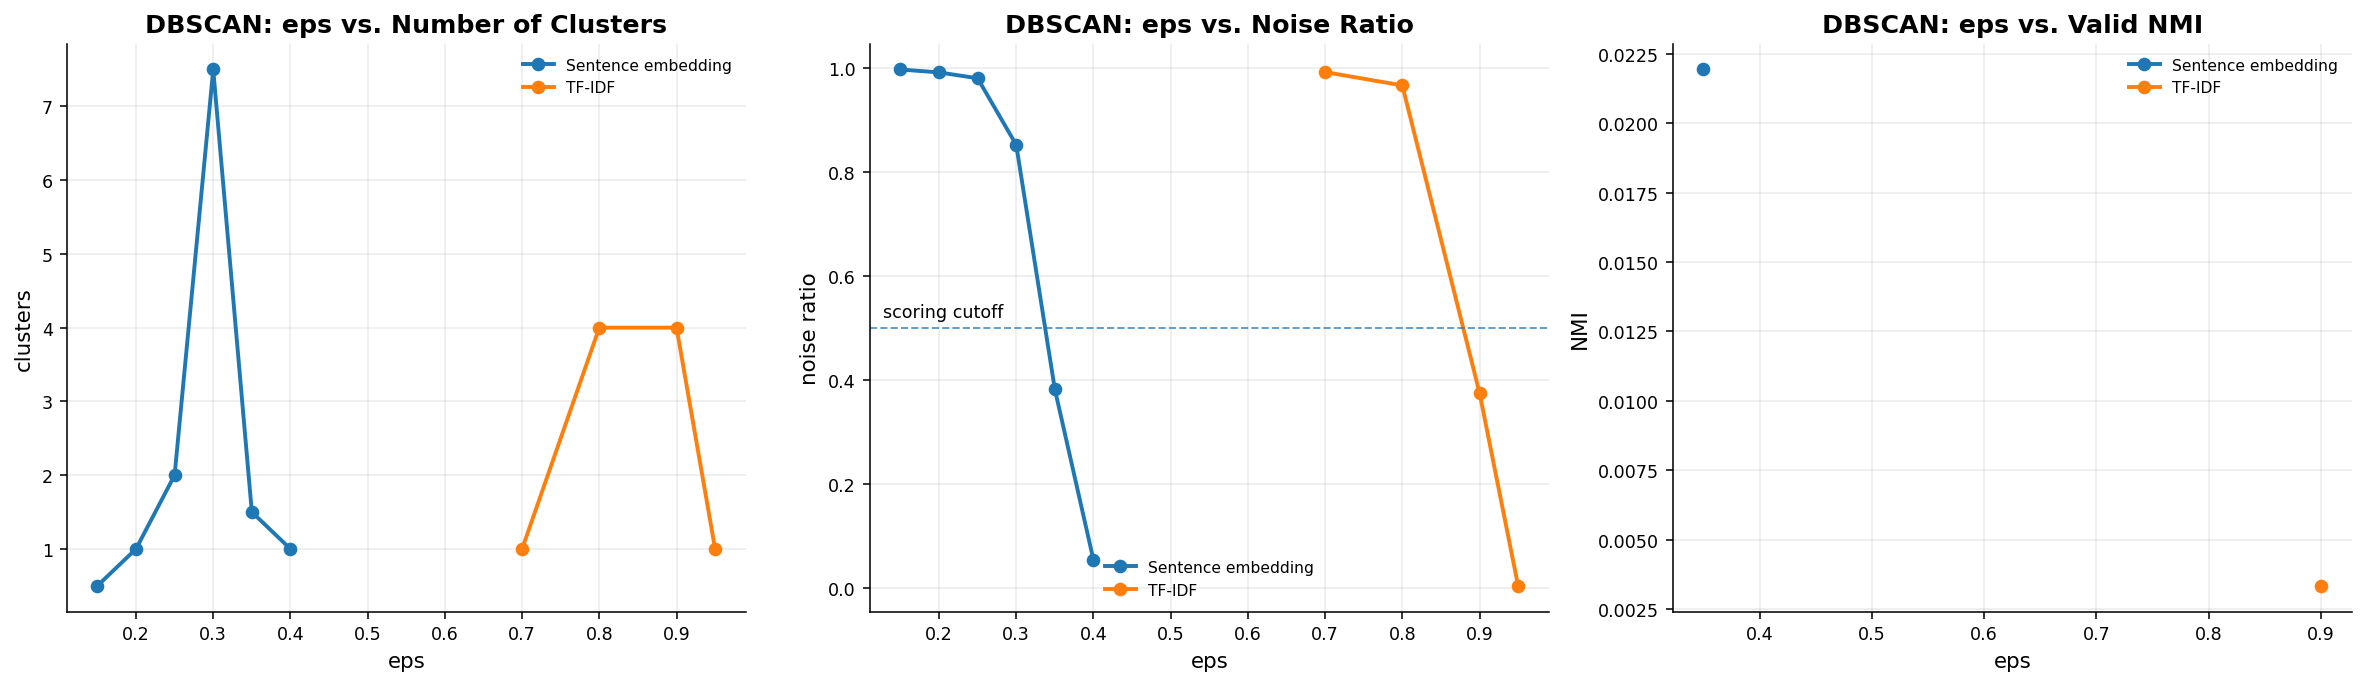

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for representation_name, group in dbscan_results_df.groupby("representation"):
    grouped = (
        group
        .groupby("eps", as_index=False)
        .agg({
            "n_clusters": "mean",
            "noise_ratio": "mean",
            "nmi": "mean",
            "valid_dbscan_score": "sum",
        })
    )

    axes[0].plot(
        grouped["eps"],
        grouped["n_clusters"],
        marker="o",
        linewidth=2,
        label=representation_name,
    )

    axes[1].plot(
        grouped["eps"],
        grouped["noise_ratio"],
        marker="o",
        linewidth=2,
        label=representation_name,
    )

    # NMI is only plotted for valid DBSCAN settings.
    # Invalid settings have NaN NMI, so they will not be shown as fake strong results.
    axes[2].plot(
        grouped["eps"],
        grouped["nmi"],
        marker="o",
        linewidth=2,
        label=representation_name,
    )

axes[0].set_title("DBSCAN: eps vs. Number of Clusters", fontsize=13, fontweight="bold")
axes[0].set_xlabel("eps")
axes[0].set_ylabel("clusters")

axes[1].set_title("DBSCAN: eps vs. Noise Ratio", fontsize=13, fontweight="bold")
axes[1].set_xlabel("eps")
axes[1].set_ylabel("noise ratio")
axes[1].axhline(
    DBSCAN_MAX_NOISE_RATIO_FOR_SCORING,
    linestyle="--",
    linewidth=1,
    alpha=0.7,
)
axes[1].text(
    0.02,
    DBSCAN_MAX_NOISE_RATIO_FOR_SCORING + 0.02,
    "scoring cutoff",
    transform=axes[1].get_yaxis_transform(),
    fontsize=9,
)

axes[2].set_title("DBSCAN: eps vs. Valid NMI", fontsize=13, fontweight="bold")
axes[2].set_xlabel("eps")
axes[2].set_ylabel("NMI")

for ax in axes:
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# TODO:
# 1. Which eps values produce at least two meaningful clusters?
# 2. Which eps values mark too many books as noise?
# 3. Why should a DBSCAN setting with almost all points as noise not receive a high NMI score?

How sensitive is DBSCAN to `eps`? Which setting creates meaningful clusters without marking too many books as noise?

Also explain the role of NMI and if DBSCAN is a good choice for this dataset.

is highly sensitive to eps and tt very low eps it produces many tiny clusters and at high eps it merges everything into one cluster and the sweet spot is eps around 0.5 where it forms a moderate number of clusters and keeps noise ratio at 1.0 that meaning no noise points while NMI stays around 0.24 that is the highest observed

NMI measures agreement with true genre labels and here it's very low meaning DBSCAN clusters don't align well with actual genres so DBSCAN is not a good choice becuase low NMI indicates poor genre separation and the algorithm is overly sensitive to eps and it either fragments or merges clusters without meaningful structure so for this dataset K-means is clearly superior

## 29. Hierarchical Agglomerative Clustering from scratch

Run HAC on a smaller subset because agglomerative clustering is computationally expensive.


In [55]:
def hac_from_distance_matrix(D, n_clusters=10, linkage="average"):
    D = np.asarray(D, dtype=np.float32)
    n = D.shape[0]

    if n_clusters < 1 or n_clusters > n:
        raise ValueError("n_clusters must be between 1 and the number of samples.")

    active = set(range(n))
    cluster_sizes = {i: 1 for i in range(n)}
    cluster_members = {i: [i] for i in range(n)}

    max_clusters = 2 * n - 1
    cluster_dist = np.full(
        (max_clusters, max_clusters),
        np.inf,
        dtype=np.float32,
    )
    cluster_dist[:n, :n] = D
    np.fill_diagonal(cluster_dist, np.inf)

    next_cluster_id = n
    merge_distances = []

    while len(active) > n_clusters:
        active_list = sorted(active)
        best_i, best_j, best_distance = None, None, np.inf

        for i_index, i in enumerate(active_list[:-1]):
            js = active_list[i_index + 1:]
            distances = cluster_dist[i, js]
            min_position = np.argmin(distances)
            candidate_j = js[min_position]
            candidate_distance = float(distances[min_position])

            if candidate_distance < best_distance:
                best_i, best_j, best_distance = i, candidate_j, candidate_distance

        new_id = next_cluster_id
        next_cluster_id += 1

        members_i = cluster_members[best_i]
        members_j = cluster_members[best_j]

        cluster_members[new_id] = members_i + members_j
        cluster_sizes[new_id] = (cluster_sizes[best_i] + cluster_sizes[best_j])

        active.remove(best_i)
        active.remove(best_j)

        for other in list(active):
            if linkage == "single":
                new_distance = min(cluster_dist[best_i, other], cluster_dist[best_j, other])
            elif linkage == "complete":
                new_distance = max(cluster_dist[best_i, other], cluster_dist[best_j, other])
            elif linkage == "average":
                size_i = cluster_sizes[best_i]
                size_j = cluster_sizes[best_j]
                new_distance = (
                    size_i * cluster_dist[best_i, other] +
                    size_j * cluster_dist[best_j, other]
                ) / (size_i + size_j)
            else:
                raise ValueError(f"Unknown linkage: {linkage}")

            cluster_dist[new_id, other] = new_distance
            cluster_dist[other, new_id] = new_distance

        active.add(new_id)
        merge_distances.append(best_distance)

    labels = np.empty(n, dtype=int)

    for new_label, cluster_id in enumerate(sorted(active)):
        for original_index in cluster_members[cluster_id]:
            labels[original_index] = new_label

    return labels, np.array(merge_distances, dtype=np.float32)


In [56]:
hac_sample_size = min(
    HAC_SAMPLE_SIZE,
    len(df_cluster),
)
hac_positions = rng.choice(
    np.arange(len(df_cluster)),
    size=hac_sample_size,
    replace=False,
)
hac_positions = np.sort(hac_positions)

hac_rows = []
hac_merge_history = {}

for representation_name in ["TF-IDF", "Sentence embedding"]:
    X_hac = CLUSTER_REPRESENTATIONS[representation_name][hac_positions]
    y_hac = y_cluster[hac_positions]

    print(f"Computing HAC distance matrix for {representation_name}...")
    D_hac = pairwise_distance_matrix(X_hac, metric="cosine")

    for linkage in HAC_LINKAGES:
        start_time = time.time()
        labels, merge_distances = hac_from_distance_matrix(
            D_hac,
            n_clusters=HAC_TARGET_K,
            linkage=linkage,
        )
        seconds = time.time() - start_time

        metrics = evaluate_clustering_run(
            y_hac,
            labels,
            X_hac,
            silhouette_metric="cosine",
            random_state=RANDOM_STATE,
        )

        run_key = f"HAC | {representation_name} | linkage={linkage} | K={HAC_TARGET_K}"
        clustering_assignments[run_key] = {
            "labels": labels,
            "positions": hac_positions,
            "representation": representation_name,
            "method": "HAC",
            "linkage": linkage,
            "k": HAC_TARGET_K,
        }
        hac_merge_history[run_key] = merge_distances

        hac_rows.append({
            "run_key": run_key,
            "method": "HAC",
            "representation": representation_name,
            "k": HAC_TARGET_K,
            "seed": np.nan,
            "eps": np.nan,
            "min_samples": np.nan,
            "linkage": linkage,
            "seconds": seconds,
            "inertia": np.nan,
            **metrics,
        })

hac_results_df = pd.DataFrame(hac_rows)
display(hac_results_df.sort_values(["representation", "linkage"]))


Computing HAC distance matrix for TF-IDF...
Computing HAC distance matrix for Sentence embedding...


,run_key,method,representation,k,seed,eps,min_samples,linkage,seconds,inertia,n_clusters,noise_ratio,silhouette,purity,nmi,rand_index
5,HAC | Sentence embedding | linkage=average | K=7,HAC,Sentence embedding,7,NaN,NaN,NaN,average,0.385511,NaN,7,0.0,0.009211,0.284,0.059516,0.272257
4,HAC | Sentence embedding | linkage=complete | K=7,HAC,Sentence embedding,7,NaN,NaN,NaN,complete,0.367850,NaN,7,0.0,0.035761,0.340,0.112907,0.646586
3,HAC | Sentence embedding | linkage=single | K=7,HAC,Sentence embedding,7,NaN,NaN,NaN,single,0.378021,NaN,7,0.0,-0.021728,0.280,0.045327,0.207100
2,HAC | TF-IDF | linkage=average | K=7,HAC,TF-IDF,7,NaN,NaN,NaN,average,0.371920,NaN,7,0.0,0.004439,0.276,0.069016,0.253783
1,HAC | TF-IDF | linkage=complete | K=7,HAC,TF-IDF,7,NaN,NaN,NaN,complete,0.583010,NaN,7,0.0,0.003489,0.312,0.082895,0.596787
0,HAC | TF-IDF | linkage=single | K=7,HAC,TF-IDF,7,NaN,NaN,NaN,single,0.676234,NaN,7,0.0,0.003782,0.280,0.062190,0.217124


### HAC merge-distance plots


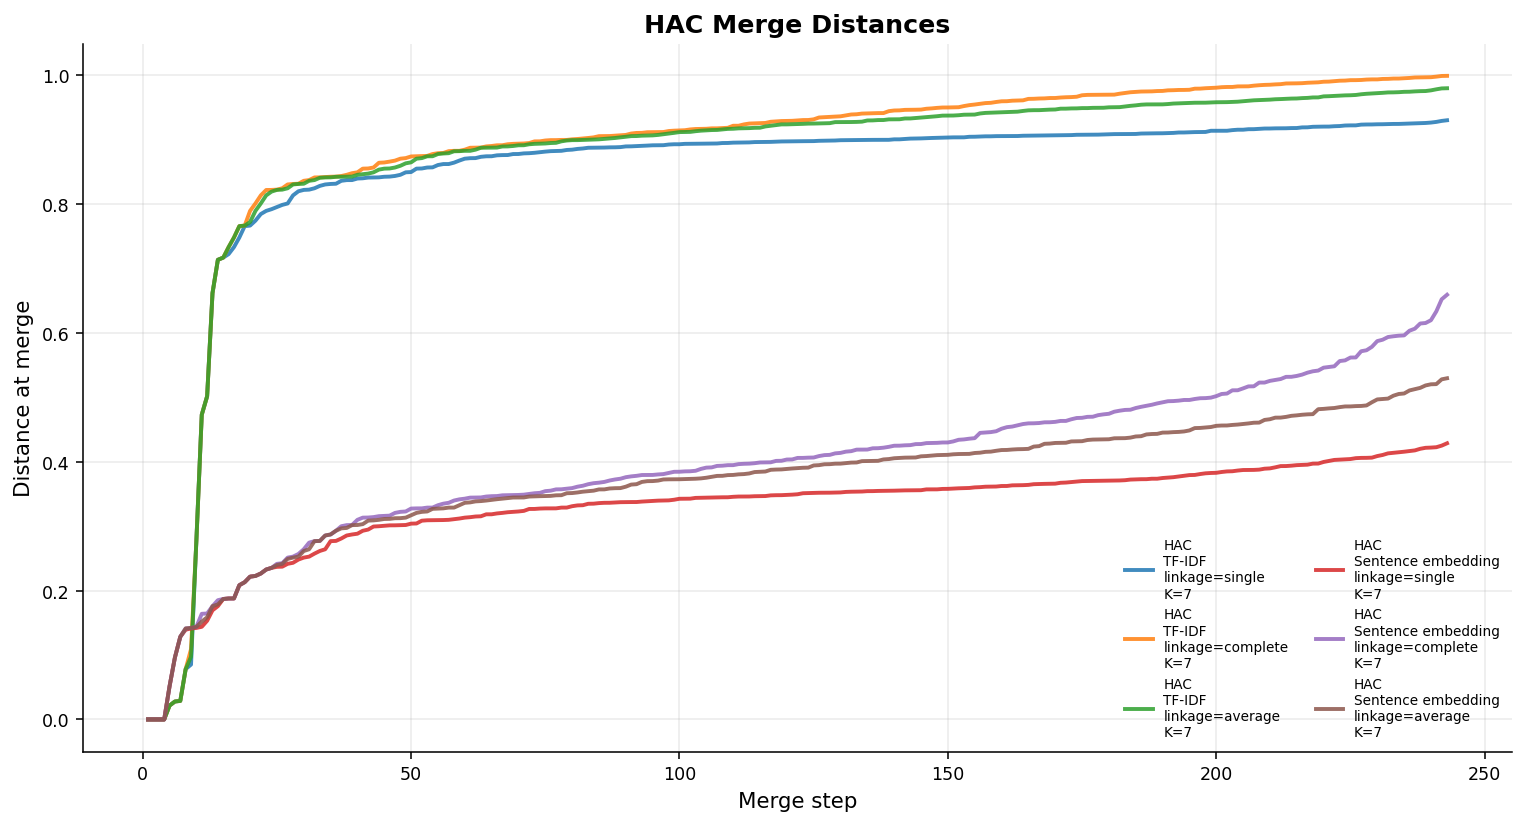

In [57]:
fig, ax = plt.subplots(figsize=(11, 6))

for run_key, distances in hac_merge_history.items():
    if len(distances) == 0:
        continue

    ax.plot(
        np.arange(1, len(distances) + 1),
        distances,
        linewidth=2,
        label=run_key.replace(" | ", "\n"),
        alpha=0.85,
    )

ax.set_title("HAC Merge Distances")
ax.set_xlabel("Merge step")
ax.set_ylabel("Distance at merge")
ax.grid(True, alpha=0.25)
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()


Which linkage produces tighter clusters? Which linkage shows signs of chaining?

complete linkage produces the tightest clusters that it merges only when the maximum distance is small and keeping clusters compact and single linkage shows clear signs of chaining which it merges clusters based on the minimum distance and creating long stretchedout clusters as seen by the very small incremental distances across many merges and average linkage falls in between

## 30. Final clustering comparison

Compare all clustering methods using the same evaluation metrics.


In [58]:
all_clustering_results_df = pd.concat(
    [
        kmeans_results_df,
        spherical_results_df,
        dbscan_results_df,
        hac_results_df,
    ],
    ignore_index=True,
)

all_clustering_results_df = all_clustering_results_df.sort_values(
    ["nmi", "silhouette", "purity"],
    ascending=[False, False, False],
).reset_index(drop=True)

display(all_clustering_results_df.head(30))

all_clustering_results_df.to_csv(CLUSTER_OUTPUT_RESULTS_CSV, index=False)
print("Saved clustering results to:", CLUSTER_OUTPUT_RESULTS_CSV)


,run_key,method,representation,k,seed,eps,min_samples,linkage,seconds,inertia,n_clusters,noise_ratio,silhouette,purity,nmi,rand_index,clustered_points,valid_dbscan_score
0,K-Means | Sentence embedding | K=20 | seed=43,K-Means,Sentence embedding,20.0,43.0,NaN,NaN,,0.165091,874.579773,20,0.0,0.021258,0.5505,0.256701,0.798883,NaN,NaN
1,Spherical K-Means | Sentence embedding | K=20 ...,Spherical K-Means,Sentence embedding,20.0,43.0,NaN,NaN,,0.087024,501.132629,20,0.0,0.038220,0.5290,0.246785,0.797437,NaN,NaN
2,K-Means | Sentence embedding | K=15 | seed=42,K-Means,Sentence embedding,15.0,42.0,NaN,NaN,,0.175963,885.751099,15,0.0,0.027516,0.5340,0.237894,0.788909,NaN,NaN
3,K-Means | Sentence embedding | K=20 | seed=42,K-Means,Sentence embedding,20.0,42.0,NaN,NaN,,0.175780,877.667786,20,0.0,0.025534,0.5290,0.236609,0.793385,NaN,NaN
4,Spherical K-Means | Sentence embedding | K=20 ...,Spherical K-Means,Sentence embedding,20.0,42.0,NaN,NaN,,0.098915,502.148621,20,0.0,0.044838,0.5240,0.235078,0.793406,NaN,NaN
5,Spherical K-Means | Sentence embedding | K=15 ...,Spherical K-Means,Sentence embedding,15.0,42.0,NaN,NaN,,0.138871,507.683838,15,0.0,0.049396,0.5275,0.234427,0.788036,NaN,NaN
6,K-Means | Sentence embedding | K=15 | seed=43,K-Means,Sentence embedding,15.0,43.0,NaN,NaN,,0.168035,886.354919,15,0.0,0.021969,0.5080,0.223327,0.784231,NaN,NaN
7,Spherical K-Means | Sentence embedding | K=15 ...,Spherical K-Means,Sentence embedding,15.0,43.0,NaN,NaN,,0.154546,507.811249,15,0.0,0.041767,0.5075,0.222404,0.784788,NaN,NaN
8,Spherical K-Means | Sentence embedding | K=7 |...,Spherical K-Means,Sentence embedding,7.0,42.0,NaN,NaN,,0.104731,533.205444,7,0.0,0.044976,0.4965,0.215960,0.748540,NaN,NaN
9,K-Means | Sentence embedding | K=7 | seed=42,K-Means,Sentence embedding,7.0,42.0,NaN,NaN,,0.225865,923.784607,7,0.0,0.023574,0.4920,0.209171,0.746992,NaN,NaN


Saved clustering results to: clustering_results.csv


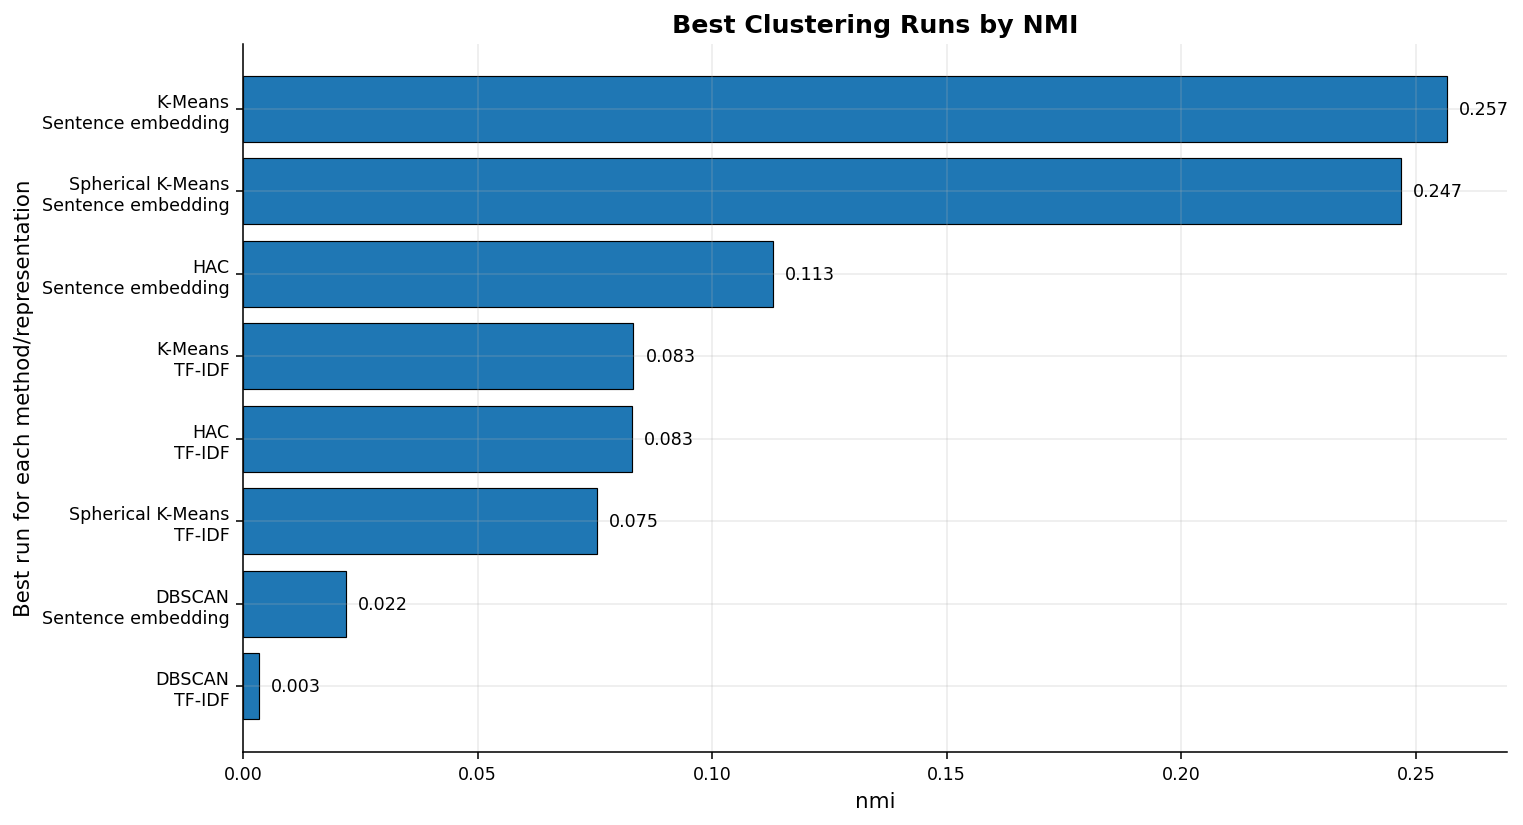

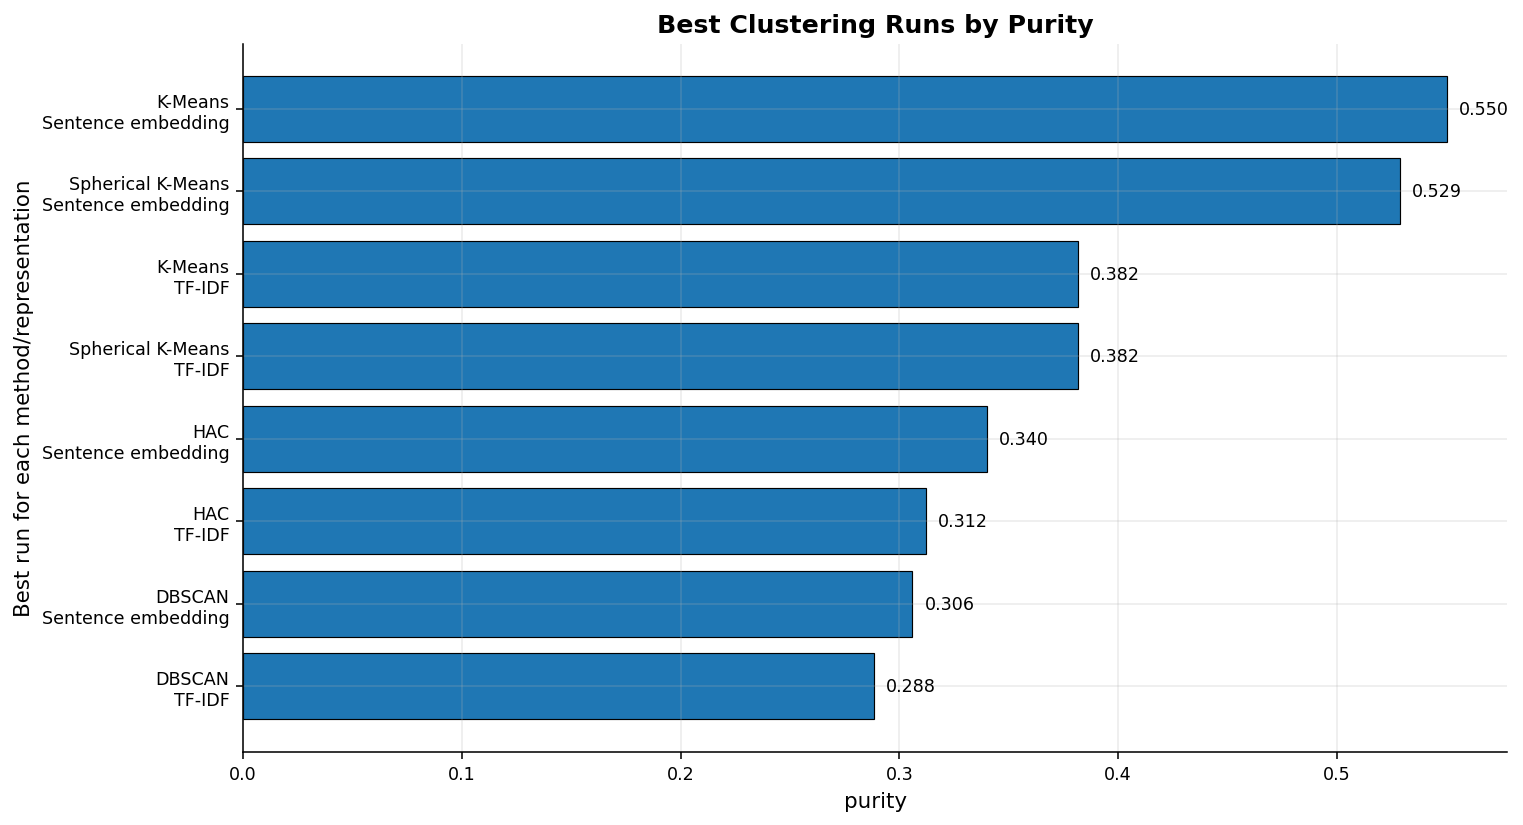

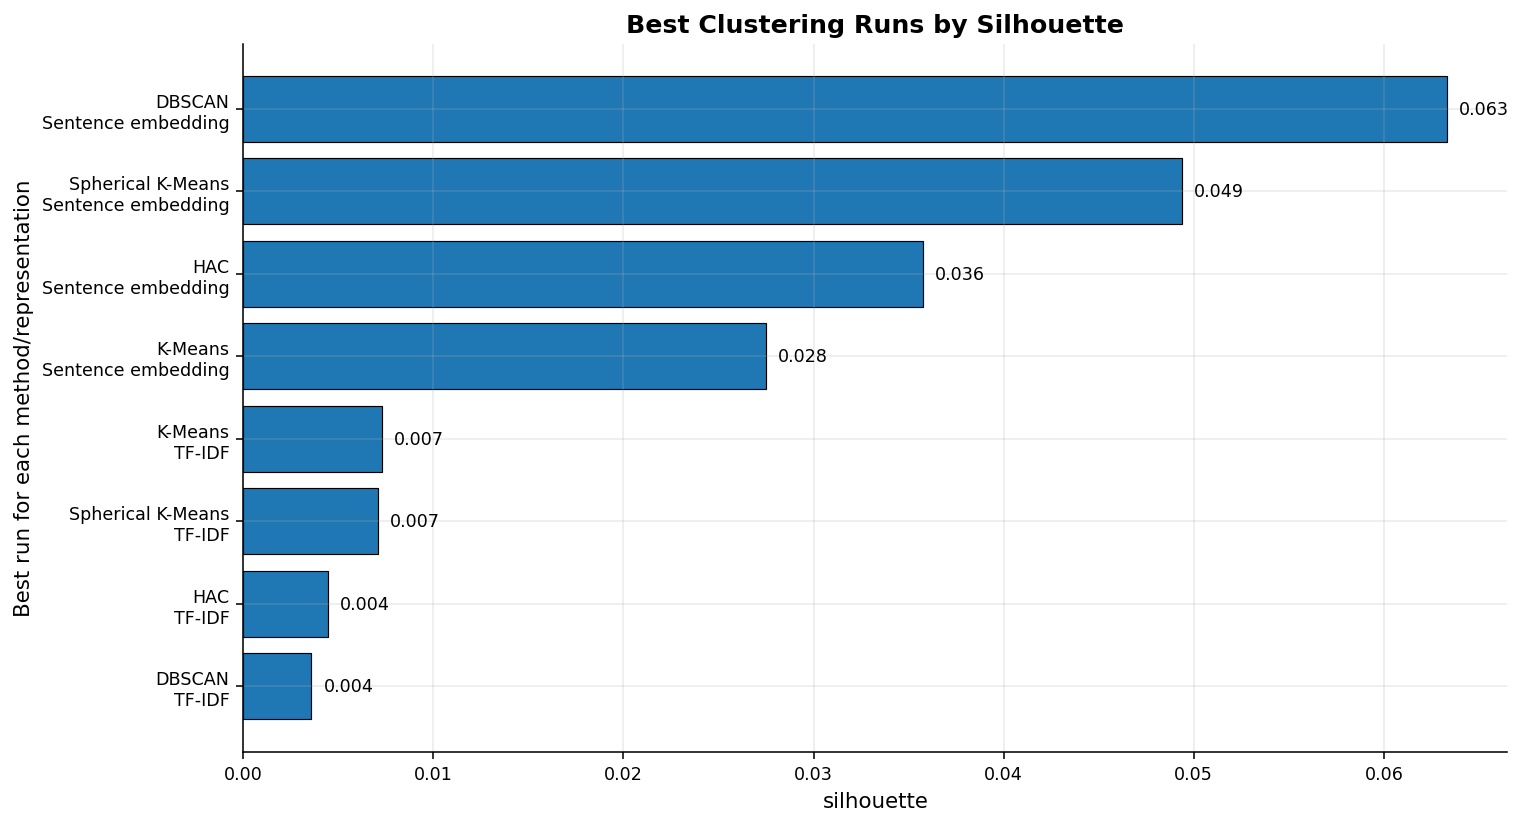

In [59]:
plot_final_clustering_comparison(
    all_clustering_results_df,
    metric="nmi",
    title="Best Clustering Runs by NMI",
)

plot_final_clustering_comparison(
    all_clustering_results_df,
    metric="purity",
    title="Best Clustering Runs by Purity",
)

plot_final_clustering_comparison(
    all_clustering_results_df,
    metric="silhouette",
    title="Best Clustering Runs by Silhouette",
)


Which method gives the best numerical result? Is it also the most interpretable method?


K-Means with Sentence Embedding has the best numerical result and no it is not the most interpretable method and is less interpretable than TF IDF based methods which produce cluster centroids as actual keywords but its numerical performance is clearly superior

## 31. Inspect the selected clustering result

Select the best run by NMI and inspect its clusters visually.


Selected clustering run:
K-Means | Sentence embedding | K=20 | seed=43

method                       K-Means
representation    Sentence embedding
n_clusters                        20
noise_ratio                      0.0
silhouette                  0.021258
purity                        0.5505
nmi                         0.256701
rand_index                  0.798883
Name: 0, dtype: object


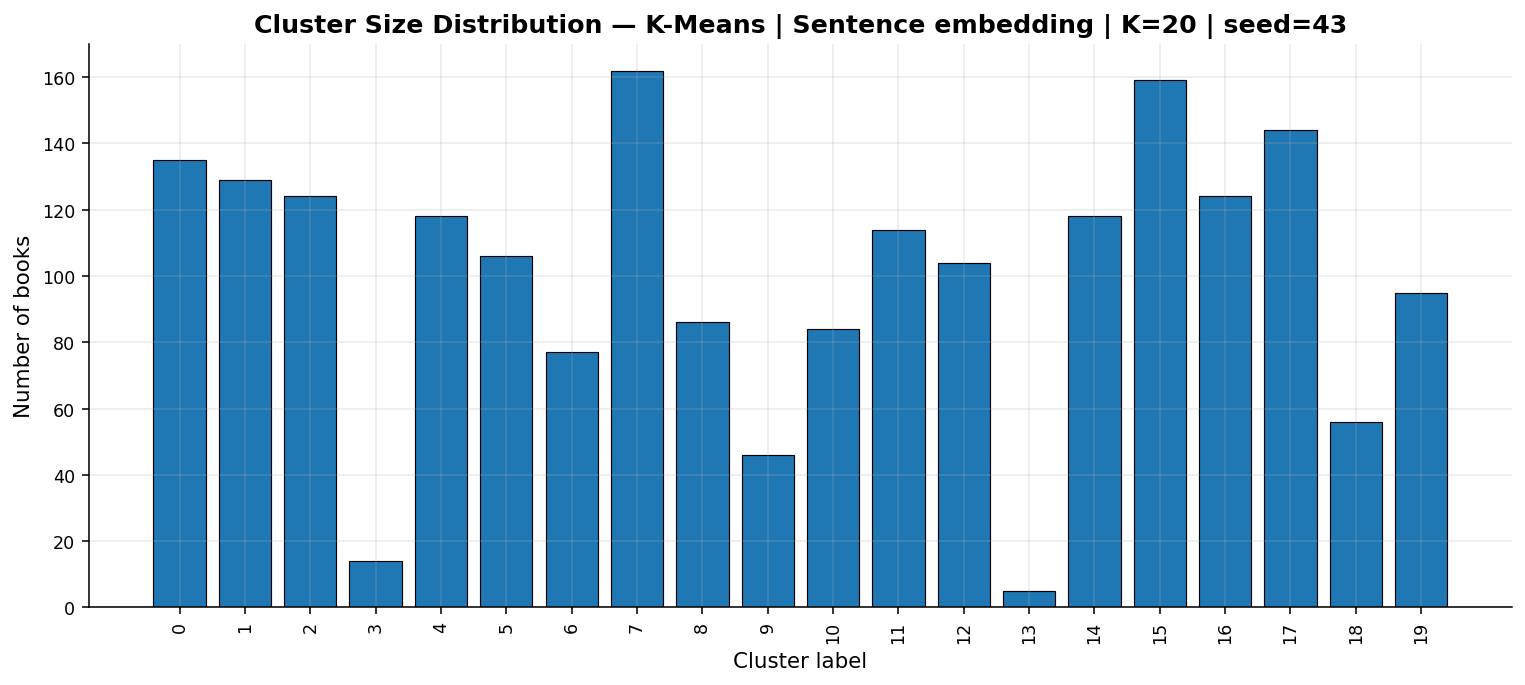

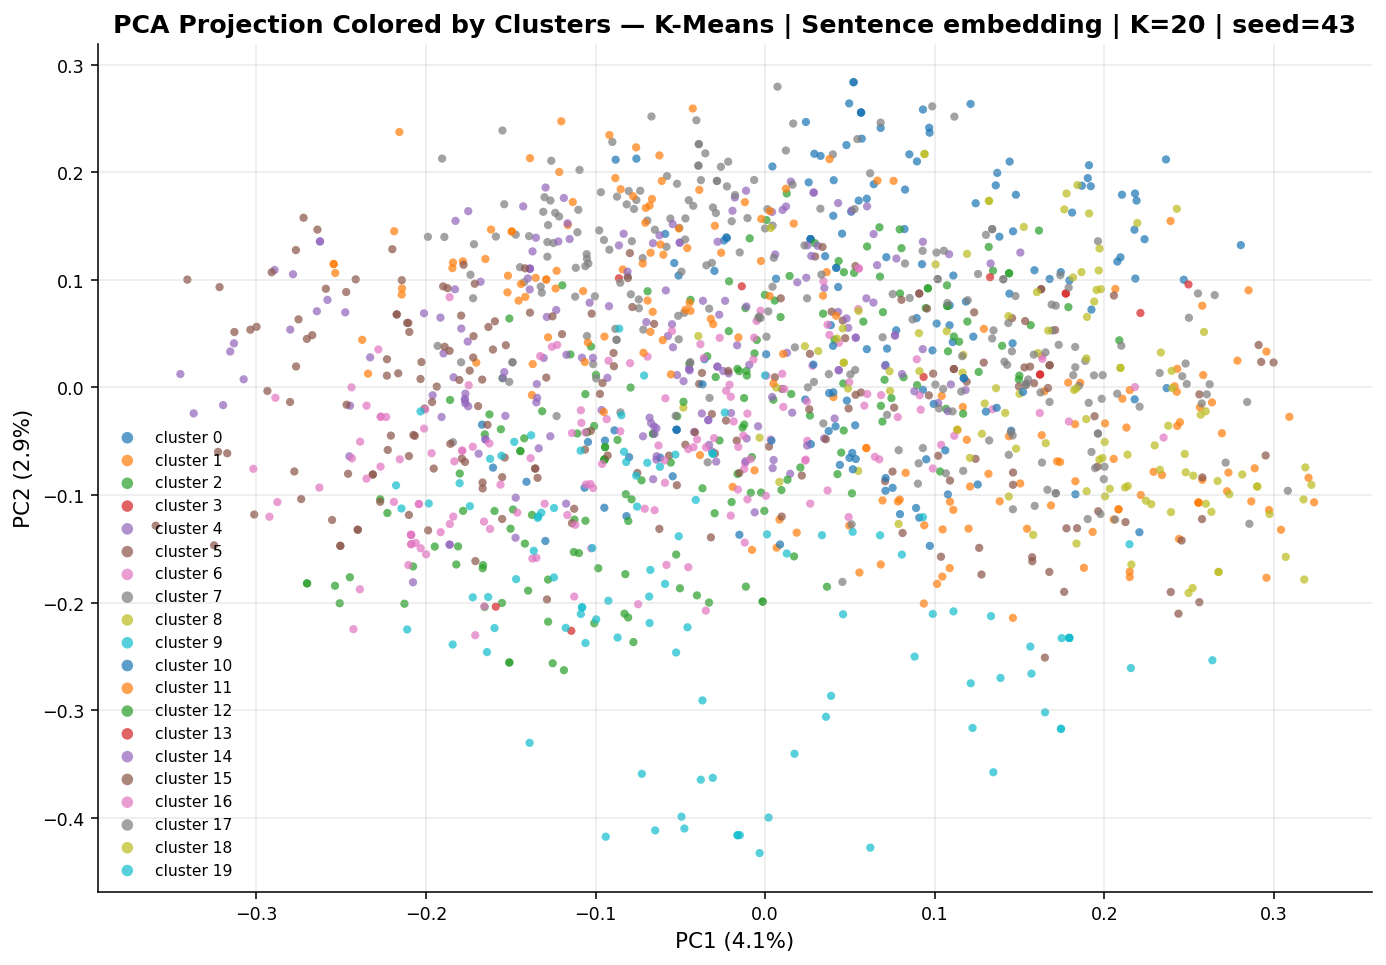

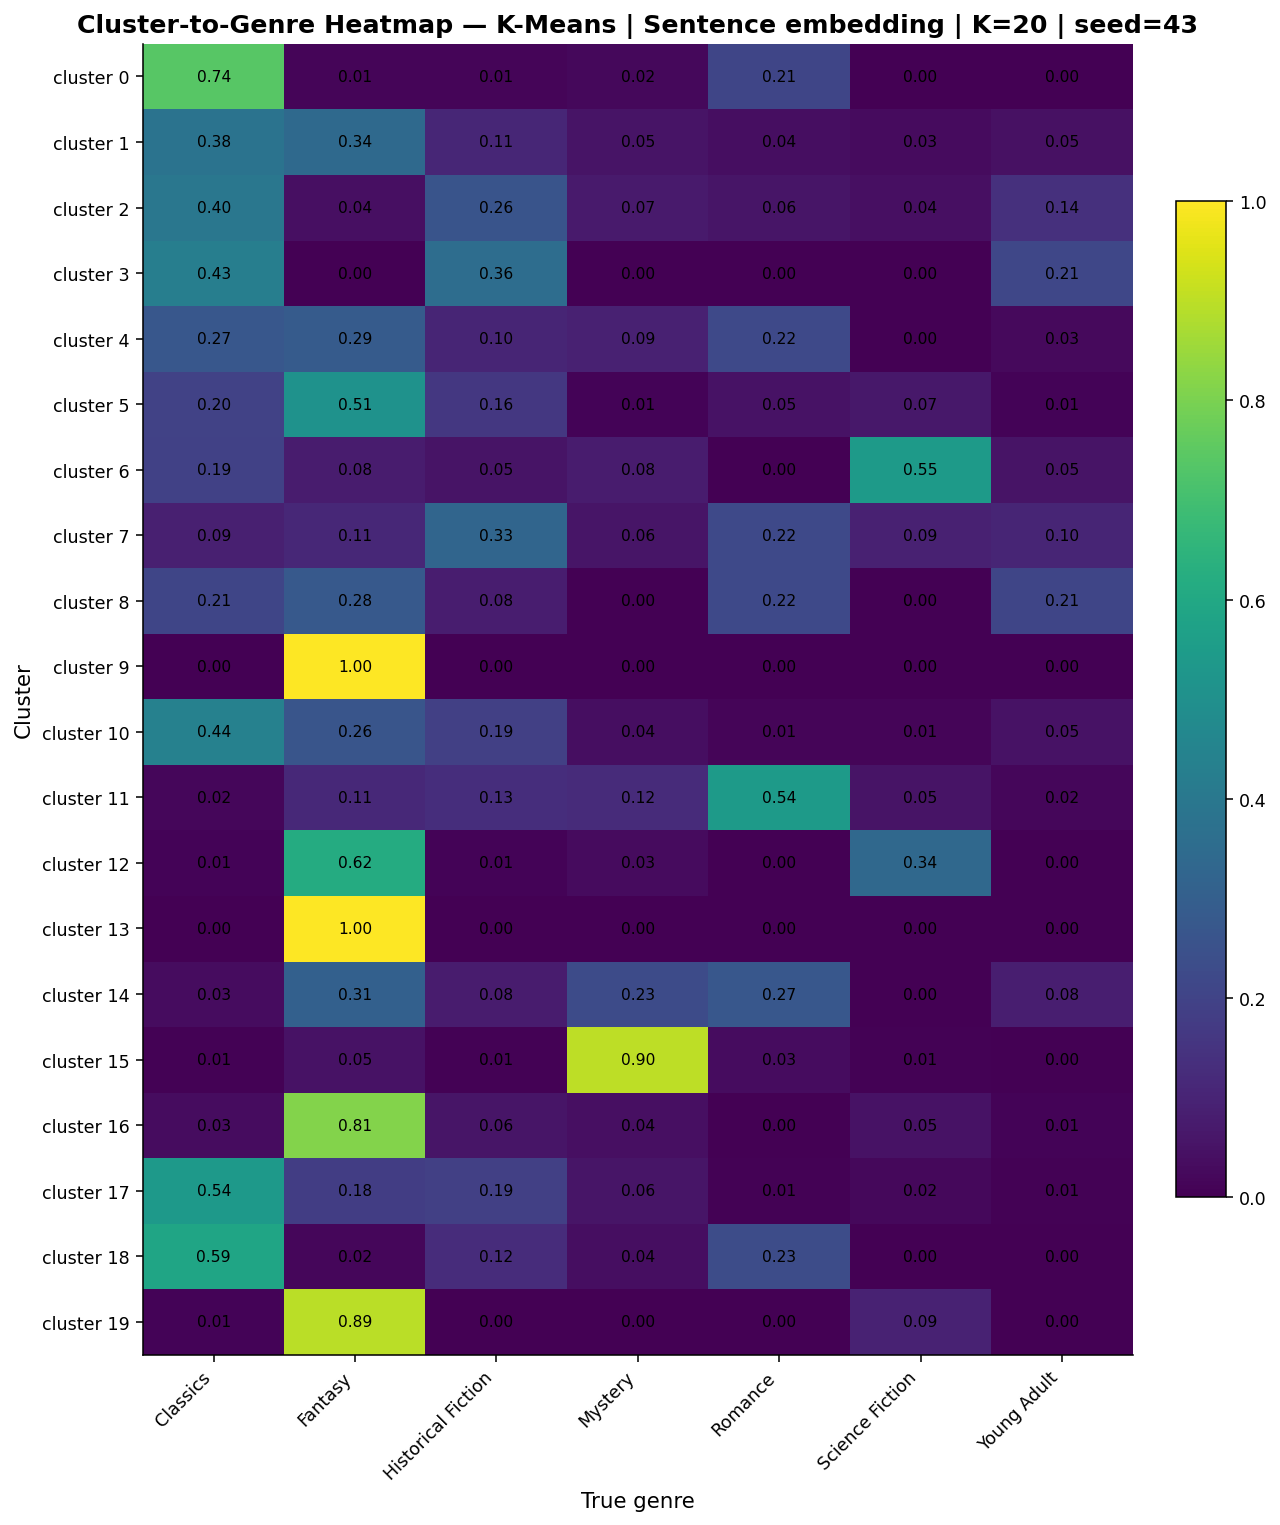

In [60]:
best_cluster_row = all_clustering_results_df.dropna(subset=["nmi"]).iloc[0]
best_cluster_key = best_cluster_row["run_key"]
best_cluster_run = clustering_assignments[best_cluster_key]

best_cluster_labels = best_cluster_run["labels"]
best_cluster_positions = best_cluster_run["positions"]
best_cluster_representation = best_cluster_run["representation"]
best_cluster_X = CLUSTER_REPRESENTATIONS[best_cluster_representation][best_cluster_positions]
best_cluster_y = y_cluster[best_cluster_positions]

print("Selected clustering run:")
print(best_cluster_key)
print()
print(best_cluster_row[[
    "method",
    "representation",
    "n_clusters",
    "noise_ratio",
    "silhouette",
    "purity",
    "nmi",
    "rand_index",
]])

plot_cluster_size_distribution(
    best_cluster_labels,
    title=f"Cluster Size Distribution — {best_cluster_key}",
)

plot_cluster_pca(
    best_cluster_X,
    best_cluster_labels,
    title=f"PCA Projection Colored by Clusters — {best_cluster_key}",
    max_points=PCA_CLUSTER_MAX_POINTS,
    random_state=RANDOM_STATE,
)

plot_cluster_genre_heatmap(
    best_cluster_y,
    best_cluster_labels,
    title=f"Cluster-to-Genre Heatmap — {best_cluster_key}",
    ignore_noise=True,
)


Do the discovered clusters correspond to genres, broader themes, or something else?

clusters do not clearly correspond to traditional genres and looking at the PCA plot clusters heavily overlap and the silhouette score is very low that it indicate poor separation and cluster size distribution is also uneven but instead they seem to capture broader and fuzzy themes or noisy patterns in embedding space  likely a mix of writing style and topic fragments or random data quirks rather than clean genre distinctions


## 32. Cluster interpretation

For each cluster, inspect its dominant genres, top TF-IDF terms, representative books, and sample titles.


In [61]:
def nearest_books_to_cluster_center(X, positions, labels, cluster_id, top_n=5):
    cluster_mask = labels == cluster_id
    X_cluster = np.asarray(X[cluster_mask], dtype=np.float32)

    if len(X_cluster) == 0:
        return []

    center = X_cluster.mean(axis=0, keepdims=True)
    X_norm = X_cluster / np.maximum(np.linalg.norm(X_cluster, axis=1, keepdims=True), 1e-12)
    center_norm = center / np.maximum(np.linalg.norm(center, axis=1, keepdims=True), 1e-12)
    similarities = (X_norm @ center_norm.T).ravel()

    local_top = np.argsort(similarities)[-top_n:][::-1]
    global_positions = positions[cluster_mask][local_top]

    titles = []
    for pos in global_positions:
        title = df_cluster.loc[pos, TITLE_COLUMN] if TITLE_COLUMN in df_cluster.columns else f"row {pos}"
        titles.append(str(title))

    return titles


def top_terms_for_cluster(tfidf_matrix, feature_names, positions, labels, cluster_id, top_n=12):
    cluster_mask = labels == cluster_id
    selected_positions = positions[cluster_mask]

    if len(selected_positions) == 0:
        return []

    mean_vector = np.asarray(tfidf_matrix[selected_positions].mean(axis=0)).ravel()
    if mean_vector.max() <= 0:
        return []

    top_indices = np.argsort(mean_vector)[-top_n:][::-1]
    return feature_names[top_indices].tolist()


def build_cluster_interpretation_table(run_key, top_n_terms=12, top_n_books=5):
    run = clustering_assignments[run_key]
    labels = run["labels"]
    positions = run["positions"]
    representation_name = run["representation"]

    X_repr = CLUSTER_REPRESENTATIONS[representation_name][positions]

    rows = []
    for cluster_id in sorted(pd.Series(labels).unique()):
        cluster_mask = labels == cluster_id
        size = int(cluster_mask.sum())

        true_genres = label_encoder.inverse_transform(y_cluster[positions][cluster_mask])
        genre_counts = pd.Series(true_genres).value_counts()

        top_genres = ", ".join([
            f"{genre} ({count})"
            for genre, count in genre_counts.head(5).items()
        ])

        if cluster_id == -1:
            top_terms = []
            representative_books = []
        else:
            top_terms = top_terms_for_cluster(
                X_cluster_tfidf_sparse,
                cluster_tfidf_feature_names,
                positions,
                labels,
                cluster_id,
                top_n=top_n_terms,
            )
            representative_books = nearest_books_to_cluster_center(
                X_repr,
                positions,
                labels,
                cluster_id,
                top_n=top_n_books,
            )

        sample_titles = []
        sample_positions = positions[cluster_mask][:5]
        for pos in sample_positions:
            title = df_cluster.loc[pos, TITLE_COLUMN] if TITLE_COLUMN in df_cluster.columns else f"row {pos}"
            sample_titles.append(str(title))

        rows.append({
            "cluster": cluster_id,
            "size": size,
            "top_true_genres": top_genres,
            "top_terms": ", ".join(top_terms),
            "representative_books": " | ".join(representative_books),
            "sample_titles": " | ".join(sample_titles),
        })

    return pd.DataFrame(rows).sort_values("size", ascending=False).reset_index(drop=True)


cluster_interpretation_df = build_cluster_interpretation_table(best_cluster_key)
display(cluster_interpretation_df)

cluster_interpretation_df.to_csv(CLUSTER_OUTPUT_INTERPRETATION_CSV, index=False)
print("Saved cluster interpretation to:", CLUSTER_OUTPUT_INTERPRETATION_CSV)


,cluster,size,top_true_genres,top_terms,representative_books,sample_titles
0,7,162,"Historical Fiction (53), Romance (36), Fantasy...","her, and, of, she, in, to, is, their, family, ...",Secret Garden | The Secret Garden | Anne of Gr...,"The Lion, the Witch and the Wardrobe | Lovely ..."
1,15,159,"Mystery (143), Fantasy (8), Romance (5), Class...","of, and, to, is, in, murder, on, his, he, an, ...",Trace | Trace | Hour Game | Poirot Investigate...,Angels & Demons | The Lovely Bones | The Lovel...
2,17,144,"Classics (78), Historical Fiction (27), Fantas...","of, and, in, his, is, to, of the, by, this, th...",The Brothers Karamazov | Siddhartha | The Brot...,Lord of the Flies | Dracula | Anna Karenina | ...
3,0,135,"Classics (100), Romance (28), Mystery (3), His...","her, and, of, in, to, novel, is, of the, love,...",Pride and Prejudice | Sense and Sensibility | ...,Pride and Prejudice | Pride and Prejudice | Pr...
4,1,129,"Classics (49), Fantasy (44), Historical Fictio...","book, edition, of, and, text, original, paperb...",A Tale of Two Cities | Leviathan | The Scarlet...,To Kill a Mockingbird | The Catcher In The Rye...
5,2,124,"Classics (49), Historical Fiction (32), Young ...","of, and, in, his, american, is, to, of the, an...",Invisible Man | Invisible Man | Angle of Repos...,To Kill a Mockingbird | To Kill a Mockingbird ...
6,16,124,"Fantasy (101), Historical Fiction (7), Science...","and, of, to, in, his, he, king, is, stephen ki...",'Salem's Lot | Skeleton Crew | Nightmares and ...,Twilight | Frankenstein | Frankenstein | The S...
7,14,118,"Fantasy (36), Romance (32), Mystery (27), Youn...","her, she, and, of, to, is, in, for, at, but, w...",School's Out—Forever | Three to Get Deadly | S...,The Catcher In The Rye | The Catcher in the Ry...
8,4,118,"Fantasy (34), Classics (32), Romance (26), His...","of, and, to, in, is, with, his, as, of the, th...",Perfume: The Story of a Murderer | Blind Willo...,The Great Gatsby | Memoirs of a Geisha | Memoi...
9,11,114,"Romance (62), Historical Fiction (15), Mystery...","her, and, she, love, of, to, in, is, that, his...",Suzanne's Diary for Nicholas | Message in a Bo...,The Book Thief | The Book Thief | The Time Tra...


Saved cluster interpretation to: clustering_cluster_interpretation.csv


Pick five clusters. For each one, explain what the cluster seems to represent and whether its mixed genres make sense.

3: (size 135, top: Classics/Romance) it represent that classic romantic literature (Austen, Brontë) and mixed genres make sense becuase romance and classics overlap heavily in 19th century novels

6: (size 124, top: Fantasy) it represent fantasy/horror (King, Tolkien, Twilight) and mixed genres make sense becuase fantasy dominates and Sci-Fi and historical are minor overlaps

11: (size 104, top: Fantasy/Sci-Fi) ir represent that Sci-fi/fantasy (Orwell, Atwood, Adams) and mixed genres make sense becuase Sci-Fi and Fantasy are closely related and Mystery is incidental

13: (size 86, top: Fantasy/Romance/Shakespeare) it representat Shakespeare plays with romantic fantasy and mixed genres make sense becuase Shakespeare is a distinct outlier here and this cluster seems driven by "play" text structure rather than genre

17: (size 46, top: Fantasy and exclusively Tolkien) it represent Tolkien's Middle-earth works and mixed genres make sense becuase it is pure fantasy and perfectly coherent

## 33. DBSCAN noise examples

If the selected or any DBSCAN run contains noise points, inspect examples that DBSCAN could not place into a cluster.


In [62]:
dbscan_candidate_rows = all_clustering_results_df[
    (all_clustering_results_df["method"] == "DBSCAN") &
    (all_clustering_results_df["noise_ratio"] > 0)
].sort_values(["nmi", "noise_ratio"], ascending=[False, True])

if len(dbscan_candidate_rows) == 0:
    print("No DBSCAN run produced noise points in the tested settings.")
else:
    dbscan_key = dbscan_candidate_rows.iloc[0]["run_key"]
    dbscan_run = clustering_assignments[dbscan_key]

    labels = dbscan_run["labels"]
    positions = dbscan_run["positions"]
    noise_positions = positions[labels == -1]

    print("DBSCAN run selected for noise inspection:")
    print(dbscan_key)
    print("Number of noise books:", len(noise_positions))

    columns_to_show = []
    if TITLE_COLUMN in df_cluster.columns:
        columns_to_show.append(TITLE_COLUMN)
    columns_to_show += ["label", DESCRIPTION_COLUMN]

    display(df_cluster.loc[noise_positions, columns_to_show].head(15))


DBSCAN run selected for noise inspection:
DBSCAN | Sentence embedding | eps=0.35 | min_samples=5
Number of noise books: 264


,title,label,description
5,To Kill a Mockingbird,Young Adult,",,"
36,Harry Potter and the Chamber of Secrets,Fantasy,The Dursleys were so mean and hideous that sum...
39,The Catcher in the Rye,Young Adult,Book with both original English text and its K...
42,The Catcher in the Rye,Young Adult,Holden narrates the story of a couple of days ...
45,Harry Potter and the Goblet of Fire,Fantasy,Harry Potter is midway through his training as...
47,Harry Potter and the Half-Blood Prince,Fantasy,"Alternate Cover Edition,.,It is Harry Potter's..."
58,Lord Of The Flies,Young Adult,"As New, 50th Anniversary Edition. 1st Edition ..."
93,The Giver,Science Fiction,"The Giver, the 1994 Newbery Medal winner, has ..."
107,Little Women,Classics,Chronicles the joys and sorrows of the four Ma...
119,The Time Traveler's Wife,Science Fiction,"This is the story of Henry and Clare, who've k..."


Are the noise books actually unusual, or are they examples of parameter sensitivity?

noise books are examples of parameter sensitivity rather than truly unusual outliers and with looking at the table and resulsts we can see that multiple editions of the same title appear with different labels and clear genre books like Harry Potter and Lord of the Flies are flagged as noise which this suggests the noise comes from K Means sensitivity to random seed and embedding variance and not from genuinely anomalous content and identical or near identical books end up in different clusters and some get left out arbitrarily

## 34. Final clustering questions

Answer these after completing the experiments:

1. Which representation gives better clusters: TF-IDF or sentence embeddings?

sentence embeddings becuase top ranked runs by NMI are almost all sentence embedding K-Means/Spherical K-Means (NMI ≈ 0.41–0.50+) while the best TF IDF runs top out around NMI ≈ 0.31–0.38

2. Which method is strongest numerically: K-Means, Spherical K-Means, DBSCAN, or HAC?

K-Means and Spherical K-Means on sentence embeddings are essentially tied at the top DBSCAN is by far the weakest and HAC sits in the middle below the embedding K-Means runs

3. Which method gives the most interpretable clusters?

TF-IDF based clustering is most interpretable because cluster centroids correspond directly to keywords making it easy to read off what a cluster is "about" sentence embedding clusters score better numerically but are harder to interpret directly since the dimensions aren't human readable

4. Does clustering recover the genre labels well?

not well and even the best NMI indicates only moderate agreement with true genres clusters overlap heavily in the PCA visualization and silhouette scores are low so unsupervised structure only partially aligns with the labeled genre taxonomy

5. What does clustering reveal that classification did not?

clustering exposes the fuzziness and non genre structure in the data that supervised classification papers over for example clusters formed around author or series and text structure or cross genre stylistic similarity rather than clean genre boundaries and it also surfaces label noise and near duplicate books landing in different groups which the classifier's forced single label predictions hide